# Lyapunov Spectrum Heatmap Visualization for Multi-Channel Embedding Trajectories

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block renders a heatmap of the Lyapunov spectrum estimated per EEG channel (or per file representing a channel/segment).
            It assumes the spectrum has already been computed upstream and stored in a CSV where each row corresponds to a channel/file and each
            column corresponds to one exponent in the spectrum (e.g., <code>Exp1</code>, <code>Exp2</code>, <code>Exp3</code>, …).
            The heatmap provides an at-a-glance comparison of dynamical stability/instability across channels.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a dynamical system evolving in a reconstructed state space of dimension <code>D</code>, the Lyapunov spectrum contains
            <code>D</code> exponents <code>{λ₁, …, λ_D}</code>. Each exponent measures the asymptotic exponential rate of separation of nearby trajectories
            along an associated tangent-space direction:
        </p>
        \[
            \lambda_i =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_i(t)\|}{\|\delta \mathbf{x}_i(0)\|}\right),
            \quad i=1,\dots,D
        \]
        <p>
            Interpretation is standard in nonlinear dynamics:
            <ul>
                <li><b>λ₁ &gt; 0</b>: sensitivity to initial conditions (chaotic/unstable direction).</li>
                <li><b>λ_i &lt; 0</b>: contracting directions (dissipation/stability).</li>
                <li><b>λ_i ≈ 0</b>: neutral directions (often associated with flow/time invariance).</li>
            </ul>
            By visualizing multiple exponents per channel, the heatmap represents the <b>full spectrum</b> available for the chosen embedding dimension,
            not just the largest Lyapunov exponent (LLE).
        </p>
        <h2>Data Model and Dimensionality</h2>
        <p>
            The CSV is expected to contain:
            <ul>
                <li><code>stem</code>: a channel/file identifier used as the y-axis label.</li>
                <li><code>status</code>: quality-control flag (only <code>ok</code> rows are plotted).</li>
                <li><code>Expk</code>: exponent columns where <code>k</code> is an integer index (e.g., <code>Exp1</code>, <code>Exp2</code>, …).</li>
            </ul>
            The code automatically discovers all exponent columns by prefix matching (<code>startswith("Exp")</code>) and sorts them numerically,
            ensuring the x-axis follows exponent index order rather than lexical order (so <code>Exp10</code> correctly follows <code>Exp9</code>).
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the results table (<code>pd.read_csv</code>).</li>
                <li><b>Filter</b> to successful computations (<code>status == "ok"</code>).</li>
                <li><b>Select</b> exponent columns (<code>Exp*</code>) and order them by exponent index.</li>
                <li><b>Assemble</b> a matrix <code>Z</code> of shape <code>(n_channels, n_exponents)</code>.</li>
                <li><b>Render</b> a heatmap using <code>matplotlib.imshow</code>.</li>
            </ol>
        </p>
        <h2>Color Scaling and Why It Matters</h2>
        <p>
            A diverging colormap (<code>RdBu_r</code>) is used with symmetric limits <code>[-v, +v]</code>, where
            <code>v = max(|Z|)</code>. This makes <code>0</code> a natural visual midpoint:
            positive exponents appear on one side of the color scale and negative exponents on the other.
            Symmetric scaling is critical when comparing stability vs. instability across channels, but note that if one exponent
            has much larger magnitude (often strongly negative), it can dominate the scale and visually compress variation in smaller-magnitude exponents.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>Rows (y-axis)</b>: channels/files (from <code>stem</code>), sorted alphabetically for reproducibility.</li>
                <li><b>Columns (x-axis)</b>: exponent index (<code>Exp1</code>, <code>Exp2</code>, …), representing the available Lyapunov spectrum.</li>
                <li><b>Cell value</b>: the estimated exponent value for that channel and index.</li>
            </ul>
        </p>
        <h2>Readability for Large Channel Counts</h2>
        <p>
            For many channels, plotting every y-tick label becomes illegible and slow. The code dynamically down-samples labels
            (<code>step = 5</code> if &gt; 200 rows, <code>step = 10</code> if &gt; 500), preserving orientation while maintaining readability.
            The figure height also scales with the number of rows to keep row separation visually meaningful.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This visualization is most useful for:
            <ul>
                <li>Identifying channels with consistently positive <code>Exp1</code> (potentially stronger chaos/instability).</li>
                <li>Comparing the “shape” of the spectrum across channels (relative contraction vs. expansion).</li>
                <li>Spotting outliers where the spectrum differs materially from the rest (data quality issues or true physiological differences).</li>
            </ul>
            For rigorous inference, exponents should be validated for stability across time windows/bootstraps; the heatmap is a high-level diagnostic view.
        </p>
    </div>
</div>

In [7]:
import os, glob
import numpy as np
import pandas as pd
from datetime import datetime

# --- Fast nearest neighbors (preferred) ---
try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False


def _delay_embed_1d(x: np.ndarray, emb_dim: int, tau: int) -> np.ndarray:
    """Delay embedding for 1D signal -> state matrix (N_eff, emb_dim)."""
    x = np.asarray(x).reshape(-1)
    n = x.shape[0]
    n_eff = n - (emb_dim - 1) * tau
    if n_eff <= 1:
        raise ValueError("Time series too short for requested embedding.")
    return np.column_stack([x[i:i + n_eff] for i in range(0, emb_dim * tau, tau)])


def _neighbors_indices(X: np.ndarray, i: int, k: int, theiler: int, tree=None, extra: int = 80):
    """
    Get k neighbor indices for point i, excluding temporal neighbors within theiler window.
    Returns array of length k (may be shorter if not enough neighbors).
    """
    n = X.shape[0]
    if tree is not None:
        # query more than k then filter
        qk = min(n, k + extra)
        dists, idx = tree.query(X[i], k=qk)
        idx = np.atleast_1d(idx)
        # filter self + theiler window + ensure j+1 exists when used
        mask = (np.abs(idx - i) > theiler) & (idx >= 0) & (idx < n)
        idx = idx[mask]
        return idx[:k]
    else:
        # brute-force (slow): compute distances to all points
        diffs = X - X[i]
        d2 = np.einsum("ij,ij->i", diffs, diffs)
        # exclude theiler window (and self)
        lo = max(0, i - theiler)
        hi = min(n, i + theiler + 1)
        d2[lo:hi] = np.inf
        idx = np.argsort(d2)[:k]
        idx = idx[np.isfinite(d2[idx])]
        return idx


def lyapunov_spectrum_from_trajectory(
    X: np.ndarray,
    k_neighbors: int = 25,
    theiler: int = 10,
    stride: int = 1,
    dt: float = 1.0,
    rcond: float | None = None,
):
    """
    Estimate full Lyapunov spectrum for a D-dim trajectory X (N, D)
    using local Jacobian estimation from nearest neighbors + Benettin QR.

    Returns (exponents[D], n_steps_used).
    Units: 1/dt. If dt=1 -> per sample. If dt=1/fs -> per second.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be 2D: (N, D).")
    n, d = X.shape
    if n < 5:
        raise ValueError("Trajectory too short.")

    # Need i+1 and neighbor+1 => build on X[:-1]
    X0 = X[:-1]
    X1 = X[1:]
    n0 = X0.shape[0]

    tree = KDTree(X0) if _HAVE_KDTREE else None

    Q = np.eye(d)
    sums = np.zeros(d, dtype=float)
    used = 0

    for i in range(0, n0 - 1, stride):
        # neighbors must have j+1 valid => j < n0-1
        nbrs = _neighbors_indices(X0, i, k_neighbors * 2, theiler, tree=tree)
        nbrs = nbrs[nbrs < (n0 - 1)]
        if nbrs.size < max(d + 1, k_neighbors):
            continue
        nbrs = nbrs[:k_neighbors]

        # local linearization: (X1[j]-X1[i]) ≈ J (X0[j]-X0[i])
        A = (X0[nbrs] - X0[i])            # (k, d)
        B = (X1[nbrs] - X1[i])            # (k, d)

        # Solve A @ J^T ≈ B  => J^T = lstsq(A, B)
        # Use lstsq for stability
        try:
            JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)  # (d, d)
            J = JT.T
        except np.linalg.LinAlgError:
            continue

        Z = J @ Q
        # QR decomposition
        Q, R = np.linalg.qr(Z)

        diag = np.abs(np.diag(R))
        # avoid log(0)
        diag[diag == 0] = np.finfo(float).tiny
        sums += np.log(diag)
        used += 1

    if used == 0:
        raise ValueError("No usable steps (try lowering theiler / k_neighbors or check data).")

    exps = sums / (used * dt)
    return exps, used


# ---------------------------
# Batch compute + save
# ---------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
embedding_3d_dir = os.path.join(base_dir, "3dembedding_data")

results_dir = os.path.join(base_dir, "results", "lyapunov_custom")
os.makedirs(results_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_CSV = os.path.join(results_dir, f"lyap_spectrum_{run_tag}.csv")

# Parameters you can tune
K_NEIGHBORS = 25
THEILER = 10
STRIDE = 1
DT = 1.0  # set to 1/fs if you want per-second units (e.g., DT=1/250)

file_paths = sorted(glob.glob(os.path.join(embedding_3d_dir, "*.npy")))

records = []
for fp in file_paths:
    rec = {"file": os.path.basename(fp), "stem": os.path.splitext(os.path.basename(fp))[0], "path": fp,
           "status": "ok", "error": "", "n_samples": None, "state_dim": None, "steps_used": None}

    try:
        data = np.load(fp)

        # If already an embedding trajectory: use as-is when 2D
        if data.ndim == 2:
            X = np.asarray(data, dtype=float)
        else:
            # If 1D fallback: treat as scalar trajectory with trivial embedding (not ideal for full spectrum)
            x = np.asarray(data, dtype=float).reshape(-1)
            X = _delay_embed_1d(x, emb_dim=7, tau=1)  # adjust if needed

        rec["n_samples"] = int(X.shape[0])
        rec["state_dim"] = int(X.shape[1])

        exps, used = lyapunov_spectrum_from_trajectory(
            X,
            k_neighbors=K_NEIGHBORS,
            theiler=THEILER,
            stride=STRIDE,
            dt=DT,
        )
        rec["steps_used"] = int(used)

        # Save Exp1..ExpD
        for i, val in enumerate(exps, start=1):
            rec[f"Exp{i}"] = float(val)

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"

    records.append(rec)

df = pd.DataFrame(records)
df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
print(df.head())
print("Errors:", int((df["status"] == "error").sum()), "of", len(df))

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260305_145136.csv
                 file            stem  \
0   3dembedded_C3.npy   3dembedded_C3   
1   3dembedded_C4.npy   3dembedded_C4   
2  3dembedded_CP1.npy  3dembedded_CP1   
3  3dembedded_CP2.npy  3dembedded_CP2   
4  3dembedded_CP5.npy  3dembedded_CP5   

                                                path status error  n_samples  \
0  /home/a/projects/Complete-Neural-Signal-Analys...     ok           106916   
1  /home/a/projects/Complete-Neural-Signal-Analys...     ok           106906   
2  /home/a/projects/Complete-Neural-Signal-Analys...     ok           106916   
3  /home/a/projects/Complete-Neural-Signal-Analys...     ok           106906   
4  /home/a/projects/Complete-Neural-Signal-Analys...     ok           106912   

   state_dim  steps_used      Exp1      Exp2      Exp3  
0          3      106914  1.043577  0.474899 -0.319860  
1          3      106904  0.801464  0.302239

# Lyapunov-Spectrum Diagnostics: Largest Exponent, Positive-Exponent Count, Divergence, and Kaplan–Yorke Dimension (10D)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block converts a saved 10D Lyapunov spectrum (<code>Exp1</code> … <code>Exp10</code> per channel/file) into a compact set of
            chaos/stability diagnostics that are easier to compare across channels than raw spectra alone. Specifically, it reports:
            (i) the largest Lyapunov exponent (LLE), (ii) how many exponents are positive, (iii) the sum of positive exponents,
            (iv) the total sum of the spectrum (divergence / volume contraction rate), and (v) the Kaplan–Yorke (Lyapunov) dimension.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a reconstructed dynamical system of dimension <code>D</code>, the Lyapunov spectrum is
            <code>{λ₁, …, λ_D}</code> (commonly ordered <code>λ₁ ≥ λ₂ ≥ … ≥ λ_D</code>).
            Each exponent measures the asymptotic exponential growth/decay of infinitesimal perturbations:
        </p>
        \[
            \lambda_i =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_i(t)\|}{\|\delta \mathbf{x}_i(0)\|}\right),
            \quad i=1,\dots,D
        \]
        <p>
            The code derives the following standard diagnostics:
        </p>
        <ul>
            <li>
                <b>Largest Lyapunov Exponent (LLE):</b> <code>λ₁</code>. A robust indicator of sensitive dependence; <code>λ₁ &gt; 0</code> suggests chaos.
            </li>
            <li>
                <b>Number of Positive Exponents:</b> <code>#{i : λ_i &gt; 0}</code>. Indicates how many independent expanding directions exist
                (useful for “hyperchaos” when more than one exponent is positive).
            </li>
            <li>
                <b>Sum of Positive Exponents:</b> <code>∑_{λ_i &gt; 0} λ_i</code>. A proxy for total expansion rate across unstable directions.
            </li>
            <li>
                <b>Divergence / Volume Contraction:</b> <code>∑_{i=1}^D λ_i</code>. Negative values imply dissipative dynamics (overall contraction of phase-space volume).
            </li>
            <li>
                <b>Kaplan–Yorke Dimension:</b> a fractal-dimension proxy derived from partial sums of the ordered spectrum:
            </li>
        </ul>
        \[
            D_{KY} = j + \frac{\sum_{i=1}^{j}\lambda_i}{|\lambda_{j+1}|},
            \quad \text{where } j = \max\left\{k : \sum_{i=1}^{k}\lambda_i \ge 0 \right\}
        \]
        <p>
            Intuitively, <code>D<sub>KY</sub></code> estimates the effective attractor dimension by counting how many expanding/neutral directions are sustained
            before contraction dominates.
        </p>
        <h2>Why Sorting Matters</h2>
        <p>
            The spectrum should be interpreted in descending order (<code>λ₁ ≥ λ₂ ≥ …</code>). Because numerical estimation can return exponents in an
            arbitrary or slightly permuted order, the code sorts each row descending (<code>E_sorted</code>) prior to reporting. This is essential for:
            (i) defining the LLE as the first exponent, and (ii) computing Kaplan–Yorke dimension correctly from ordered partial sums.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the CSV and keep only successful rows (<code>status == "ok"</code>).</li>
                <li><b>Extract</b> exponent columns <code>Exp1…Exp10</code> into a dense matrix <code>E</code> of shape <code>(n_channels, D)</code>.</li>
                <li><b>Sort</b> each spectrum row descending to obtain canonical ordering (<code>E_sorted</code>).</li>
                <li><b>Compute</b> diagnostic scalars per channel: <code>λ₁</code>, count/sum of positives, total sum, and <code>D<sub>KY</sub></code>.</li>
                <li><b>Assemble</b> a summary table and rank channels by <code>λ₁</code> (descending).</li>
            </ol>
        </p>
        <h2>Outputs and Their Interpretive Use</h2>
        <p>
            The resulting <code>summary</code> DataFrame provides a channel-wise “chaos dashboard”:
            <ul>
                <li><code>LLE_Exp1</code>: the dominant instability rate (primary chaos marker).</li>
                <li><code>n_pos</code>: how many expanding directions exist (0 → non-chaotic/stable; ≥2 → potential hyperchaos).</li>
                <li><code>sum_pos</code>: aggregate expansion across unstable directions (useful for comparing strength of instability).</li>
                <li><code>divergence_sum</code>: dissipativity; strongly negative implies rapid contraction overall.</li>
                <li><code>KY_dim</code>: effective attractor dimension estimate (higher suggests richer dynamics).</li>
            </ul>
            Sorting by <code>LLE_Exp1</code> surfaces channels with the strongest estimated instability for downstream inspection
            (e.g., artifact checks, segment stability analysis, or physiological interpretation).
        </p>
        <h2>Numerical and Methodological Notes</h2>
        <p>
            <ul>
                <li>
                    <b>Units:</b> Exponents inherit the time base used in estimation (per-sample if <code>dt=1</code>, per-second if <code>dt=1/fs</code>).
                    Comparisons are valid as long as the same convention is used across channels.
                </li>
                <li>
                    <b>Near-zero LLE:</b> Small positive values can be sensitive to window length, noise, and estimator bias.
                    For rigorous claims of chaos, validate stability via segmentation/bootstrapping and ensure consistent positivity of <code>λ₁</code>.
                </li>
                <li>
                    <b>Kaplan–Yorke sensitivity:</b> <code>D<sub>KY</sub></code> can change noticeably when <code>λ_{j+1}</code> is close to zero;
                    interpret it as a comparative metric rather than an exact dimension.
                </li>
                <li>
                    <b>Quality control:</b> The <code>status</code> filter prevents failed/partial spectra from corrupting diagnostics.
                    If some rows contain NaNs in later exponents, consider restricting to complete spectra or imputing only with strong justification.
                </li>
            </ul>
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Typical expert follow-ups after this summary include:
            (i) plotting <code>LLE_Exp1</code> distributions, (ii) correlating <code>D<sub>KY</sub></code> with clinical/behavioral variables,
            and (iii) verifying spectral stability over time by recomputing on multiple segments per channel.
        </p>
    </div>
</div>

In [17]:
import pandas as pd
import numpy as np

CSV_PATH = "/home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D/lyap_spectrum_10D_20260305_151303.csv"
df = pd.read_csv(CSV_PATH)
df_ok = df[df["status"] == "ok"].copy()

exp_cols = [c for c in [f"Exp{i}" for i in range(1, 11)] if c in df_ok.columns]
E = df_ok[exp_cols].to_numpy()

# sort each spectrum descending (recommended for reporting)
E_sorted = np.sort(E, axis=1)[:, ::-1]

# number of positive exponents per channel
n_pos = (E_sorted > 0).sum(axis=1)
sum_pos = np.where(E_sorted > 0, E_sorted, 0).sum(axis=1)

# divergence / volume contraction rate (sum of all exponents)
divergence = np.nansum(E_sorted, axis=1)

def ky_dim_row(lam):
    lam = np.asarray(lam)
    cs = np.cumsum(lam)
    j = np.where(cs >= 0)[0]
    if len(j) == 0:
        return 0.0
    j = j[-1]
    if j == len(lam) - 1:
        return float(len(lam))
    denom = lam[j+1]
    if denom == 0:
        return float(j+1)
    return float((j+1) + cs[j] / abs(denom))

ky_dim = np.array([ky_dim_row(row) for row in E_sorted])

summary = pd.DataFrame({
    "stem": df_ok["stem"].values,
    "LLE_Exp1": E_sorted[:, 0],
    "n_pos": n_pos,
    "sum_pos": sum_pos,
    "divergence_sum": divergence,
    "KY_dim": ky_dim,
}).sort_values("LLE_Exp1", ascending=False)

print(summary.head(12).to_string(index=False))

           stem  LLE_Exp1  n_pos  sum_pos  divergence_sum   KY_dim
 10dembedded_T7  0.165030      3 0.265409       -2.311721 5.604658
 10dembedded_M2  0.107766      2 0.142850       -3.740008 3.815503
 10dembedded_P7  0.086890      2 0.115612       -2.630896 3.962048
 10dembedded_P8  0.080655      2 0.105781       -2.395229 3.891834
 10dembedded_F8  0.079976      2 0.093075       -3.725522 3.272692
 10dembedded_F7  0.076609      1 0.076609       -4.751459 2.687119
10dembedded_Fpz  0.074851      2 0.079024       -3.964649 3.083183
 10dembedded_O2  0.064478      1 0.064478       -3.568259 2.903561
10dembedded_CP5  0.064439      2 0.067952       -3.179870 3.147352
10dembedded_Fp2  0.061268      1 0.061268       -3.650965 2.757169
10dembedded_FC5  0.058282      1 0.058282       -5.257667 2.138920
 10dembedded_F3  0.054135      1 0.054135       -5.446657 2.107783


# Contrast-Enhanced Lyapunov Spectrum Heatmap via Column-wise Z-Score Normalization (10D)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block renders a contrast-enhanced heatmap of the Lyapunov spectrum by applying <b>column-wise z-score normalization</b> prior to visualization.
            Raw Lyapunov spectra frequently exhibit large magnitude differences across exponent indices (e.g., strongly negative tail exponents),
            which can dominate global color scaling and visually suppress meaningful variation in smaller-magnitude components (notably <code>Exp1</code> near zero).
            Standardizing each exponent column independently makes inter-channel deviations visible for every exponent index.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            Let <code>Z</code> denote the Lyapunov spectrum matrix of shape <code>(n_channels, D)</code>, where each column corresponds to exponent index <code>k</code>
            (e.g., <code>Exp1</code>…<code>Exp10</code>). The code standardizes each column using:
        </p>
        \[
            Z^{(z)}_{i,k} = \frac{Z_{i,k} - \mu_k}{\sigma_k + \epsilon}
        \]
        <p>
            where:
            <ul>
                <li><code>\mu_k</code> is the mean of exponent column <code>k</code> across channels,</li>
                <li><code>\sigma_k</code> is the standard deviation of exponent column <code>k</code> across channels,</li>
                <li><code>\epsilon</code> is a numerical stabilizer (<code>1e-12</code>) to avoid division by zero when <code>\sigma_k</code> is extremely small.</li>
            </ul>
            This yields a dimensionless matrix in which each exponent index has comparable variance, enabling fair visual comparison of channels within each exponent dimension.
        </p>
        <h2>Why Column-wise Standardization is Appropriate Here</h2>
        <p>
            The objective is to emphasize <b>relative channel-to-channel deviations</b> for each exponent index, not to preserve absolute exponent magnitudes across indices.
            Column z-scoring answers the diagnostic question:
            <i>“For exponent <code>k</code>, which channels are unusually high or low compared to the cohort?”</i>
            This is especially useful when:
            <ul>
                <li>Large-magnitude negative exponents dominate the raw heatmap scale,</li>
                <li>The LLE (<code>Exp1</code>) varies subtly but carries primary dynamical significance,</li>
                <li>You want to identify outlier channels per exponent dimension for targeted inspection.</li>
            </ul>
        </p>
        <h2>Interpretation of Z-Scores</h2>
        <p>
            After normalization, each cell is interpreted as a standardized deviation:
            <ul>
                <li><b>+2</b>: approximately two standard deviations above the mean for that exponent index,</li>
                <li><b>0</b>: typical relative to other channels for that exponent index,</li>
                <li><b>-2</b>: approximately two standard deviations below the mean for that exponent index.</li>
            </ul>
            Because z-scores are unitless, this view is ideal for comparative diagnostics and outlier discovery, while absolute dynamical quantities should be read from the raw (non-normalized) spectrum.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Assemble</b> the spectrum matrix <code>Z</code> from <code>df_ok</code> with <code>stem</code> as the row index and <code>Exp*</code> as columns.</li>
                <li><b>Compute</b> column-wise mean (<code>mu</code>) and standard deviation (<code>sd</code>) across channels.</li>
                <li><b>Standardize</b> each column to produce <code>Zz</code> (z-scored spectrum matrix).</li>
                <li><b>Visualize</b> <code>Zz</code> using <code>matplotlib.imshow</code> with a diverging colormap.</li>
            </ol>
            Axis labels preserve the spectrum-per-channel semantics while the normalization improves visual sensitivity to differences.
        </p>
        <h2>Color Scaling Choice</h2>
        <p>
            The plot fixes <code>vmin=-3</code> and <code>vmax=3</code>, which:
            <ul>
                <li>treats ±3σ deviations as “extreme,”</li>
                <li>reduces the influence of rare outliers on the colormap,</li>
                <li>keeps interpretation consistent across runs and datasets.</li>
            </ul>
            Values outside ±3σ saturate at the ends of the colormap, improving comparability and avoiding rescaling artifacts.
        </p>
        <h2>What This Plot Reveals (and What It Hides)</h2>
        <p>
            <b>Reveals:</b>
            <ul>
                <li>Exponent-specific channel outliers (unusually unstable/stable channels for a given exponent index),</li>
                <li>Structured deviations concentrated in early vs. late exponents,</li>
                <li>Potential artifact-driven channels that diverge systematically from the cohort.</li>
            </ul>
            <b>Hides:</b>
            <ul>
                <li>Absolute differences in magnitude between exponent indices (the raw spectrum “shape”),</li>
                <li>Physical units of the exponents (per-sample or per-second), since the display is standardized.</li>
            </ul>
            Use the raw spectrum heatmap or numeric summaries for reporting actual Lyapunov values; use the z-scored heatmap for sensitive comparative diagnostics.
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Common expert follow-ups include:
            (i) ranking channels by z-scored <code>Exp1</code> to flag atypically chaotic channels,
            (ii) clustering channels using <code>Zz</code> to discover groups with similar dynamical signatures,
            and (iii) validating that outliers persist across time segments (segmentation/bootstrapping) to separate estimator noise from stable physiological structure.
        </p>
    </div>
</div>

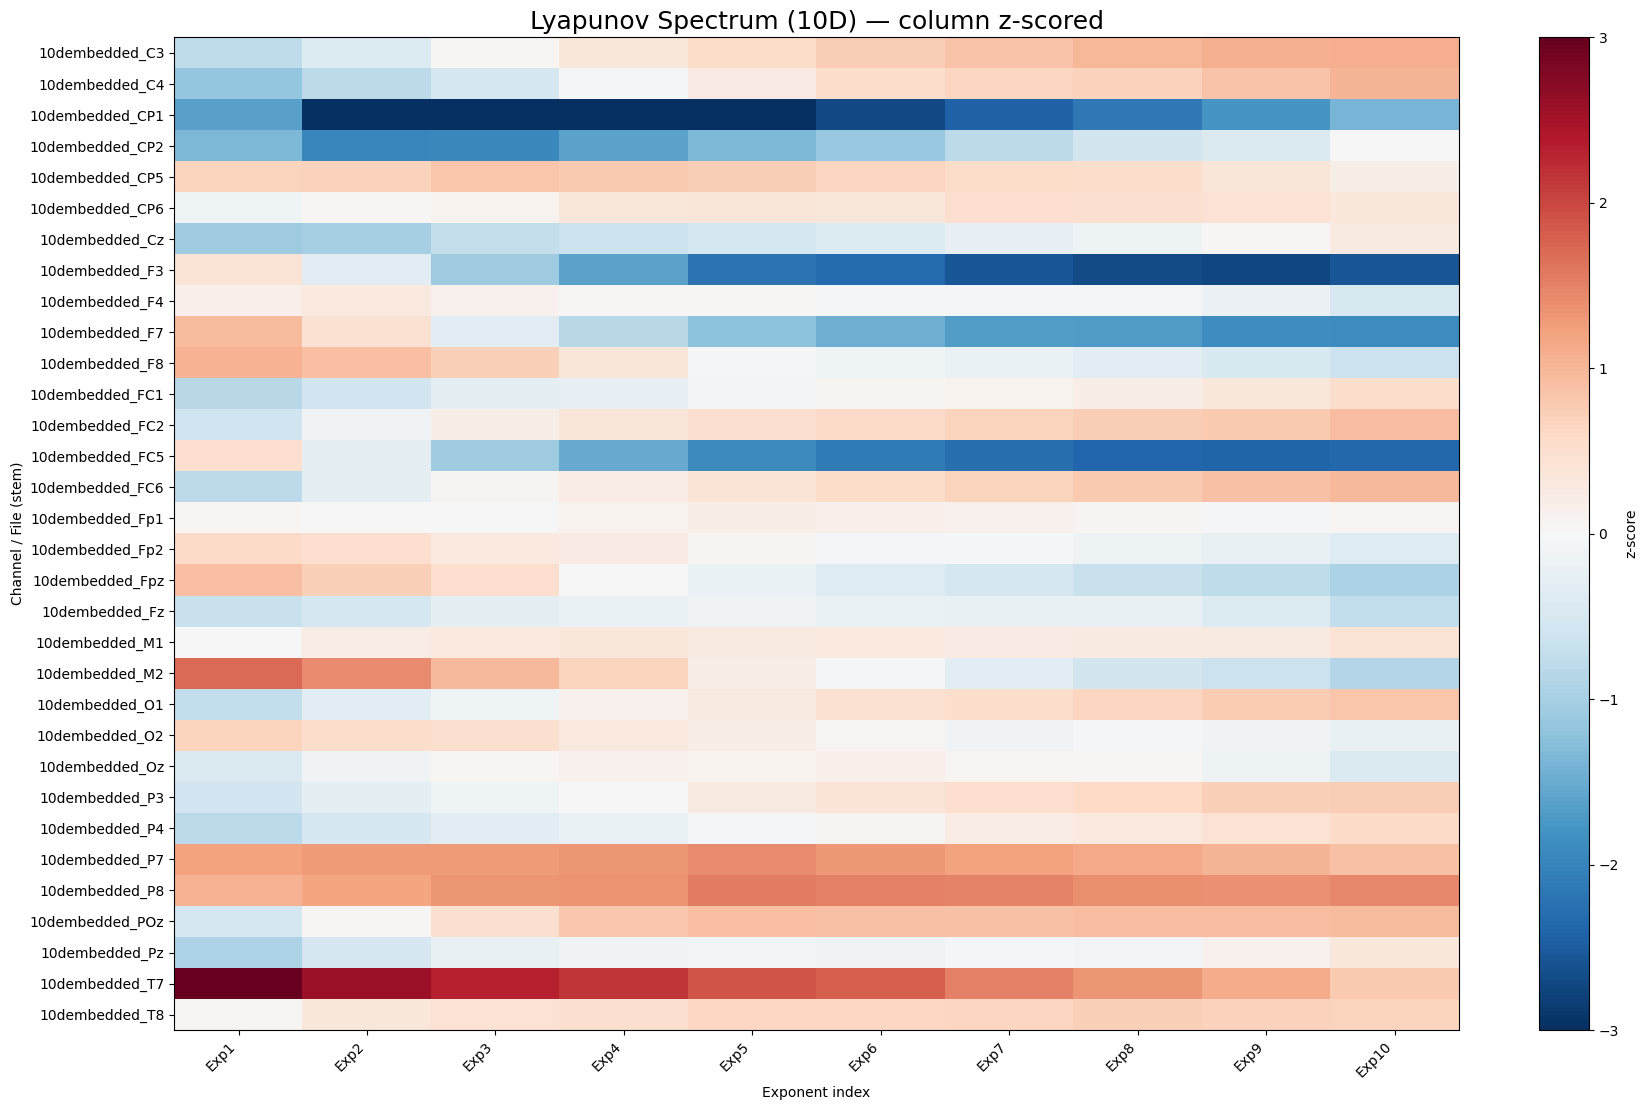

In [18]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_ok.set_index("stem")[exp_cols].sort_index()
Z = df_plot.to_numpy()

# column-wise normalization
mu = np.nanmean(Z, axis=0, keepdims=True)
sd = np.nanstd(Z, axis=0, keepdims=True) + 1e-12
Zz = (Z - mu) / sd

fig, ax = plt.subplots(figsize=(18, max(6, Z.shape[0]*0.35)))
im = ax.imshow(Zz, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-3, vmax=3)

ax.set_title("Lyapunov Spectrum (10D) — column z-scored", fontsize=18)
ax.set_ylabel("Channel / File (stem)")
ax.set_xlabel("Exponent index")
ax.set_xticks(np.arange(len(exp_cols)))
ax.set_xticklabels(exp_cols, rotation=45, ha="right")
ax.set_yticks(np.arange(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.show()

# Population-Average Lyapunov Spectrum with Across-Channel Variability (Mean ± Std Envelope)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block summarizes the Lyapunov spectra computed for multiple EEG channels (or files) by plotting the <b>population-average spectrum</b>
            alongside an uncertainty band representing <b>across-channel variability</b>. Rather than inspecting each channel’s spectrum individually,
            the figure provides a cohort-level “typical” dynamical profile and highlights how consistent (or heterogeneous) the spectrum is across channels.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            Let the Lyapunov spectrum for channel <code>i</code> be a vector <code>λ^{(i)} = (λ^{(i)}_1, …, λ^{(i)}_D)</code>.
            Since the canonical interpretation assumes ordered exponents (<code>λ_1 ≥ λ_2 ≥ … ≥ λ_D</code>), the code sorts each channel’s spectrum
            in descending order to obtain <code>Zs</code>. The across-channel mean and standard deviation are then computed for each index <code>k</code>:
        </p>
        \[
            \mu_k = \frac{1}{N}\sum_{i=1}^{N} \lambda^{(i)}_k,
            \qquad
            \sigma_k = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(\lambda^{(i)}_k - \mu_k\right)^2}
        \]
        <p>
            The plotted curve corresponds to <code>\mu_k</code> over exponent index <code>k</code>, and the shaded band corresponds to
            <code>\mu_k \pm \sigma_k</code>. A horizontal reference line at <code>0</code> marks the stability boundary separating
            expansion (<code>λ &gt; 0</code>) from contraction (<code>λ &lt; 0</code>).
        </p>
        <h2>Why Sorting Before Averaging is Essential</h2>
        <p>
            Averaging unsorted spectra is generally meaningless because exponent indices may be permuted or numerically unstable across channels.
            Sorting enforces a consistent semantic interpretation: index <code>1</code> corresponds to the largest exponent (LLE), index <code>2</code> to the
            second-largest, etc. This ensures that the mean curve truly reflects the “typical” ordered spectrum across channels.
        </p>
        <h2>Interpretation of the Mean Spectrum</h2>
        <p>
            The mean spectrum encodes the cohort’s average dynamical character:
            <ul>
                <li><b>Mean LLE &gt; 0</b>: on average, channels exhibit sensitivity to initial conditions (chaos-like instability).</li>
                <li><b>Mean spectrum strongly negative</b>: globally dissipative dynamics (overall contraction in state space).</li>
                <li><b>Near-zero exponents</b>: potentially neutral directions (common in flows or due to estimation/finite-data effects).</li>
            </ul>
            The shape (steepness of decay across indices) often reflects how rapidly the system contracts in subordinate directions.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Extract</b> the exponent matrix from <code>df_ok</code> (<code>n_channels × D</code>).</li>
                <li><b>Sort</b> each row descending to enforce canonical exponent ordering (<code>Zs</code>).</li>
                <li><b>Compute</b> the column-wise mean <code>m</code> and standard deviation <code>s</code> across channels.</li>
                <li><b>Plot</b> the mean spectrum and overlay a shaded <code>±1σ</code> envelope via <code>fill_between</code>.</li>
                <li><b>Reference</b> stability by drawing a horizontal line at <code>0</code>.</li>
            </ol>
            The x-axis is the exponent rank (sorted index), not a physical dimension, which makes the plot directly interpretable in dynamical-systems terms.
        </p>
        <h2>What the Variability Band Represents</h2>
        <p>
            The <code>±1σ</code> band reflects <b>heterogeneity across channels</b> at each exponent index:
            <ul>
                <li><b>Narrow band:</b> channels share a consistent spectral structure (similar dynamics or estimator behavior).</li>
                <li><b>Wide band:</b> substantial channel-to-channel differences (potential physiological variation, artifacts, or segment instability).</li>
            </ul>
            Note that <code>±1σ</code> is a descriptive spread, not a confidence interval; for inferential uncertainty you would use bootstrapping over time windows.
        </p>
        <h2>What This Plot Reveals (and What It Hides)</h2>
        <p>
            <b>Reveals:</b>
            <ul>
                <li>The cohort-level “typical” Lyapunov spectrum shape,</li>
                <li>Whether the largest exponent is robustly positive across channels,</li>
                <li>Which exponent ranks exhibit the greatest between-channel variability.</li>
            </ul>
            <b>Hides:</b>
            <ul>
                <li>Individual channel identities and outliers (those require per-channel plots or ranked tables),</li>
                <li>Temporal variability within channels (requires segmentation or bootstrap resampling over time),</li>
                <li>Correlations between exponents within a channel (requires multivariate analysis).</li>
            </ul>
        </p>
        <h2>Practical Next Steps</h2>
        <p>
            Common expert follow-ups include:
            (i) plotting the distribution of the LLE (<code>λ₁</code>) across channels,
            (ii) computing Kaplan–Yorke dimension from each channel spectrum and summarizing it similarly,
            and (iii) repeating the spectrum estimation over multiple time windows to test stability of the mean curve and its spread.
        </p>
    </div>
</div>

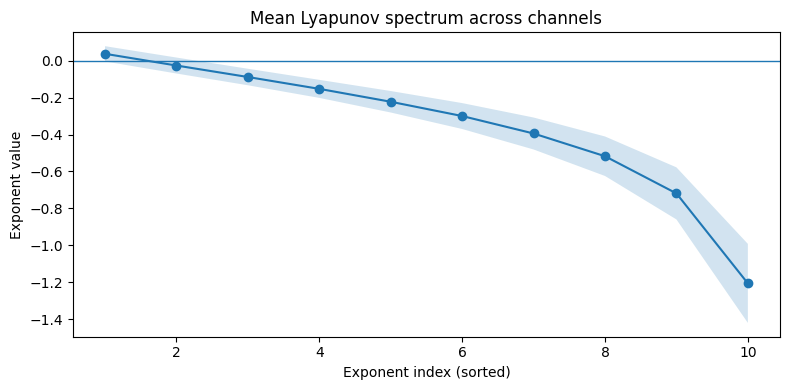

In [19]:
import matplotlib.pyplot as plt
import numpy as np

Zs = np.sort(df_ok[exp_cols].to_numpy(), axis=1)[:, ::-1]
m = Zs.mean(axis=0)
s = Zs.std(axis=0)

x = np.arange(1, len(exp_cols)+1)
plt.figure(figsize=(8,4))
plt.plot(x, m, marker="o")
plt.fill_between(x, m - s, m + s, alpha=0.2)
plt.axhline(0, linewidth=1)
plt.title("Mean Lyapunov spectrum across channels")
plt.xlabel("Exponent index (sorted)")
plt.ylabel("Exponent value")
plt.tight_layout()
plt.show()

In [4]:
# Function to determine stability based on Lyapunov exponents
def determine_stability(lyapunov_exps):
    # If any exponent is positive, it's chaotic; otherwise, it's stable
    return 'chaotic' if any(exp > 0 for exp in lyapunov_exps) else 'stable'

# Creating the stability map
stability_map = {channel: determine_stability(exps) for channel, exps in lyapunov_exponents.items()}

# Displaying the stability map (optional)
for channel, stability in stability_map.items():
    print(f"{channel}: {stability}")

3dembedded_CP2: chaotic
3dembedded_Fp1: chaotic
3dembedded_O2: chaotic
3dembedded_Fpz: chaotic
3dembedded_FC1: chaotic
3dembedded_T8: chaotic
3dembedded_FC6: chaotic
3dembedded_POz: chaotic
3dembedded_Fp2: chaotic
3dembedded_P3: chaotic
3dembedded_CP6: chaotic
3dembedded_FC2: chaotic
3dembedded_P8: chaotic
3dembedded_M1: chaotic
3dembedded_Fz: chaotic
3dembedded_M2: chaotic
3dembedded_C3: chaotic
3dembedded_T7: chaotic
3dembedded_F3: chaotic
3dembedded_P4: chaotic
3dembedded_C4: chaotic
3dembedded_Oz: chaotic
3dembedded_P7: chaotic
3dembedded_F7: chaotic
3dembedded_CP5: chaotic
3dembedded_F8: chaotic
3dembedded_Pz: chaotic
3dembedded_FC5: chaotic
3dembedded_Cz: chaotic
3dembedded_F4: chaotic
3dembedded_CP1: chaotic
3dembedded_O1: chaotic


### Heatmap of Lyapunov Exponents

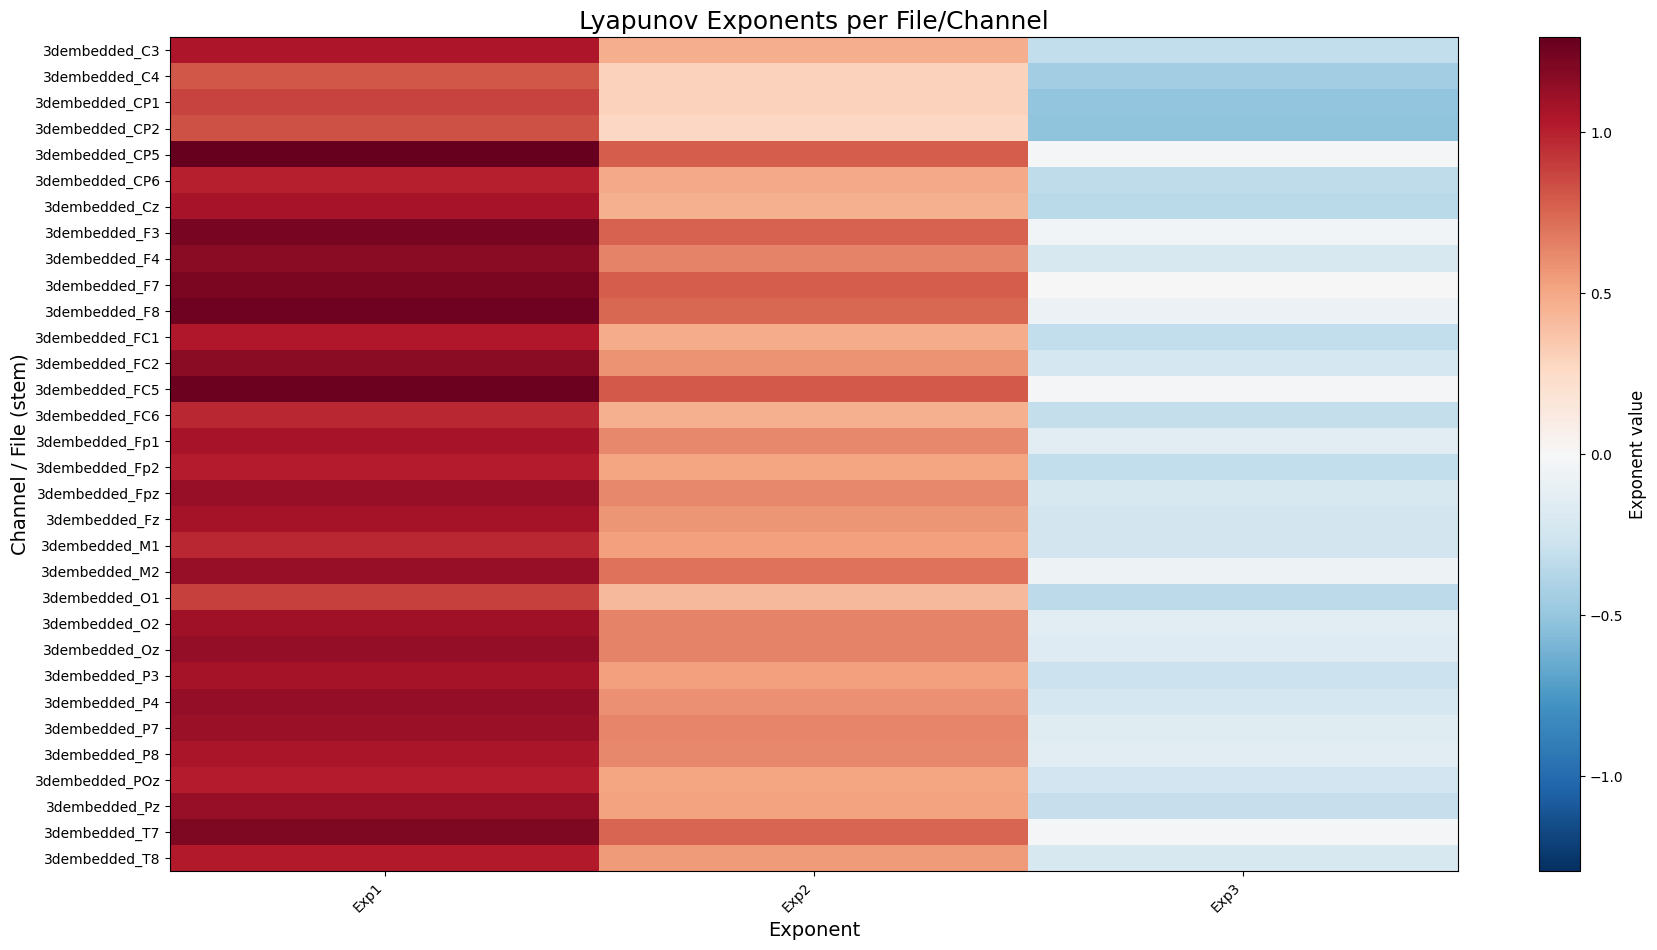

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260305_145136.csv"
df = pd.read_csv(CSV_PATH)

# keep only successful rows
df_ok = df[df["status"] == "ok"].copy()

# exponent columns (Exp1, Exp2, Exp3, ...)
exp_cols = sorted(
    [c for c in df_ok.columns if c.startswith("Exp")],
    key=lambda s: int(s.replace("Exp", ""))
)

# matrix for plotting
df_plot = df_ok.set_index("stem")[exp_cols].sort_index()
Z = df_plot.to_numpy()

fig_h = max(6, Z.shape[0] * 0.3)
fig, ax = plt.subplots(figsize=(18, fig_h))

# diverging colormap centered at 0
v = np.nanmax(np.abs(Z)) if np.isfinite(Z).any() else 1.0
im = ax.imshow(Z, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-v, vmax=v)

ax.set_title("Lyapunov Exponents per File/Channel", fontsize=18)
ax.set_ylabel("Channel / File (stem)", fontsize=14)
ax.set_xlabel("Exponent", fontsize=14)

# ticks
ax.set_xticks(np.arange(len(exp_cols)))
ax.set_xticklabels(exp_cols, rotation=45, ha="right")

# y tick labels (downsample if too many)
y_labels = df_plot.index.to_list()
step = 1
if len(y_labels) > 200:
    step = 5
if len(y_labels) > 500:
    step = 10

ax.set_yticks(np.arange(0, len(y_labels), step))
ax.set_yticklabels([y_labels[i] for i in range(0, len(y_labels), step)])

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Exponent value", fontsize=12)

plt.tight_layout()
plt.show()

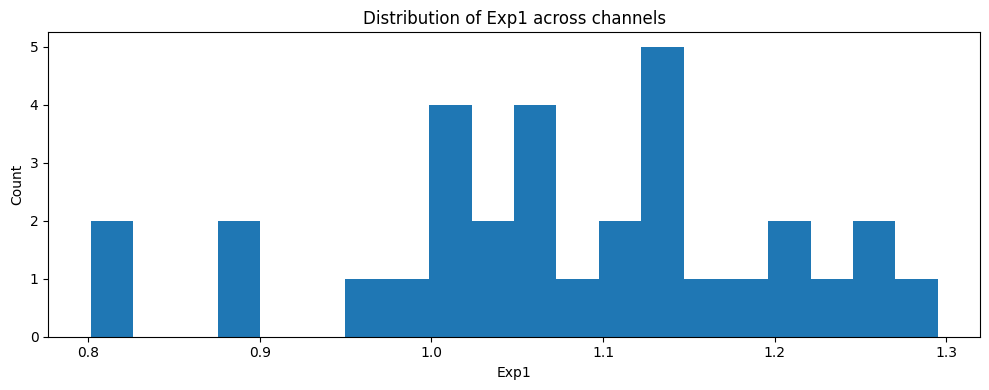

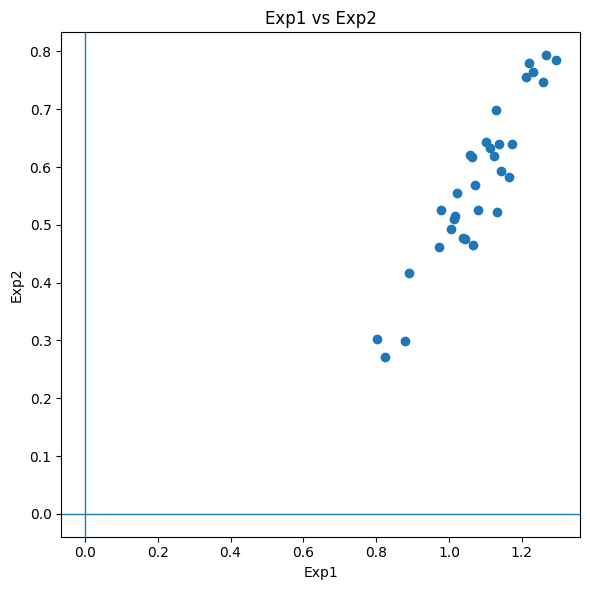

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df_ok["Exp1"].to_numpy(), bins=20)
plt.title("Distribution of Exp1 across channels")
plt.xlabel("Exp1")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_ok["Exp1"], df_ok["Exp2"])
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Exp1 vs Exp2")
plt.xlabel("Exp1")
plt.ylabel("Exp2")
plt.tight_layout()
plt.show()

# Full 10D Lyapunov Spectrum Estimation from Embedded Trajectories via Local Jacobian Regression and Benettin QR (Batch Pipeline)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block implements a <b>self-contained, library-light</b> workflow to estimate the <b>full Lyapunov spectrum</b> (here, 10 exponents) from
            precomputed embedding trajectories stored as <code>.npy</code> arrays. It combines (i) fast nearest-neighbor search (optional SciPy <code>cKDTree</code>),
            (ii) local linear regression to estimate the flow’s Jacobian from trajectory data, and (iii) the <b>Benettin QR method</b> to accumulate exponential
            growth rates in tangent space. The script runs this estimator in batch over all embedding files, performs basic quality control, and writes a
            reproducible CSV artifact containing exponents and derived dynamical summaries.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For a discrete-time trajectory <code>x_t ∈ ℝ^D</code> (or a sampled flow treated discretely), local dynamics can be approximated by a Jacobian
            mapping near <code>x_t</code>:
        </p>
        \[
            \delta x_{t+1} \approx J_t \, \delta x_t
        \]
        <p>
            where <code>J_t</code> is the Jacobian of the (unknown) evolution operator at time <code>t</code>. The Lyapunov exponents are the long-time average
            logarithmic growth rates of perturbation vectors under repeated application of these Jacobians. The Benettin approach evolves an orthonormal basis
            <code>Q_t</code> in tangent space and periodically re-orthonormalizes via QR decomposition:
        </p>
        \[
            Z_t = J_t Q_t,\quad Z_t = Q_{t+1}R_t,\quad \lambda_i \approx \frac{1}{T}\sum_{t=1}^{T}\ln |(R_t)_{ii}|
        \]
        <p>
            Here, the diagonal entries of <code>R_t</code> capture expansion/contraction along orthonormal tangent directions at step <code>t</code>. Summing
            <code>\ln |(R_t)_{ii}|\</code> over steps and dividing by total elapsed time yields the spectrum <code>{λ₁,…,λ_D}</code>.
        </p>
        <h2>Local Jacobian Estimation from Data</h2>
        <p>
            Because the true Jacobian is not known, the code estimates <code>J_t</code> from nearest neighbors around <code>x_t</code>. For a set of neighbors
            <code>x_{t,j}</code>, it uses the linearization:
        </p>
        \[
            (x_{t+1,j}-x_{t+1}) \approx J_t (x_{t,j}-x_t)
        \]
        <p>
            forming matrices <code>A = [x_{t,j}-x_t]</code> and <code>B = [x_{t+1,j}-x_{t+1}]</code>, then solving <code>A J_t^T ≈ B</code> by least squares
            (<code>np.linalg.lstsq</code>). This yields a data-driven local Jacobian used in the Benettin accumulation.
        </p>
        <h2>Theiler Window and Temporal Bias Control</h2>
        <p>
            To avoid selecting trivially “near” points that are close only because they are adjacent in time, the neighbor search applies a <b>Theiler window</b>
            exclusion: neighbors within <code>|j - i| ≤ theiler</code> are discarded. This reduces temporal correlation bias and improves the fidelity of local
            geometry in reconstructed state space.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The workflow is organized into four stages:
            <ol>
                <li><b>Neighbor Search</b>: <code>_neighbors_indices</code> returns kNN indices for each time point, optionally using <code>cKDTree</code> for speed, with a Theiler exclusion.</li>
                <li><b>Spectrum Estimation</b>: <code>lyapunov_spectrum_from_trajectory</code> estimates local Jacobians, advances an orthonormal basis, performs QR, and accumulates <code>log|diag(R)|</code>.</li>
                <li><b>Derived Metrics</b>: <code>kaplan_yorke_dimension</code> computes <code>D<sub>KY</sub></code>, and the script also records <code>sum_pos</code> as the sum of positive exponents.</li>
                <li><b>Batch Processing & QC</b>: iterates over files, checks shape and dimensionality, computes results, logs failures, and saves a single CSV artifact.</li>
            </ol>
        </p>
        <h2>Key Parameters and Their Effects</h2>
        <p>
            The most consequential hyperparameters are:
            <ul>
                <li><b><code>TARGET_D</code></b>: target state dimension (here 10). The estimator produces exactly <code>D</code> exponents for a <code>(N,D)</code> trajectory.</li>
                <li><b><code>K_NEIGHBORS</code></b>: neighbors used for Jacobian regression. Too small increases variance/ill-conditioning; too large can violate locality assumptions.</li>
                <li><b><code>THEILER</code></b>: temporal exclusion radius. Larger reduces bias but may reduce usable neighbors in short records.</li>
                <li><b><code>STRIDE</code></b>: evaluates Jacobians every <code>stride</code> points; a major speed/variance trade-off knob.</li>
                <li><b><code>DT</code></b>: sampling interval used to scale exponents. <code>DT=1</code> yields per-sample units; <code>DT=1/fs</code> yields per-second units.</li>
            </ul>
            In high-sample settings (as typical in EEG), using a moderate <code>STRIDE</code> (e.g., 5–20) can reduce compute while still providing stable averages.
        </p>
        <h2>Output Schema and Reproducibility</h2>
        <p>
            Each file contributes one row to the output table with:
            <ul>
                <li><code>path</code>, <code>file</code>, <code>stem</code>: traceability back to the raw embedding array,</li>
                <li><code>status</code> and <code>error</code>: explicit logging for skipped files (wrong shape/dimension) and runtime failures,</li>
                <li><code>n_samples</code>, <code>state_dim</code>, <code>steps_used</code>: diagnostics on data size and effective estimator iterations,</li>
                <li><code>Exp1…Exp10</code>: the full Lyapunov spectrum estimate,</li>
                <li><code>sum_pos</code>: total expansion rate across unstable directions,</li>
                <li><code>ky_dim</code>: Kaplan–Yorke dimension estimate derived from the spectrum.</li>
            </ul>
            The timestamped filename (<code>lyap_spectrum_10D_YYYYMMDD_HHMMSS.csv</code>) ensures provenance and allows side-by-side comparison of runs with different parameter settings.
        </p>
        <h2>Practical Interpretation Notes</h2>
        <p>
            The resulting spectrum is a powerful diagnostic but should be interpreted cautiously in noisy biological systems:
            <ul>
                <li><b>Small positive <code>Exp1</code></b> can be sensitive to estimator bias, windowing, and measurement noise; validate stability across time segments.</li>
                <li><b>Strongly negative tails</b> typically indicate dissipative reconstruction or contraction in subordinate directions; compare across channels rather than relying on absolute values alone.</li>
                <li><b><code>D<sub>KY</sub></code></b> is a comparative fractal-dimension proxy and can be unstable if exponents near the threshold are close to zero.</li>
            </ul>
            For publication-grade inference, segment/bootstrap resampling and parameter sensitivity sweeps (neighbors, theiler, stride) are standard best practice.
        </p>
    </div>
</div>

In [13]:
import os, glob
import numpy as np
import pandas as pd
from datetime import datetime

# --- Fast NN if available (optional) ---
try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False


def _neighbors_indices(X: np.ndarray, i: int, k: int, theiler: int, tree=None, extra: int = 200):
    """k-NN with Theiler window exclusion."""
    n = X.shape[0]
    if tree is not None:
        qk = min(n, k + extra)
        dists, idx = tree.query(X[i], k=qk)
        idx = np.atleast_1d(idx)
        mask = (np.abs(idx - i) > theiler) & (idx >= 0) & (idx < n)
        idx = idx[mask]
        return idx[:k]
    else:
        diffs = X - X[i]
        d2 = np.einsum("ij,ij->i", diffs, diffs)
        lo = max(0, i - theiler)
        hi = min(n, i + theiler + 1)
        d2[lo:hi] = np.inf
        idx = np.argsort(d2)[:k]
        idx = idx[np.isfinite(d2[idx])]
        return idx


def lyapunov_spectrum_from_trajectory(
    X: np.ndarray,
    k_neighbors: int = 50,
    theiler: int = 10,
    stride: int = 10,
    dt: float = 1.0,
    rcond: float | None = None,
):
    """
    Full Lyapunov spectrum for trajectory X (N,D) via local Jacobian estimation + Benettin QR.
    Returns (exponents[D], steps_used).
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be (N, D).")
    n, d = X.shape
    if n < 5:
        raise ValueError("Trajectory too short.")

    # Need i+1 and j+1 valid
    X0 = X[:-1]
    X1 = X[1:]
    n0 = X0.shape[0]

    tree = KDTree(X0) if _HAVE_KDTREE else None

    Q = np.eye(d)
    sums = np.zeros(d, dtype=float)
    used = 0

    for i in range(0, n0 - 1, stride):
        nbrs = _neighbors_indices(X0, i, k_neighbors * 2, theiler, tree=tree)
        nbrs = nbrs[nbrs < (n0 - 1)]
        if nbrs.size < max(d + 1, k_neighbors):
            continue
        nbrs = nbrs[:k_neighbors]

        A = (X0[nbrs] - X0[i])  # (k,d)
        B = (X1[nbrs] - X1[i])  # (k,d)

        try:
            JT, *_ = np.linalg.lstsq(A, B, rcond=rcond)  # (d,d)
            J = JT.T
        except np.linalg.LinAlgError:
            continue

        Z = J @ Q
        Q, R = np.linalg.qr(Z)
        diag = np.abs(np.diag(R))
        diag[diag == 0] = np.finfo(float).tiny
        sums += np.log(diag)
        used += 1

    if used == 0:
        raise ValueError("No usable steps (try smaller theiler/k_neighbors or smaller stride).")

    exps = sums / (used * dt)
    return exps, used


def kaplan_yorke_dimension(exps: np.ndarray) -> float:
    """Kaplan–Yorke (Lyapunov) dimension from spectrum sorted desc."""
    lam = np.sort(np.asarray(exps, dtype=float))[::-1]
    cumsum = np.cumsum(lam)
    j = np.where(cumsum >= 0)[0]
    if len(j) == 0:
        return 0.0
    j = j[-1]
    if j == len(lam) - 1:
        return float(len(lam))
    denom = lam[j + 1]
    if denom == 0:
        return float(j + 1)
    return float((j + 1) + cumsum[j] / abs(denom))


# ---------------------------
# Your paths
# ---------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
emb_dir  = os.path.join(base_dir, "embedding_data", "embeddings_4to10")
results_dir = os.path.join(base_dir, "lyapunov_results_10D")
os.makedirs(results_dir, exist_ok=True)

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_CSV = os.path.join(results_dir, f"lyap_spectrum_10D_{run_tag}.csv")

# Parameters (start here; adjust if you want)
TARGET_D = 10
K_NEIGHBORS = 50
THEILER = 10
STRIDE = 10       # <- big speed knob (10 = use every 10th point)
DT = 1.0          # <- per-sample units; set DT=1/fs for per-second

# find npy files (recursive)
file_paths = sorted(glob.glob(os.path.join(emb_dir, "**", "*.npy"), recursive=True))

records = []
for fp in file_paths:
    rec = {
        "file": os.path.basename(fp),
        "stem": os.path.splitext(os.path.basename(fp))[0],
        "path": fp,
        "status": "ok",
        "error": "",
        "n_samples": None,
        "state_dim": None,
        "steps_used": None,
    }

    # initialize exponent columns so the CSV always has Exp1..Exp10
    for i in range(1, TARGET_D + 1):
        rec[f"Exp{i}"] = np.nan

    try:
        X = np.load(fp)

        if X.ndim != 2:
            rec["status"] = "skip_dim"
            rec["error"] = f"expected 2D array (N,D), got shape {X.shape}"
            records.append(rec)
            continue

        n, d = X.shape
        rec["n_samples"] = int(n)
        rec["state_dim"] = int(d)

        if d < TARGET_D:
            rec["status"] = "skip_dim"
            rec["error"] = f"state_dim={d} < {TARGET_D}"
            records.append(rec)
            continue

        X10 = np.asarray(X[:, :TARGET_D], dtype=float)

        exps, used = lyapunov_spectrum_from_trajectory(
            X10,
            k_neighbors=K_NEIGHBORS,
            theiler=THEILER,
            stride=STRIDE,
            dt=DT,
        )
        rec["steps_used"] = int(used)

        # store
        for i, val in enumerate(exps, start=1):
            rec[f"Exp{i}"] = float(val)

        # derived quick stats
        rec["sum_pos"] = float(np.sum(exps[exps > 0]))
        rec["ky_dim"] = float(kaplan_yorke_dimension(exps))

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"

    records.append(rec)

df = pd.DataFrame(records)
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print(df["status"].value_counts())
print(df.head())

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D/lyap_spectrum_10D_20260305_151303.csv
status
skip_dim    192
ok           32
error         1
Name: count, dtype: int64
                  file             stem  \
0   10dembedded_C3.npy   10dembedded_C3   
1   10dembedded_C4.npy   10dembedded_C4   
2  10dembedded_CP1.npy  10dembedded_CP1   
3  10dembedded_CP2.npy  10dembedded_CP2   
4  10dembedded_CP5.npy  10dembedded_CP5   

                                                path status error  n_samples  \
0  /home/a/projects/Complete-Neural-Signal-Analys...     ok         106818.0   
1  /home/a/projects/Complete-Neural-Signal-Analys...     ok         106773.0   
2  /home/a/projects/Complete-Neural-Signal-Analys...     ok         106818.0   
3  /home/a/projects/Complete-Neural-Signal-Analys...     ok         106773.0   
4  /home/a/projects/Complete-Neural-Signal-Analys...     ok         106800.0   

   state_dim  steps_used      Exp1      Exp2      Exp3      Exp4

# Auto-Selecting the Latest 10D Lyapunov-Spectrum Results and Rendering a Full-Spectrum Heatmap (Matplotlib-Only)

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible “last-run” visualization workflow for Lyapunov-spectrum experiments. It automatically discovers the most recently
            generated CSV in <code>lyapunov_results_10D</code>, loads the results table, filters to successful computations, and renders a heatmap of the full
            Lyapunov spectrum (<code>Exp1…Exp10</code>) for each channel/file. The key intent is to eliminate manual timestamp bookkeeping while ensuring the plotted
            heatmap always corresponds to the newest available spectrum results.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            For each channel/file <code>i</code>, the Lyapunov spectrum is the ordered set of exponents <code>{λ₁,…,λ_D}</code> (here nominally <code>D=10</code>),
            where each exponent measures the asymptotic exponential rate of separation (or contraction) of nearby trajectories along a tangent-space direction:
        </p>
        \[
            \lambda_k =
            \lim_{t \to \infty}
            \frac{1}{t}\ln\left(\frac{\|\delta \mathbf{x}_k(t)\|}{\|\delta \mathbf{x}_k(0)\|}\right),
            \quad k=1,\dots,D
        \]
        <p>
            A heatmap of the spectrum is a compact diagnostic: rows correspond to channels/files, columns to exponent indices, and color encodes the exponent value.
            This enables rapid comparison of dynamical stability/instability across channels, including whether <code>λ₁</code> (the LLE) is positive and how strongly
            dissipative the remaining directions are.
        </p>
        <h2>Data Model and Robust Column Selection</h2>
        <p>
            The script expects a CSV schema produced by upstream computation, typically including:
            <ul>
                <li><code>stem</code>: channel/file identifier used for row labels,</li>
                <li><code>status</code>: quality-control label (only <code>ok</code> rows are plotted),</li>
                <li><code>Exp1…Exp10</code>: Lyapunov exponents, one column per exponent index.</li>
            </ul>
            To remain robust to partial outputs or different dimensional runs, the block constructs the intended exponent list and then filters to columns that
            actually exist (<code>exp_cols = [c for c in exp_cols if c in df_ok.columns]</code>). This prevents runtime errors and makes the plot adapt automatically
            if a run produced fewer than 10 exponents.
        </p>
        <h2>Why “Latest File” Selection Matters</h2>
        <p>
            Spectrum estimation is often iterated with different hyperparameters (neighbors, stride, Theiler window, embedding choice). Using filesystem
            modification time (<code>os.path.getmtime</code>) ensures the visualization always targets the most recent run artifact, reducing the risk of accidentally
            plotting stale results and improving experimental traceability.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Discover</b> all matching result files (<code>glob("lyap_spectrum_10D_*.csv")</code>).</li>
                <li><b>Select</b> the most recently modified file via <code>max(..., key=os.path.getmtime)</code>.</li>
                <li><b>Load</b> the table with <code>pd.read_csv</code> and filter to successful rows (<code>status == "ok"</code>).</li>
                <li><b>Assemble</b> a dense matrix <code>Z</code> with shape <code>(n_channels, D)</code> from <code>Exp*</code> columns.</li>
                <li><b>Render</b> a heatmap using <code>matplotlib.imshow</code> with a diverging colormap centered at zero.</li>
            </ol>
            The plot title is parameterized by the number of exponent columns actually present, which provides an immediate sanity check on dimensionality.
        </p>
        <h2>Color Scaling and Interpretability</h2>
        <p>
            The color range is set symmetrically to <code>[-v, +v]</code> where <code>v = max(|Z|)</code>. Symmetric scaling ensures that zero is visually central:
            positive exponents (expansion/instability) and negative exponents (contraction/stability) are comparable across channels. This is a principled default
            for Lyapunov spectra; however, if tail exponents are large in magnitude, they can dominate the scale and compress the visual contrast of near-zero exponents
            (in which case a z-scored heatmap is a complementary diagnostic).
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>Rows (y-axis):</b> channels/files indexed by <code>stem</code>, sorted alphabetically for reproducibility.</li>
                <li><b>Columns (x-axis):</b> exponent indices (<code>Exp1…ExpD</code>), representing the available Lyapunov spectrum.</li>
                <li><b>Cell color:</b> exponent magnitude and sign for that channel and exponent index.</li>
            </ul>
            The heatmap is therefore a direct visualization of the spectrum matrix <code>Z</code>.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Quickly spotting channels with unusually positive <code>Exp1</code> (potentially stronger chaos/instability),</li>
                <li>Comparing spectral “shape” across channels (e.g., whether contraction strengthens rapidly in higher indices),</li>
                <li>Identifying outliers that may indicate artifacts, embedding issues, or genuinely distinct dynamics.</li>
            </ul>
            For rigorous conclusions, exponents should be validated for stability across time windows and parameter sensitivity (neighbors, Theiler window, stride).
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            Because the selected file is printed (<code>print("Latest:", latest)</code>), the exact artifact used for plotting is recorded in logs/notebooks.
            This makes it easy to trace plots back to a specific run and ensures downstream figures remain auditable.
        </p>
    </div>
</div>

Latest: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D/lyap_spectrum_10D_20260305_151303.csv


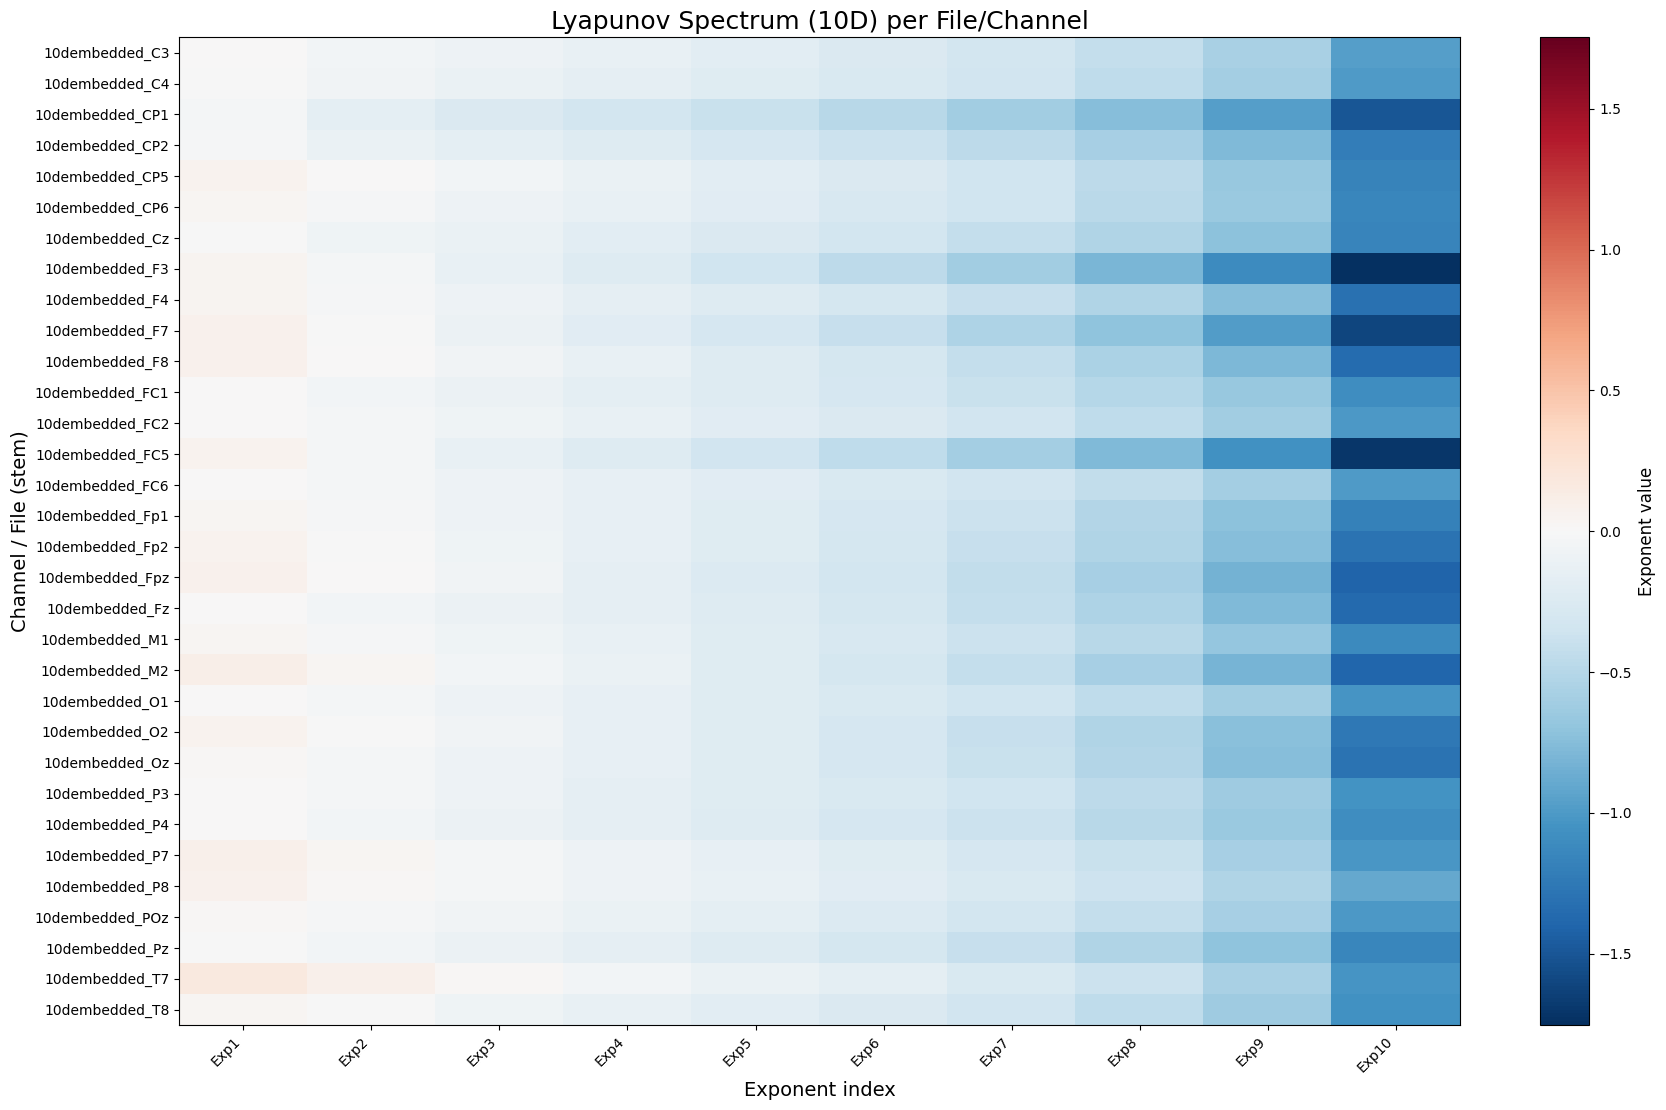

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

results_dir = "/home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D"
latest = max(glob.glob(os.path.join(results_dir, "lyap_spectrum_10D_*.csv")), key=os.path.getmtime)
print("Latest:", latest)

CSV_PATH = latest  # <-- use the real file you just found
df = pd.read_csv(CSV_PATH)

df_ok = df[df["status"] == "ok"].copy()

exp_cols = [f"Exp{i}" for i in range(1, 11)]
# (optional) keep only exponent columns that actually exist in the file
exp_cols = [c for c in exp_cols if c in df_ok.columns]

df_plot = df_ok.set_index("stem")[exp_cols].sort_index()
Z = df_plot.to_numpy()

fig_h = max(6, Z.shape[0] * 0.35)
fig, ax = plt.subplots(figsize=(18, fig_h))

v = np.nanmax(np.abs(Z)) if np.isfinite(Z).any() else 1.0
im = ax.imshow(Z, aspect="auto", interpolation="nearest",
               cmap="RdBu_r", vmin=-v, vmax=v)

ax.set_title(f"Lyapunov Spectrum ({len(exp_cols)}D) per File/Channel", fontsize=18)
ax.set_ylabel("Channel / File (stem)", fontsize=14)
ax.set_xlabel("Exponent index", fontsize=14)

ax.set_xticks(np.arange(len(exp_cols)))
ax.set_xticklabels(exp_cols, rotation=45, ha="right")

y_labels = df_plot.index.to_list()
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Exponent value", fontsize=12)

plt.tight_layout()
plt.show()

### False Nearest Neighbors and correlation dimension


COMMON locked-u window (works for ALL m): u in [0.01, 0.69] | Theiler=20


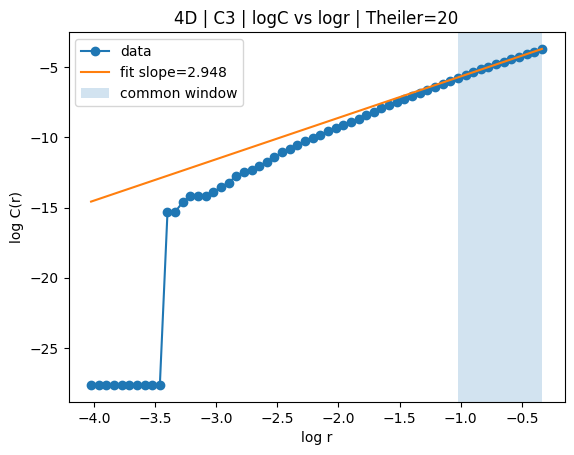

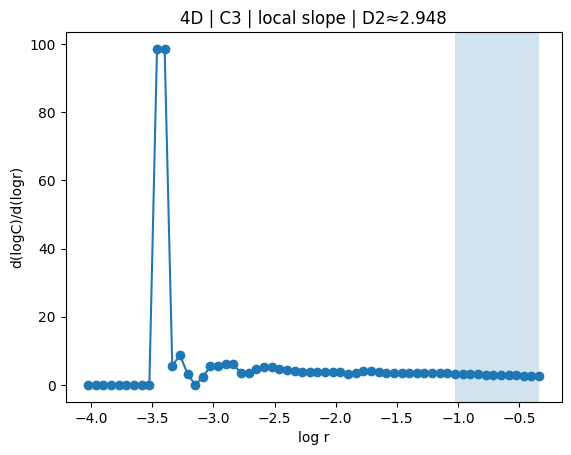

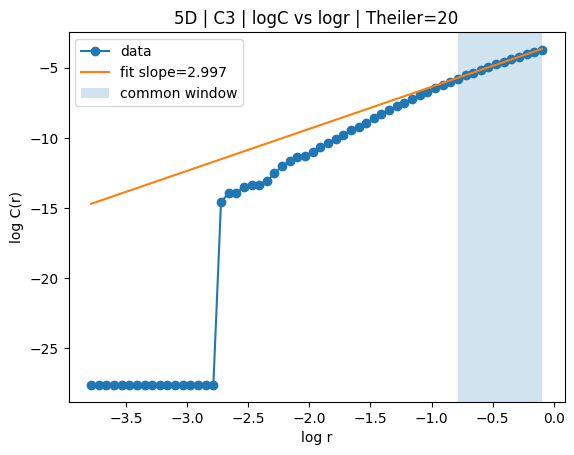

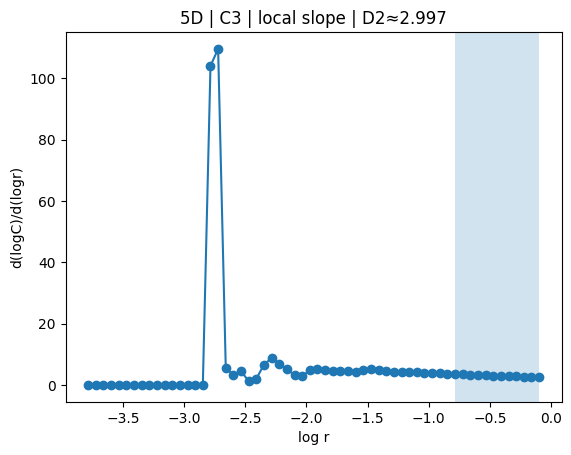

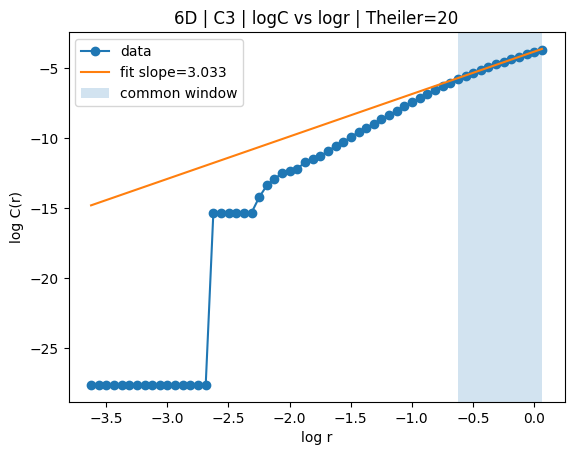

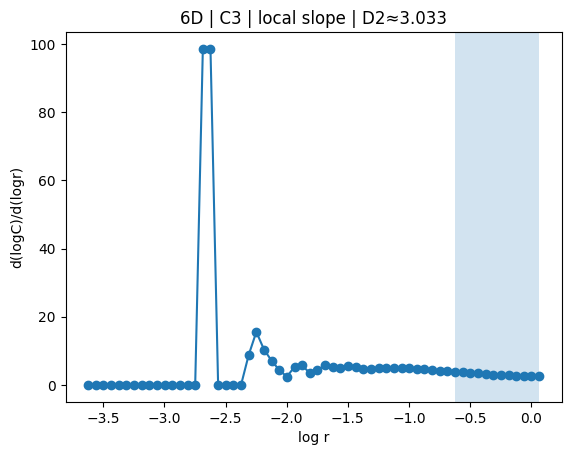

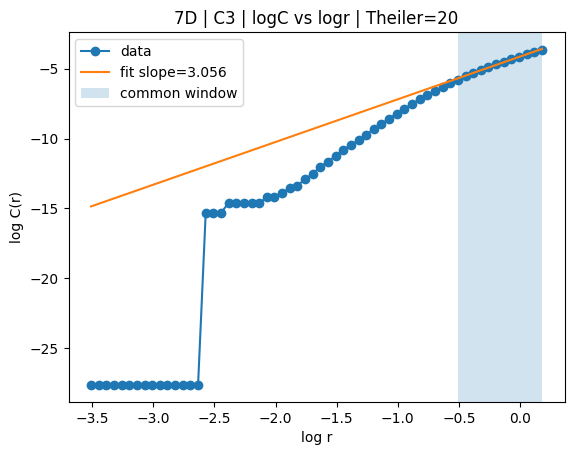

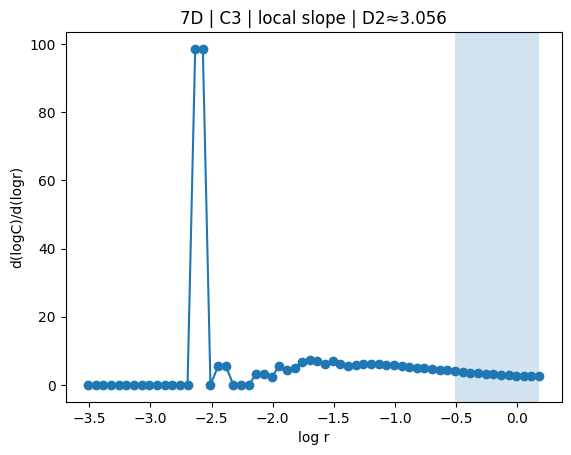

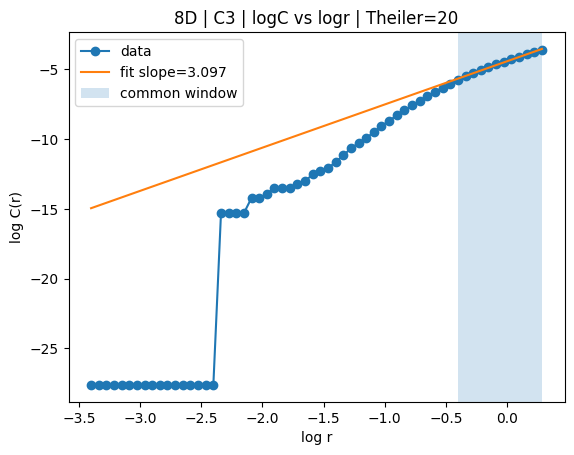

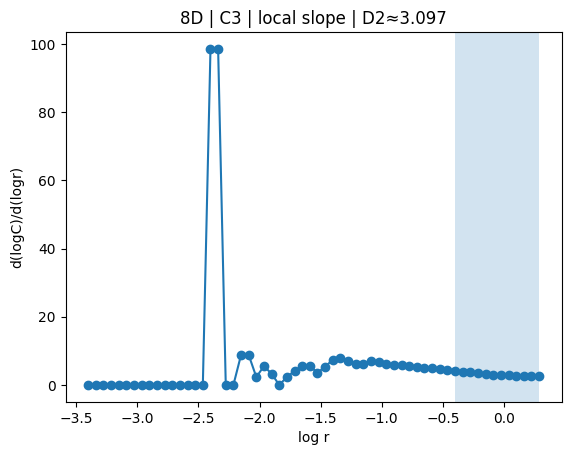

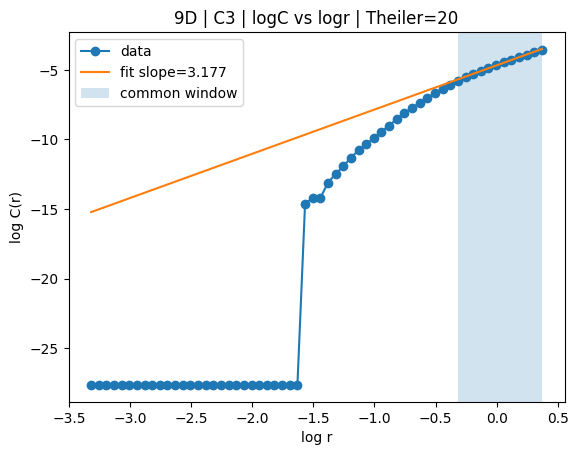

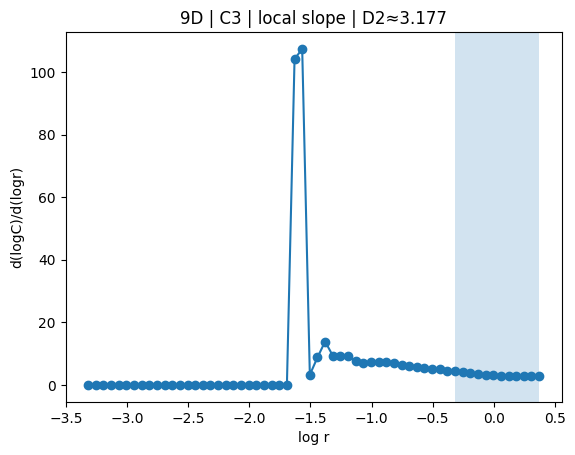

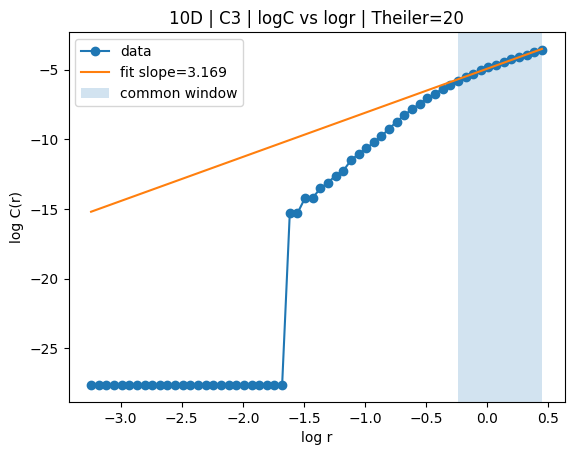

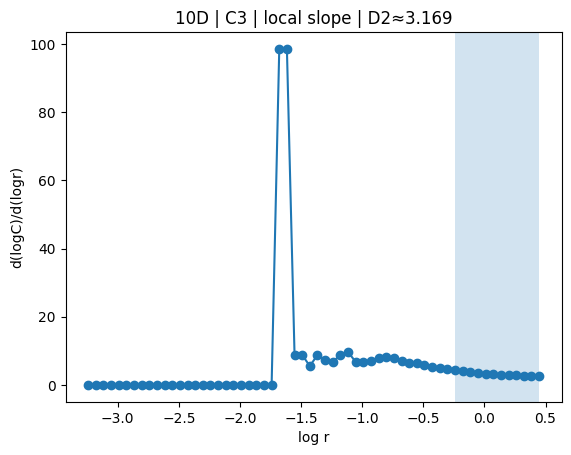


=== D2 vs embedding dimension m (COMMON window) ===
m= 4 -> D2≈ 2.948 | medC=9.19e-03 | floor%=0.0 | u≈[0.01,0.69]
m= 5 -> D2≈ 2.997 | medC=9.56e-03 | floor%=0.0 | u≈[0.01,0.69]
m= 6 -> D2≈ 3.033 | medC=1.01e-02 | floor%=0.0 | u≈[0.01,0.69]
m= 7 -> D2≈ 3.056 | medC=1.02e-02 | floor%=0.0 | u≈[0.01,0.69]
m= 8 -> D2≈ 3.097 | medC=1.07e-02 | floor%=0.0 | u≈[0.01,0.69]
m= 9 -> D2≈ 3.177 | medC=1.07e-02 | floor%=0.0 | u≈[0.01,0.69]
m=10 -> D2≈ 3.169 | medC=1.07e-02 | floor%=0.0 | u≈[0.01,0.69]

D2 range: 2.947606326151731 to 3.176937524980283
ΔD2: 0.22933119882855202


In [2]:
import os, zipfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ============================================================
# CONFIG
# ============================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
zip_path = os.path.join(base_dir, "embedded_data_4to10.zip")
emb_dir  = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

channel = "C3"
ms = list(range(4, 11))          # 4..10

METHOD = "distmat"               # keep as you ran
THEILER = 20
n_points = 3000                  # try 4000 if you can
n_r = 60
k_scale = 10

# constraints
C_FLOOR = 1e-12
C_MIN   = 3e-4
C_MAX   = 1e-1
MAX_FLOOR_FRAC = 0.05
MIN_WIN_LEN = 12

PLOT = True

# ============================================================
# UNZIP IF NEEDED
# ============================================================
if (not os.path.isdir(emb_dir)) or (len(os.listdir(emb_dir)) == 0):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Couldn't find {emb_dir} or {zip_path}")
    os.makedirs(emb_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(emb_dir)
    print("Unzipped into:", emb_dir)

# ============================================================
# UTILITIES
# ============================================================
def standardize_cols(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def choose_r_range_from_knn(X, k=10):
    k = min(k, len(X))
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nn.kneighbors(X)
    dscale = float(np.median(dists[:, -1]))
    r_min = dscale * 0.05
    r_max = dscale * 2.0
    return r_min, r_max, dscale

def corr_sum_distmat_with_theiler(X, rs, theiler=0):
    X = np.asarray(X, dtype=float)
    N = len(X)

    G = X @ X.T
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2.0 * G, 0.0)
    D = np.sqrt(D2, dtype=float)

    iu, ju = np.triu_indices(N, k=1)
    if theiler > 0:
        ok = (np.abs(iu - ju) > theiler)
        iu, ju = iu[ok], ju[ok]

    dvec = D[iu, ju]
    dvec.sort()
    eligible_pairs = len(dvec)
    if eligible_pairs < 10:
        raise ValueError("Too few eligible pairs after Theiler.")

    Cs = []
    for r in rs:
        count = np.searchsorted(dvec, r, side="left")
        c = count / eligible_pairs
        Cs.append(max(float(c), C_FLOOR))
    return np.array(Cs, dtype=float)

def window_ok(Cs, idx_lo, idx_hi):
    seg = Cs[idx_lo:idx_hi+1]
    floor_frac = float(np.mean(seg <= C_FLOOR * 1.000001))
    medC = float(np.median(seg))
    return (floor_frac <= MAX_FLOOR_FRAC) and (C_MIN <= medC <= C_MAX), medC, floor_frac

# ============================================================
# 1) PRECOMPUTE curves for each m
# ============================================================
curves = {}  # m -> dict(u, logr, logC, Cs, local_slope, dscale)

for m in ms:
    fname = f"{m}dembedded_{channel}.npy"
    fpath = os.path.join(emb_dir, fname)
    if not os.path.exists(fpath):
        print("Missing:", fname, "(skip)")
        continue

    Xfull = standardize_cols(np.load(fpath))
    if Xfull.shape[1] != m:
        raise ValueError(f"{fname} shape {Xfull.shape} expected (*,{m})")

    N = len(Xfull)
    rng = np.random.default_rng(0)
    if N > n_points:
        idx = np.sort(rng.choice(N, size=n_points, replace=False))
        X = Xfull[idx]
    else:
        X = Xfull

    r_min, r_max, dscale = choose_r_range_from_knn(X, k=k_scale)
    rs = np.logspace(np.log10(r_min), np.log10(r_max), n_r)

    Cs = corr_sum_distmat_with_theiler(X, rs, theiler=THEILER)
    logr = np.log(rs)
    u = np.log(rs / dscale)
    logC = np.log(Cs)
    local_slope = np.gradient(logC, logr)

    curves[m] = dict(u=u, logr=logr, logC=logC, Cs=Cs, slope=local_slope, dscale=dscale)

if len(curves) < len(ms):
    print("Warning: not all m present. Proceeding with available:", sorted(curves.keys()))

ms_avail = sorted(curves.keys())

# ============================================================
# 2) AUTO-SELECT ONE COMMON u-WINDOW valid for ALL m
# ============================================================
# We scan windows in index space (same n_r across all m).
# Score = sum of slope stds across m (flatter across m is better).
best = None

for start in range(0, n_r - MIN_WIN_LEN + 1):
    end = start + MIN_WIN_LEN - 1

    # check constraints for all m
    ok_all = True
    score = 0.0
    for m in ms_avail:
        Cs = curves[m]["Cs"]
        ok, medC, floor_frac = window_ok(Cs, start, end)
        if not ok:
            ok_all = False
            break
        score += float(np.nanstd(curves[m]["slope"][start:end+1]))
    if not ok_all:
        continue

    # also enforce u-window consistency: use u from one m as "report"
    if best is None or score < best["score"]:
        best = dict(score=score, start=start, end=end)

if best is None:
    raise RuntimeError(
        "Could not find any common window satisfying constraints for all m.\n"
        "Try relaxing C_MIN/C_MAX, reducing THEILER, or increasing n_points."
    )

fit_lo, fit_hi = best["start"], best["end"]
# report u-range using m=first available
u_lo = float(curves[ms_avail[0]]["u"][fit_lo])
u_hi = float(curves[ms_avail[0]]["u"][fit_hi])

print("\n==============================")
print(f"COMMON locked-u window (works for ALL m): u in [{u_lo:.2f}, {u_hi:.2f}] | Theiler={THEILER}")
print("==============================")

# ============================================================
# 3) FIT D2 in the SAME window for each m
# ============================================================
summary = []

for m in ms_avail:
    logr = curves[m]["logr"]
    logC = curves[m]["logC"]
    Cs   = curves[m]["Cs"]

    coef = np.polyfit(logr[fit_lo:fit_hi+1], logC[fit_lo:fit_hi+1], 1)
    d2_hat = float(coef[0])

    ok, medC, floor_frac = window_ok(Cs, fit_lo, fit_hi)
    summary.append((m, d2_hat, medC, floor_frac,
                    float(curves[m]["u"][fit_lo]), float(curves[m]["u"][fit_hi])))

    if PLOT:
        fit_line = np.polyval(coef, logr)

        plt.figure()
        plt.plot(curves[m]["logr"], curves[m]["logC"], marker="o", label="data")
        plt.plot(curves[m]["logr"], fit_line, label=f"fit slope={d2_hat:.3f}")
        plt.axvspan(curves[m]["logr"][fit_lo], curves[m]["logr"][fit_hi], alpha=0.2, label="common window")
        plt.title(f"{m}D | {channel} | logC vs logr | Theiler={THEILER}")
        plt.xlabel("log r"); plt.ylabel("log C(r)")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(curves[m]["logr"], curves[m]["slope"], marker="o")
        plt.axvspan(curves[m]["logr"][fit_lo], curves[m]["logr"][fit_hi], alpha=0.2)
        plt.title(f"{m}D | {channel} | local slope | D2≈{d2_hat:.3f}")
        plt.xlabel("log r"); plt.ylabel("d(logC)/d(logr)")
        plt.show()

print("\n=== D2 vs embedding dimension m (COMMON window) ===")
for m, d2, medC, floor_frac, uu1, uu2 in summary:
    print(f"m={m:2d} -> D2≈{d2:6.3f} | medC={medC:.2e} | floor%={100*floor_frac:.1f} | u≈[{uu1:.2f},{uu2:.2f}]")

d2_vals = np.array([s[1] for s in summary], dtype=float)
print("\nD2 range:", float(d2_vals.min()), "to", float(d2_vals.max()))
print("ΔD2:", float(d2_vals.max() - d2_vals.min()))


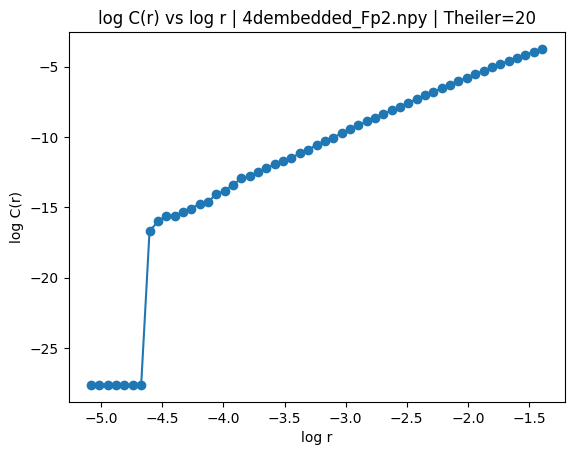

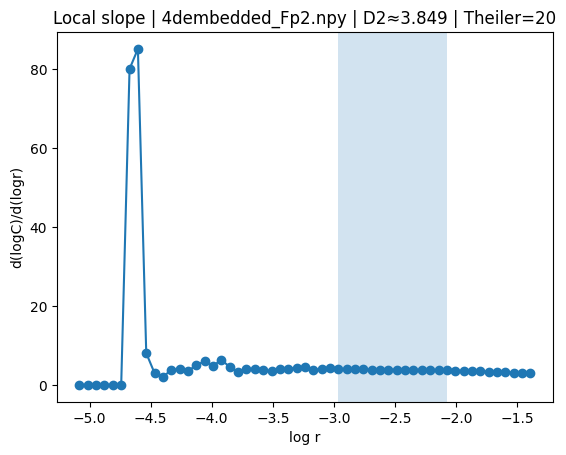

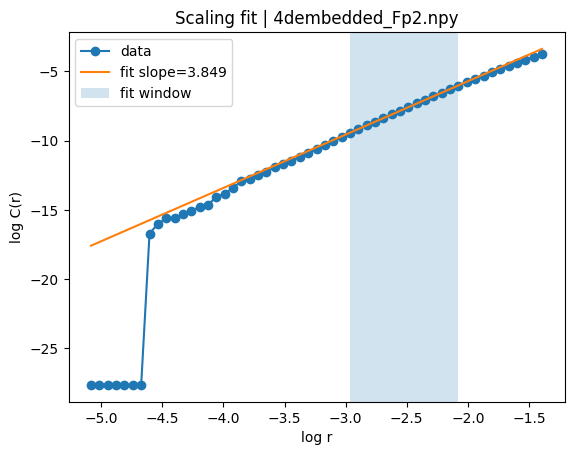

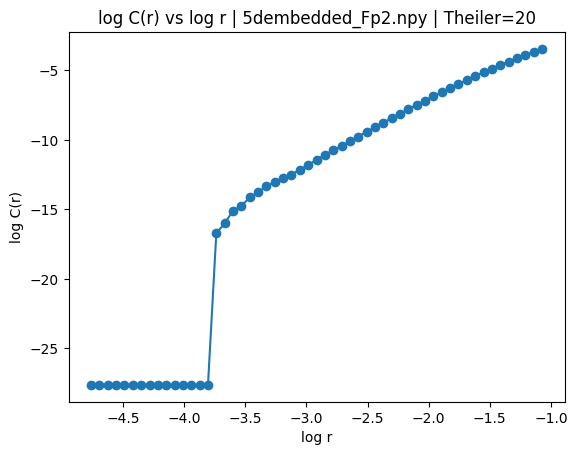

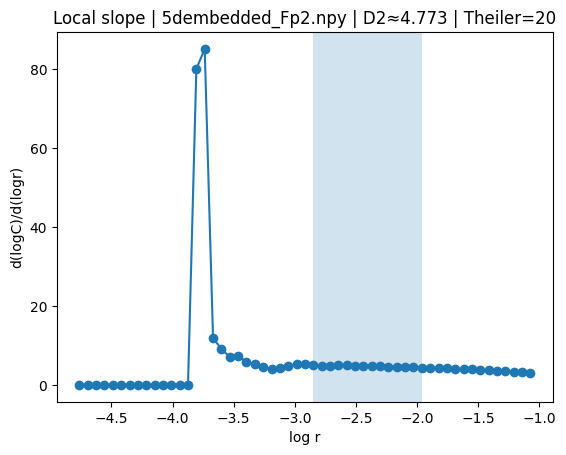

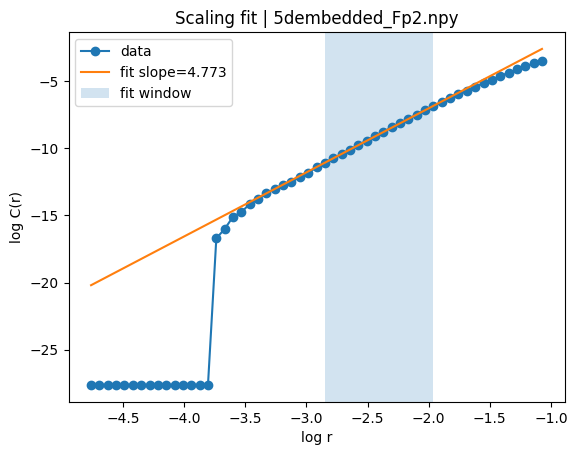

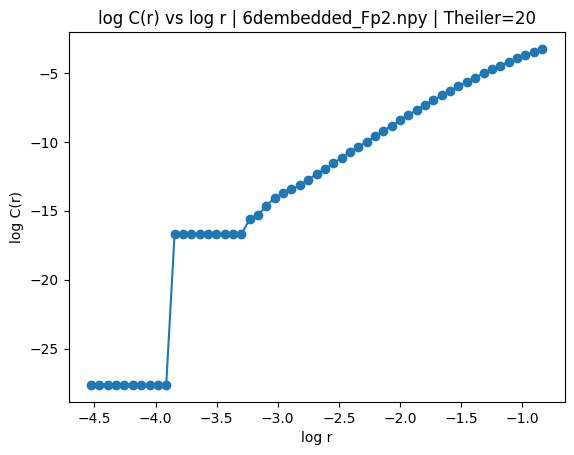

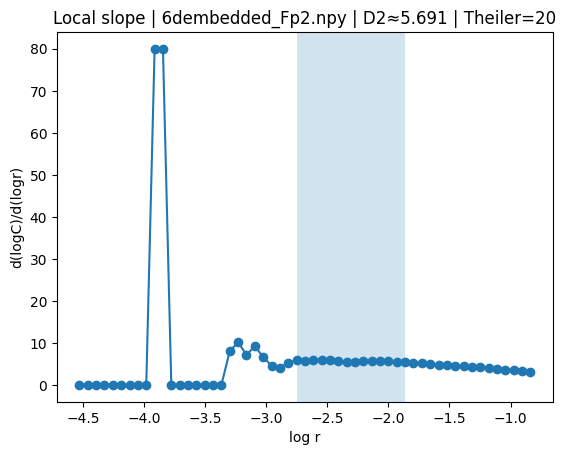

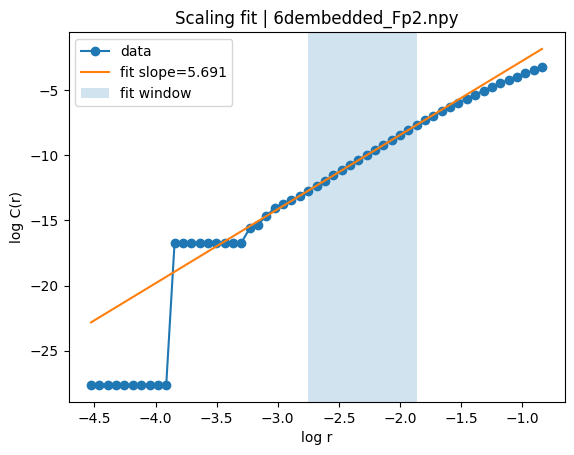

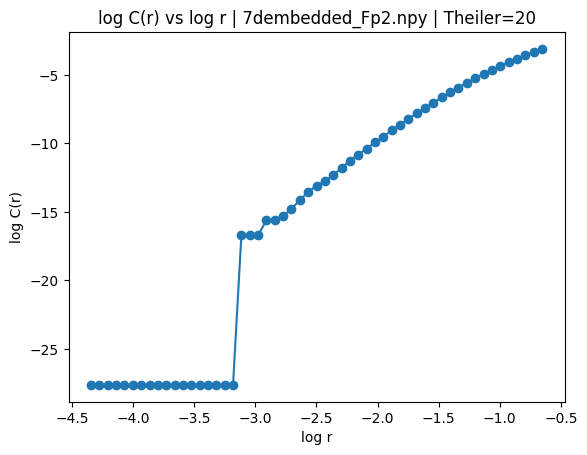

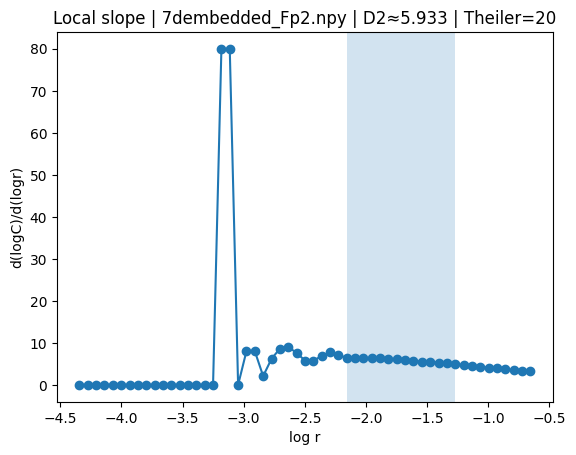

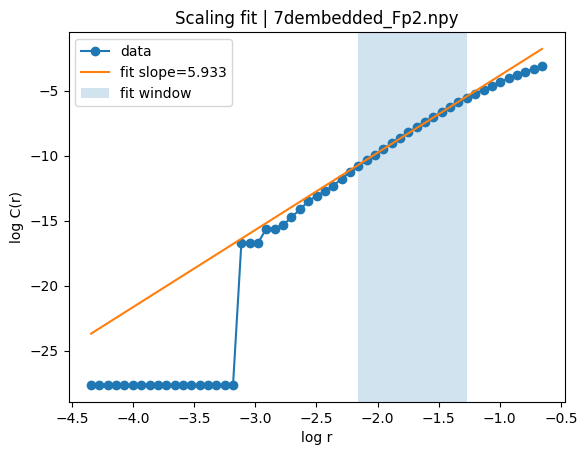

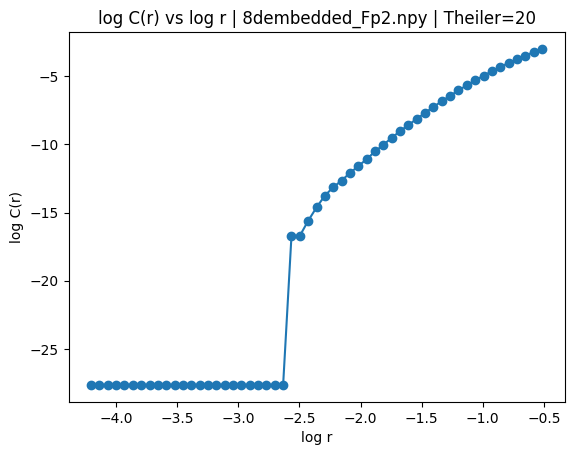

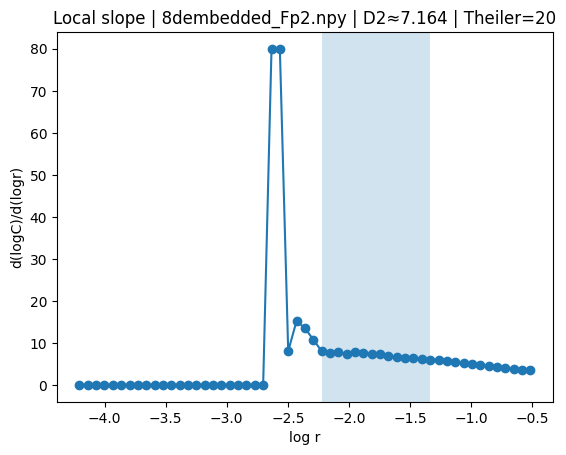

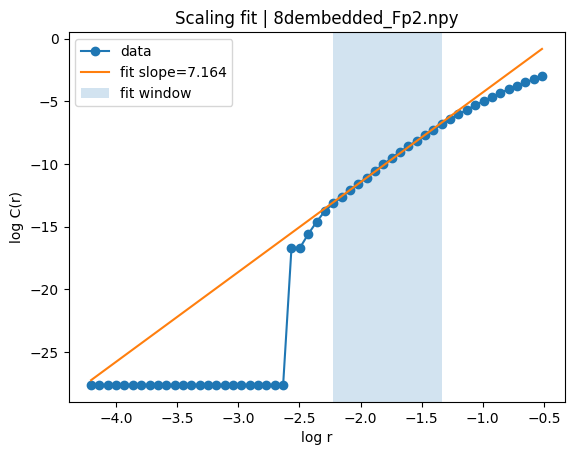

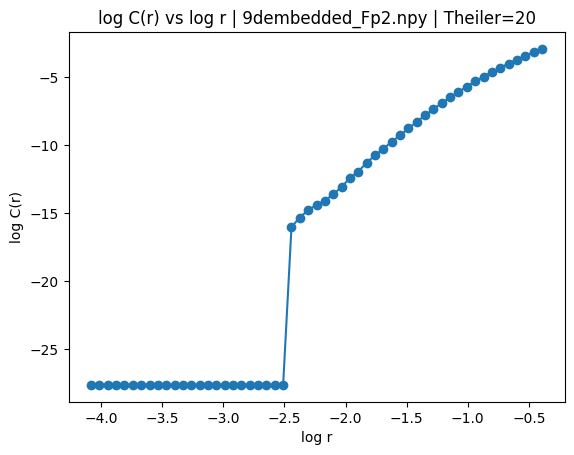

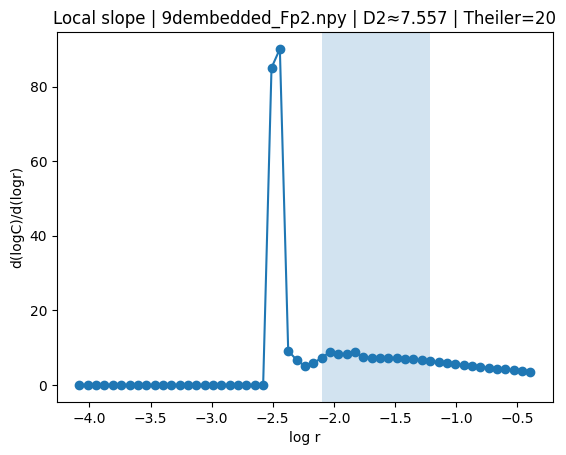

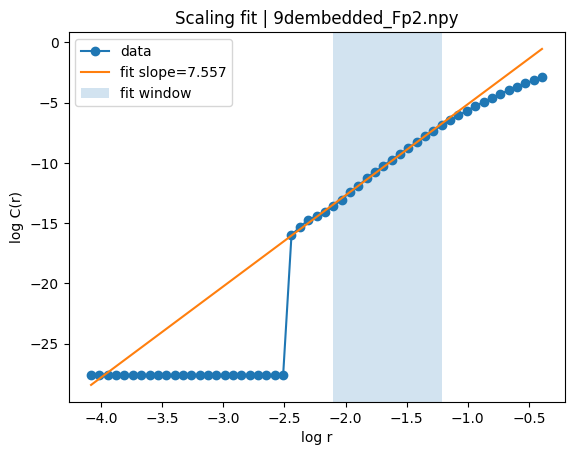

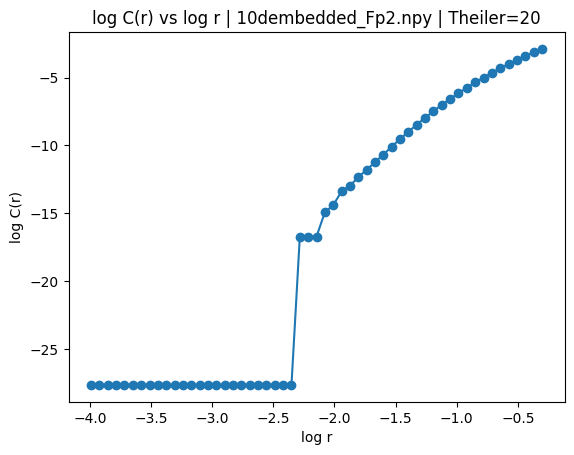

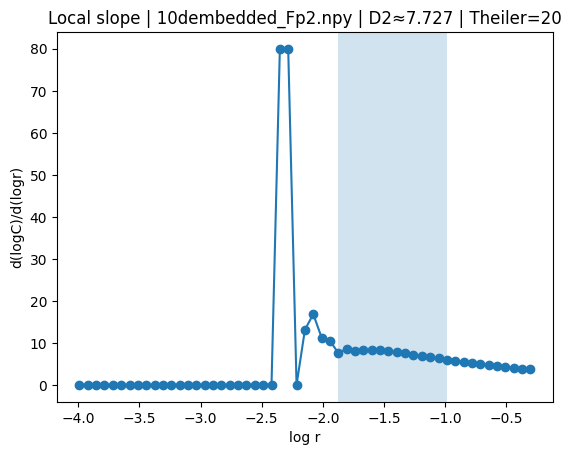

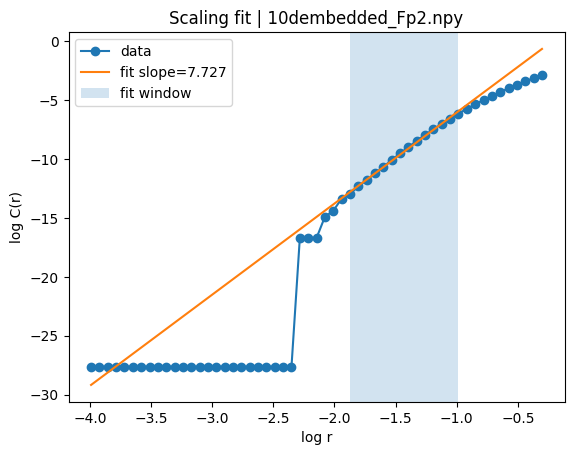


=== D2 vs embedding dimension m ===
m= 4 -> D2≈3.849  (fit idx 31:44, logr≈[-2.96,-2.08])
m= 5 -> D2≈4.773  (fit idx 28:41, logr≈[-2.85,-1.96])
m= 6 -> D2≈5.691  (fit idx 26:39, logr≈[-2.75,-1.86])
m= 7 -> D2≈5.933  (fit idx 32:45, logr≈[-2.16,-1.27])
m= 8 -> D2≈7.164  (fit idx 29:42, logr≈[-2.22,-1.34])
m= 9 -> D2≈7.557  (fit idx 29:42, logr≈[-2.10,-1.21])
m=10 -> D2≈7.727  (fit idx 31:44, logr≈[-1.87,-0.99])

D2 range: 3.849312801360951 to 7.726698910653498
ΔD2: 3.877386109292547


In [3]:
import os, zipfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Paths
# ============================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
zip_path = os.path.join(base_dir, "embedded_data_4to10.zip")
emb_dir  = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

# Unzip if needed
if (not os.path.isdir(emb_dir)) or (len(os.listdir(emb_dir)) == 0):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Couldn't find {emb_dir} or {zip_path}")
    os.makedirs(emb_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(emb_dir)
    print("Unzipped into:", emb_dir)

# ============================================================
# Utilities
# ============================================================
def standardize_cols(X):
    """Column-wise z-score. Returns 2D array."""
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = (X - np.mean(X)) / (np.std(X) + 1e-12)
        return X.reshape(-1, 1)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def choose_r_range_from_knn(X, k=10):
    """Pick r-range based on typical distance to k-th neighbor."""
    k = min(k, len(X))
    nn = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(X)
    dists, _ = nn.kneighbors(X)
    dscale = np.median(dists[:, -1])
    r_min = dscale * 0.05
    r_max = dscale * 2.0
    return r_min, r_max, dscale

def gp_corr_sum_with_theiler(X, rs, theiler=0):
    """
    Approximate correlation sum using radius-neighbor counts,
    excluding temporal neighbors within +/- theiler indices.
    IMPORTANT: X must be in time order.
    """
    X = np.asarray(X, dtype=float)
    N = len(X)
    nn = NearestNeighbors(algorithm="auto").fit(X)

    Cs = []
    for r in rs:
        neigh = nn.radius_neighbors(X, radius=r, return_distance=False)
        total = 0
        for i, inds in enumerate(neigh):
            inds = inds[inds != i]  # drop self
            if theiler > 0 and len(inds) > 0:
                inds = inds[np.abs(inds - i) > theiler]
            total += len(inds)

        # average neighbors per point; normalize by (N-1) so C(r) ~ [0,1]
        c = (total / N) / max(N - 1, 1)
        Cs.append(max(c, 1e-12))
    return np.array(Cs)

def pick_flat_slope_window(local_slope, min_len=12, lo_frac=0.25, hi_frac=0.85):
    """
    Auto-pick a window where slope is flattest (lowest std),
    within the middle [lo_frac, hi_frac] portion of scales.
    Returns (fit_lo, fit_hi) indices.
    """
    local_slope = np.asarray(local_slope, dtype=float)
    n = len(local_slope)
    lo = int(lo_frac * n)
    hi = int(hi_frac * n)
    if hi - lo < min_len:
        return None

    best = None
    for start in range(lo, hi - min_len + 1):
        end = start + min_len
        seg = local_slope[start:end]
        score = np.nanstd(seg)
        if best is None or score < best[0]:
            best = (score, start, end - 1)
    return (best[1], best[2]) if best else None

def refine_window_avoid_spikes(logr, local_slope, fit_lo, fit_hi,
                              max_reasonable_slope=20.0,
                              max_frac_bad=0.15):
    """
    Guardrail: if the chosen window includes spike-y slopes (like 60+),
    shrink it inward until it's mostly in a plateau-ish region.

    - max_reasonable_slope: above this is considered 'bad' spike
    - max_frac_bad: allowed fraction of bad points inside window
    """
    s = np.asarray(local_slope, float)
    lo, hi = fit_lo, fit_hi

    def frac_bad(a, b):
        seg = s[a:b+1]
        return np.mean(~np.isfinite(seg) | (seg > max_reasonable_slope))

    # If too many bad points, shrink inward
    while (hi - lo + 1) >= 6 and frac_bad(lo, hi) > max_frac_bad:
        # drop the worse end (higher average slope or more bad)
        left_bad = frac_bad(lo, hi-1)
        right_bad = frac_bad(lo+1, hi)
        # prefer removing the side that improves bad fraction more
        if right_bad < left_bad:
            lo += 1
        else:
            hi -= 1

    return lo, hi

# ============================================================
# Config
# ============================================================
channel = "Fp2"
ms = list(range(4, 11))    # 4..10
THEILER = 20               # try 0, tau, 2*tau, etc.
n_points = 6000            # subsample size (keep order!)
n_r = 55                   # radii grid resolution
k_scale = 10

# If you want reproducible subsampling:
rng = np.random.default_rng(0)

summary = []

# ============================================================
# Main loop: run GP per m
# ============================================================
for m in ms:
    fname = f"{m}dembedded_{channel}.npy"
    fpath = os.path.join(emb_dir, fname)
    if not os.path.exists(fpath):
        print("Missing:", fname, "(skipping)")
        continue

    Xfull = standardize_cols(np.load(fpath))
    if Xfull.shape[1] != m:
        raise ValueError(f"{fname} has shape {Xfull.shape}, expected (*,{m})")

    # Subsample but KEEP TIME ORDER (critical for Theiler)
    N = len(Xfull)
    if N > n_points:
        idx = np.sort(rng.choice(N, size=n_points, replace=False))
        X = Xfull[idx]
    else:
        X = Xfull

    r_min, r_max, dscale = choose_r_range_from_knn(X, k=k_scale)
    rs = np.logspace(np.log10(r_min), np.log10(r_max), n_r)

    Cs = gp_corr_sum_with_theiler(X, rs, theiler=THEILER)
    logr = np.log(rs)
    logC = np.log(Cs)

    # local slope
    local_slope = np.gradient(logC, logr)

    # auto-pick flat window, then refine to avoid spike region
    win = pick_flat_slope_window(local_slope, min_len=14, lo_frac=0.25, hi_frac=0.85)
    if win is None:
        raise RuntimeError("Auto window failed. Try increasing n_r or n_points.")
    fit_lo, fit_hi = win
    fit_lo, fit_hi = refine_window_avoid_spikes(
        logr, local_slope, fit_lo, fit_hi,
        max_reasonable_slope=20.0,
        max_frac_bad=0.10
    )

    if fit_hi <= fit_lo:
        raise RuntimeError("Window refinement collapsed. Try changing THEILER or n_r/n_points.")

    # Fit slope in the selected scaling window
    coef = np.polyfit(logr[fit_lo:fit_hi+1], logC[fit_lo:fit_hi+1], 1)
    d2_hat = float(coef[0])

    summary.append((m, d2_hat, fit_lo, fit_hi, float(logr[fit_lo]), float(logr[fit_hi])))

    # -------------------------
    # Plots
    # -------------------------
    plt.figure()
    plt.plot(logr, logC, marker="o")
    plt.title(f"log C(r) vs log r | {fname} | Theiler={THEILER}")
    plt.xlabel("log r")
    plt.ylabel("log C(r)")
    plt.show()

    plt.figure()
    plt.plot(logr, local_slope, marker="o")
    plt.axvspan(logr[fit_lo], logr[fit_hi], alpha=0.2)
    plt.title(f"Local slope | {fname} | D2≈{d2_hat:.3f} | Theiler={THEILER}")
    plt.xlabel("log r")
    plt.ylabel("d(logC)/d(logr)")
    plt.show()

    fit_line = np.polyval(coef, logr)
    plt.figure()
    plt.plot(logr, logC, marker="o", label="data")
    plt.plot(logr, fit_line, label=f"fit slope={d2_hat:.3f}")
    plt.axvspan(logr[fit_lo], logr[fit_hi], alpha=0.2, label="fit window")
    plt.title(f"Scaling fit | {fname}")
    plt.xlabel("log r")
    plt.ylabel("log C(r)")
    plt.legend()
    plt.show()

# ============================================================
# Print summary
# ============================================================
print("\n=== D2 vs embedding dimension m ===")
for m, d2, lo, hi, a, b in summary:
    print(f"m={m:2d} -> D2≈{d2:.3f}  (fit idx {lo}:{hi}, logr≈[{a:.2f},{b:.2f}])")

d2_vals = np.array([s[1] for s in summary], float)
print("\nD2 range:", float(d2_vals.min()), "to", float(d2_vals.max()))
print("ΔD2:", float(d2_vals.max() - d2_vals.min()))


In [3]:
import numpy as np

d2_by_m = {
    4: 2.948,
    5: 2.997,
    6: 3.033,
    7: 3.056,
    8: 3.097,
    9: 3.177,
    10: 3.169
}

plateau_ms = [6,7,8,9,10]
vals = np.array([d2_by_m[m] for m in plateau_ms], dtype=float)

print("Plateau m:", plateau_ms)
print("D2 mean:", vals.mean())
print("D2 std :", vals.std(ddof=1))
print("D2 min/max:", vals.min(), vals.max())


Plateau m: [6, 7, 8, 9, 10]
D2 mean: 3.1064
D2 std : 0.06503691259584825
D2 min/max: 3.033 3.177


In [6]:
import numpy as np

def kaplan_yorke_dim(lams):
    lams = np.array(lams, dtype=float)
    lams = np.sort(lams)[::-1]  # descending
    s = 0.0
    for j in range(len(lams)):
        s_next = s + lams[j]
        if s_next < 0:
            # interpolate between j-1 and j
            return j + s / abs(lams[j])
        s = s_next
    return float(len(lams))

# example: your dict lyapunov_exponents maps name -> [l1,l2,l3]
for k,v in lyapunov_exponents.items():
    dky = kaplan_yorke_dim(v)
    print(k, "DKY≈", dky)


3dembedded_CP2 DKY≈ 2.358764850301787
3dembedded_Fp1 DKY≈ 3.0
3dembedded_O2 DKY≈ 3.0
3dembedded_Fpz DKY≈ 2.742103009515995
3dembedded_FC1 DKY≈ 2.5195160862636934
3dembedded_T8 DKY≈ 2.9441407439002045
3dembedded_FC6 DKY≈ 2.596092750750088
3dembedded_POz DKY≈ 2.551208481664866
3dembedded_Fp2 DKY≈ 2.7127582737506675
3dembedded_P3 DKY≈ 2.645928638027346
3dembedded_CP6 DKY≈ 2.879278457276557
3dembedded_FC2 DKY≈ 2.5976990282269736
3dembedded_P8 DKY≈ 3.0
3dembedded_M1 DKY≈ 2.905628859141066
3dembedded_Fz DKY≈ 2.691092098411277
3dembedded_M2 DKY≈ 3.0
3dembedded_C3 DKY≈ 2.608474072476076
3dembedded_T7 DKY≈ 3.0
3dembedded_F3 DKY≈ 3.0
3dembedded_P4 DKY≈ 2.7358799085720165
3dembedded_C4 DKY≈ 2.4145484666425694
3dembedded_Oz DKY≈ 2.891714786774874
3dembedded_P7 DKY≈ 3.0
3dembedded_F7 DKY≈ 3.0
3dembedded_CP5 DKY≈ 3.0
3dembedded_F8 DKY≈ 2.8522143626026155
3dembedded_Pz DKY≈ 2.468365633801819
3dembedded_FC5 DKY≈ 3.0
3dembedded_Cz DKY≈ 2.439959332518702
3dembedded_F4 DKY≈ 2.5980758871656864
3dembedded_

### Lyapunov spectrum estimation

In [9]:
import os
import numpy as np
from nolds.measures import lyap_e
from datetime import datetime

# -----------------------------
# Kaplan–Yorke dimension
# -----------------------------
def kaplan_yorke_dim(lams):
    lams = np.array(lams, dtype=float)
    lams = np.sort(lams)[::-1]
    s = 0.0
    for j in range(len(lams)):
        s_next = s + lams[j]
        if s_next < 0:
            return j + s / abs(lams[j])
        s = s_next
    return float(len(lams))

# -----------------------------
# Paths
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
emb_dir  = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

results_dir = os.path.join(base_dir, "lyapunov_results_10D")
os.makedirs(results_dir, exist_ok=True)

# -----------------------------
# Config
# -----------------------------
channel = "C3"        # <-- change channel here
emb_dim = 10
matrix_dim = 10       # must satisfy (emb_dim-1)%(matrix_dim-1)==0

fname = f"{emb_dim}dembedded_{channel}.npy"
fpath = os.path.join(emb_dir, fname)

if not os.path.exists(fpath):
    raise FileNotFoundError(f"Missing file: {fpath}")

# -----------------------------
# Load data
# -----------------------------
Xemb = np.load(fpath)

# Use first coordinate as observable
x = Xemb[:, 0].astype(float)
x = (x - x.mean()) / (x.std() + 1e-12)

print("Running Lyapunov spectrum...")
print("Channel:", channel)
print("emb_dim:", emb_dim, "matrix_dim:", matrix_dim)
print("Length:", len(x))

# -----------------------------
# Compute spectrum
# -----------------------------
lams = lyap_e(x, emb_dim=emb_dim, matrix_dim=matrix_dim)

lams = np.array(lams, dtype=float)
dky = kaplan_yorke_dim(lams)
lam_sum = float(np.sum(lams))

print("LEs:", lams)
print("Sum LEs:", lam_sum)
print("DKY:", dky)

# -----------------------------
# Save results
# -----------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

npz_path = os.path.join(results_dir, f"{channel}_LEs_{timestamp}.npz")
txt_path = os.path.join(results_dir, f"{channel}_LEs_{timestamp}.txt")

np.savez(
    npz_path,
    channel=channel,
    emb_dim=emb_dim,
    matrix_dim=matrix_dim,
    lyapunov_exponents=lams,
    sum_les=lam_sum,
    dky=dky
)

with open(txt_path, "w") as f:
    f.write("Lyapunov Spectrum Results\n")
    f.write("=========================\n")
    f.write(f"Channel: {channel}\n")
    f.write(f"Embedding dimension: {emb_dim}\n")
    f.write(f"Matrix dimension: {matrix_dim}\n")
    f.write(f"Data length: {len(x)}\n\n")
    f.write("Lyapunov Exponents:\n")
    for i, val in enumerate(lams):
        f.write(f"λ{i+1}: {val}\n")
    f.write("\n")
    f.write(f"Sum of exponents: {lam_sum}\n")
    f.write(f"Kaplan–Yorke dimension: {dky}\n")

print("\nSaved:")
print("NPZ:", npz_path)
print("TXT:", txt_path)


Running Lyapunov spectrum...
Channel: C3
emb_dim: 10 matrix_dim: 10
Length: 106818
LEs: [ 0.14545391  0.08893829  0.04837117  0.01316467 -0.02126144 -0.05807088
 -0.1052289  -0.16839427 -0.28671887 -0.67351814]
Sum LEs: -1.0172644617571063
DKY: 7.6613456262815856

Saved:
NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D/C3_LEs_20260219_183736.npz
TXT: /home/a/projects/Complete-Neural-Signal-Analysis/lyapunov_results_10D/C3_LEs_20260219_183736.txt


### Surrogate testing

In [10]:
# Surrogate testing (IAAFT) for NONLINEARITY — no Rosenstein yet.
# This generates IAAFT surrogates that preserve:
#   (1) the amplitude distribution (histogram) and
#   (2) the power spectrum (approximately)
# Then it runs a standard surrogate hypothesis test using a nonlinear statistic
# (time-reversal asymmetry), and saves everything to disk.

import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir  = os.path.join(base_dir, "surrogate_tests_iaaft")
os.makedirs(out_dir, exist_ok=True)

# Choose your channel + segment (match what you used for embeddings)
channel = "C3"
eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # same "no stim" segment you used
start_idx, end_idx = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Surrogates
n_surr = 40           # 19–99 typical; 39 gives ~p=0.025 resolution
iaaft_iters = 200     # 100–1000; 200 usually ok
seed = 0

# Saving
save_all_surrogates = True   # set False if disk is a concern
save_example_plots  = True

# -----------------------------
# Load data (scalar time series for the channel)
# -----------------------------
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
EEG = np.load(eeg_path, allow_pickle=True)

ch_idx = eeg_channel_names.index(channel)
x = EEG[start_idx:end_idx, ch_idx].astype(float)

# Standardize (recommended for statistics)
x = x - np.mean(x)
x = x / (np.std(x) + 1e-12)

print(f"Loaded {channel}: N={len(x)} samples from [{start_time},{end_time}] sec")

# -----------------------------
# IAAFT surrogate generator
# -----------------------------
def iaaft_surrogate(x, n_iter=200, rng=None):
    """
    Iterative Amplitude Adjusted Fourier Transform surrogate.
    Preserves the original amplitude distribution and approximates the original power spectrum.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if rng is None:
        rng = np.random.default_rng()

    # Target amplitude distribution
    x_sorted = np.sort(x)

    # Target Fourier magnitudes
    X = np.fft.rfft(x)
    mag = np.abs(X)

    # Start from a random shuffle (AAFT-style init)
    y = rng.permutation(x)

    for _ in range(n_iter):
        # Enforce spectrum: replace magnitudes with target mag
        Y = np.fft.rfft(y)
        Y = mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=n)

        # Enforce amplitude distribution via rank-order mapping
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2

    return y

# -----------------------------
# Nonlinear discriminating statistic:
# Time-reversal asymmetry (TRA)
# For linear Gaussian processes, TRA ~ 0.
# One common choice is mean((x[t+1]-x[t])^3), sometimes normalized.
# -----------------------------
def time_reversal_asymmetry(x):
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    # normalize so scale doesn't dominate (optional but helpful)
    sd = np.std(dx) + 1e-12
    return np.mean((dx / sd) ** 3)

# -----------------------------
# Run surrogate test
# -----------------------------
rng = np.random.default_rng(seed)

T_obs = time_reversal_asymmetry(x)
T_surr = np.zeros(n_surr, dtype=float)

# Optionally store surrogates
surr_store = None
if save_all_surrogates:
    surr_store = np.zeros((n_surr, len(x)), dtype=np.float32)

print("Generating IAAFT surrogates...")
for i in range(n_surr):
    y = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
    T_surr[i] = time_reversal_asymmetry(y)
    if save_all_surrogates:
        surr_store[i] = y.astype(np.float32)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{n_surr}")

# Two-sided p-value (rank-based)
# p = (count(|T_surr| >= |T_obs|) + 1) / (n_surr + 1)
p_two = (np.sum(np.abs(T_surr) >= np.abs(T_obs)) + 1.0) / (n_surr + 1.0)

print("\n=== Surrogate nonlinearity test (IAAFT + time-reversal asymmetry) ===")
print(f"Observed TRA: {T_obs:.6g}")
print(f"Surrogate TRA mean±std: {T_surr.mean():.6g} ± {T_surr.std():.6g}")
print(f"Two-sided p-value: {p_two:.6g}")
print("Interpretation: if p < 0.05, reject 'linear stochastic' null (evidence of nonlinearity).")

# -----------------------------
# Save results
# -----------------------------
tag = f"{channel}_{int(start_time*1000)}ms_{int(end_time*1000)}ms_n{n_surr}_it{iaaft_iters}"
npz_path = os.path.join(out_dir, f"iaaft_surrogate_test_{tag}.npz")

save_dict = {
    "channel": channel,
    "fs": sampling_rate,
    "start_time": start_time,
    "end_time": end_time,
    "x": x.astype(np.float32),
    "T_obs": np.array([T_obs], dtype=float),
    "T_surr": T_surr.astype(float),
    "p_two": np.array([p_two], dtype=float),
    "n_surr": np.array([n_surr], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
    "seed": np.array([seed], dtype=int),
}
if save_all_surrogates:
    save_dict["surrogates"] = surr_store  # may be large

np.savez_compressed(npz_path, **save_dict)
print(f"\nSaved NPZ: {npz_path}")

txt_path = os.path.join(out_dir, f"iaaft_surrogate_test_{tag}.txt")
with open(txt_path, "w") as f:
    f.write("IAAFT surrogate test (time-reversal asymmetry)\n")
    f.write(f"channel={channel}\nfs={sampling_rate}\nsegment=[{start_time},{end_time}] sec\n")
    f.write(f"N={len(x)}\n")
    f.write(f"n_surr={n_surr}\niaaft_iters={iaaft_iters}\nseed={seed}\n\n")
    f.write(f"T_obs={T_obs:.12g}\n")
    f.write(f"T_surr_mean={T_surr.mean():.12g}\n")
    f.write(f"T_surr_std={T_surr.std():.12g}\n")
    f.write(f"p_two={p_two:.12g}\n")
print(f"Saved TXT: {txt_path}")

# -----------------------------
# Optional sanity plots:
# - surrogate statistic histogram
# - power spectrum comparison (original vs one surrogate)
# - amplitude distribution comparison
# -----------------------------
if save_example_plots:
    # pick one surrogate to visualize
    y_ex = iaaft_surrogate(x, n_iter=iaaft_iters, rng=np.random.default_rng(seed + 123))

    # Histogram of statistic
    plt.figure()
    plt.hist(T_surr, bins=20)
    plt.axvline(T_obs, linewidth=2)
    plt.axvline(-T_obs, linewidth=2)
    plt.title(f"TRA statistic: surrogates vs observed | {channel} | p={p_two:.3g}")
    plt.xlabel("time-reversal asymmetry statistic")
    plt.ylabel("count")
    fig1 = os.path.join(out_dir, f"TRA_hist_{tag}.png")
    plt.savefig(fig1, dpi=150, bbox_inches="tight")
    plt.close()

    # Power spectrum (magnitude)
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y_ex)
    fx = np.fft.rfftfreq(len(x), d=1.0/sampling_rate)

    plt.figure()
    plt.plot(fx, np.abs(X))
    plt.plot(fx, np.abs(Y))
    plt.xlim(0, 100)  # zoom to 0–100 Hz (change if you want)
    plt.title(f"IAAFT spectrum match (0–100 Hz) | {channel}")
    plt.xlabel("Hz")
    plt.ylabel("|FFT|")
    fig2 = os.path.join(out_dir, f"spectrum_match_{tag}.png")
    plt.savefig(fig2, dpi=150, bbox_inches="tight")
    plt.close()

    # Amplitude CDF (rank match)
    xs = np.sort(x)
    ys = np.sort(y_ex)
    p = np.linspace(0, 1, len(xs), endpoint=False)

    plt.figure()
    plt.plot(p, xs)
    plt.plot(p, ys)
    plt.title(f"Amplitude distribution (CDF) match | {channel}")
    plt.xlabel("quantile")
    plt.ylabel("value")
    fig3 = os.path.join(out_dir, f"amplitude_cdf_match_{tag}.png")
    plt.savefig(fig3, dpi=150, bbox_inches="tight")
    plt.close()

    print("\nSaved plots:")
    print(" ", fig1)
    print(" ", fig2)
    print(" ", fig3)

print("\nDone.")


Loaded C3: N=106944 samples from [814.571,921.515] sec
Generating IAAFT surrogates...
  5/40
  10/40
  15/40
  20/40
  25/40
  30/40
  35/40
  40/40

=== Surrogate nonlinearity test (IAAFT + time-reversal asymmetry) ===
Observed TRA: 0.129892
Surrogate TRA mean±std: -0.0216851 ± 0.218458
Two-sided p-value: 0.560976
Interpretation: if p < 0.05, reject 'linear stochastic' null (evidence of nonlinearity).

Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/surrogate_tests_iaaft/iaaft_surrogate_test_C3_814571ms_921515ms_n40_it200.npz
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/surrogate_tests_iaaft/iaaft_surrogate_test_C3_814571ms_921515ms_n40_it200.txt

Saved plots:
  /home/a/projects/Complete-Neural-Signal-Analysis/surrogate_tests_iaaft/TRA_hist_C3_814571ms_921515ms_n40_it200.png
  /home/a/projects/Complete-Neural-Signal-Analysis/surrogate_tests_iaaft/spectrum_match_C3_814571ms_921515ms_n40_it200.png
  /home/a/projects/Complete-Neural-Signal-Analysis/surrogate_te

### Rosenstein LLE and IAAFT surrogate comparison

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

# -----------------------------
# USER CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]
channel = "C3"

fs = 1000
t0, t1 = 814.571, 921.515
start_idx, end_idx = int(t0*fs), int(t1*fs)

emb_dim = 10
tau = 8

# Rosenstein controls
n_ref = 6000
kmax = 200
k_query = 80  # more neighbors to satisfy large Theiler

# Fit window control:
# Option A: LOCK manually (recommended)
LOCK_FIT = True
fit_lo, fit_hi = 10, 60   # <-- try early region first

# Option B: auto-pick ONCE from observed, then lock
AUTO_PICK_ONCE = False
fit_window_len = 30
fit_lo_frac, fit_hi_frac = 0.05, 0.60

# Surrogates
do_surrogates = True
n_surrogates = 40
iaaft_iters = 200
seed = 0

# min_tsep sweep
min_tsep_list = [tau, 2*tau, 50]  # you asked these

# Output
out_dir = os.path.join(base_dir, "rosenstein_sweep_locked_window")
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def delay_embed_1d(x, m, tau):
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau:i*tau+M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    n = len(x)
    Xmag = np.abs(np.fft.rfft(x))
    x_sorted = np.sort(x)
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        phase = Y / (np.abs(Y) + 1e-12)
        y = np.fft.irfft(Xmag * phase, n=n)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def rosenstein_curve(x, m, tau, min_tsep, n_ref, kmax, seed=0, k_query=80):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    if X is None:
        raise ValueError("Embedding failed.")
    M = len(X)

    valid_max = M - kmax - 1
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx

    nn = NearestNeighbors(n_neighbors=min(k_query, M), algorithm="auto").fit(X)
    dists, inds = nn.kneighbors(X[ref_idx])

    nn_idx = np.full(len(ref_idx), -1, dtype=int)
    for a, i in enumerate(ref_idx):
        for cand in inds[a, 1:]:
            if abs(int(cand) - int(i)) > min_tsep:
                nn_idx[a] = int(cand)
                break

    keep = nn_idx >= 0
    ref_idx = ref_idx[keep]
    nn_idx = nn_idx[keep]
    if len(ref_idx) < 100:
        raise ValueError(f"Too few pairs after Theiler exclusion (min_tsep={min_tsep}).")

    log_div = np.zeros(kmax, dtype=float)
    counts = np.zeros(kmax, dtype=int)

    for k in range(kmax):
        i = ref_idx + k
        j = nn_idx + k
        ok = (i < M) & (j < M)
        if not np.any(ok):
            continue
        dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
        dist = np.maximum(dist, 1e-12)
        log_div[k] = np.mean(np.log(dist))
        counts[k] = np.sum(ok)

    ks = np.arange(kmax)
    return ks, log_div, counts

def fit_slope_locked(ks, log_div, fit_lo, fit_hi):
    xw = ks[fit_lo:fit_hi+1]
    yw = log_div[fit_lo:fit_hi+1]
    coef = np.polyfit(xw, yw, 1)
    return float(coef[0]), float(coef[1])

def auto_pick_fit_window(ks, log_div, fit_len=30, lo_frac=0.05, hi_frac=0.60):
    n = len(ks)
    lo = int(lo_frac * n)
    hi = int(hi_frac * n)
    best = None
    for start in range(lo, hi - fit_len + 1):
        end = start + fit_len
        xw = ks[start:end]
        yw = log_div[start:end]
        if not np.all(np.isfinite(yw)):
            continue
        coef = np.polyfit(xw, yw, 1)
        yhat = np.polyval(coef, xw)
        score = float(np.std(yw - yhat))
        if best is None or score < best[0]:
            best = (score, start, end - 1)
    if best is None:
        raise RuntimeError("Auto-pick failed.")
    return best[1], best[2]

# -----------------------------
# Load data
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
ch_i = channel_names.index(channel)
x = EEG[start_idx:end_idx, ch_i].astype(float)
x = (x - np.mean(x)) / (np.std(x) + 1e-12)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"{channel}_m{emb_dim}_tau{tau}_{stamp}"

print(f"Loaded {channel}: N={len(x)} | segment=[{t0},{t1}] s | fs={fs}")

# If you want auto-pick ONCE from observed, do it at the first min_tsep (usually tau)
if AUTO_PICK_ONCE:
    ks0, ld0, _ = rosenstein_curve(x, emb_dim, tau, min_tsep_list[0], n_ref, kmax, seed=seed, k_query=k_query)
    fit_lo, fit_hi = auto_pick_fit_window(ks0, ld0, fit_len=fit_window_len, lo_frac=fit_lo_frac, hi_frac=fit_hi_frac)
    print(f"AUTO-PICKED (locked) fit window: k=[{fit_lo},{fit_hi}] (~[{fit_lo/fs:.3f},{fit_hi/fs:.3f}] s)")

print(f"LOCKED fit window: k=[{fit_lo},{fit_hi}] (~[{fit_lo/fs:.3f},{fit_hi/fs:.3f}] s)")

results = []

# -----------------------------
# Sweep min_tsep (Observed + Surrogates)
# -----------------------------
rng = np.random.default_rng(seed)

for min_tsep in min_tsep_list:
    print("\n-----------------------------")
    print(f"min_tsep = {min_tsep}")
    ks, ld, ct = rosenstein_curve(x, emb_dim, tau, min_tsep, n_ref, kmax, seed=seed, k_query=k_query)
    slope, intercept = fit_slope_locked(ks, ld, fit_lo, fit_hi)
    lle_obs = slope * fs

    # Surrogates with same locked fit window
    lle_surr = None
    p_one = None
    if do_surrogates:
        lle_surr = np.zeros(n_surrogates, dtype=float)
        for s in range(n_surrogates):
            y = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
            ksS, ldS, _ = rosenstein_curve(y, emb_dim, tau, min_tsep, n_ref, kmax, seed=seed+1000+s, k_query=k_query)
            slopeS, _ = fit_slope_locked(ksS, ldS, fit_lo, fit_hi)
            lle_surr[s] = slopeS * fs
        p_one = (np.sum(lle_surr >= lle_obs) + 1) / (n_surrogates + 1)

    print(f"Observed LLE: {lle_obs:.6g} 1/s")
    if do_surrogates:
        print(f"Surrogate mean±std: {lle_surr.mean():.6g} ± {lle_surr.std(ddof=1):.6g} 1/s")
        print(f"p_one = {p_one:.6g}  (P(LLE_surr >= LLE_obs))")

    results.append((min_tsep, lle_obs, p_one))

    # Plot divergence
    plt.figure(figsize=(8,5))
    plt.plot(ks/fs, ld, marker='o', markersize=3, linewidth=1, label="observed")
    kfit = ks[fit_lo:fit_hi+1]
    yfit = slope * kfit + intercept
    plt.plot(kfit/fs, yfit, linewidth=2, label=f"fit LLE={lle_obs:.3g} 1/s")
    plt.axvspan(fit_lo/fs, fit_hi/fs, alpha=0.15, label="locked fit window")
    plt.title(f"{channel} Rosenstein divergence | min_tsep={min_tsep}")
    plt.xlabel("time (s)")
    plt.ylabel("mean log distance")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"div_{tag}_tsep{min_tsep}.png"), dpi=150)
    plt.close()

    # Plot surrogate hist
    if do_surrogates:
        plt.figure(figsize=(7,4))
        plt.hist(lle_surr, bins=18)
        plt.axvline(lle_obs, linewidth=2, label=f"obs {lle_obs:.3g}")
        plt.title(f"{channel} LLE surrogates | min_tsep={min_tsep} | p={p_one:.3g}")
        plt.xlabel("Rosenstein LLE (1/s)")
        plt.ylabel("count")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"hist_{tag}_tsep{min_tsep}.png"), dpi=150)
        plt.close()

    # Save NPZ per min_tsep
    np.savez(
        os.path.join(out_dir, f"rosenstein_locked_{tag}_tsep{min_tsep}.npz"),
        channel=channel, fs=fs, t0=t0, t1=t1,
        emb_dim=emb_dim, tau=tau, min_tsep=min_tsep,
        fit_lo=fit_lo, fit_hi=fit_hi,
        ks=ks, log_div=ld, counts=ct,
        lle_obs=lle_obs,
        lle_surr=lle_surr,
        p_one=p_one
    )

# summary txt
txt_path = os.path.join(out_dir, f"summary_{tag}.txt")
with open(txt_path, "w") as f:
    f.write("min_tsep\tLLE_obs(1/s)\tp_one\n")
    for min_tsep, lle_obs, p_one in results:
        f.write(f"{min_tsep}\t{lle_obs:.10g}\t{p_one if p_one is not None else 'NA'}\n")

print("\nSaved outputs to:", out_dir)
print("Summary:", txt_path)
print("Done.")

Loaded C3: N=106944 | segment=[814.571,921.515] s | fs=1000
LOCKED fit window: k=[10,60] (~[0.010,0.060] s)

-----------------------------
min_tsep = 8
Observed LLE: 5.1779 1/s
Surrogate mean±std: 3.63941 ± 0.157556 1/s
p_one = 0.0243902  (P(LLE_surr >= LLE_obs))

-----------------------------
min_tsep = 16
Observed LLE: 5.1779 1/s
Surrogate mean±std: 3.66287 ± 0.16116 1/s
p_one = 0.0243902  (P(LLE_surr >= LLE_obs))

-----------------------------
min_tsep = 50
Observed LLE: 5.18353 1/s
Surrogate mean±std: 3.58599 ± 0.195935 1/s
p_one = 0.0243902  (P(LLE_surr >= LLE_obs))

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/rosenstein_sweep_locked_window
Summary: /home/a/projects/Complete-Neural-Signal-Analysis/rosenstein_sweep_locked_window/summary_C3_m10_tau8_20260219_195539.txt
Done.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

# -----------------------------
# USER CONFIG (same as your run)
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]
channel = "C3"

fs = 1000
t0, t1 = 814.571, 921.515
start_idx, end_idx = int(t0*fs), int(t1*fs)

emb_dim = 10
tau = 8

# locked fit window
fit_lo, fit_hi = 10, 60

# sweep values
min_tsep_list = [tau, 2*tau, 50]

# Rosenstein controls
n_ref = 6000
kmax = 200
k_query = 80

# Surrogates 
n_surrogates = 199     
iaaft_iters = 200
seed = 0

out_dir = os.path.join(base_dir, "rosenstein_sweep_locked_window_moreS")
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def delay_embed_1d(x, m, tau):
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau:i*tau+M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    n = len(x)
    Xmag = np.abs(np.fft.rfft(x))
    x_sorted = np.sort(x)
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        phase = Y / (np.abs(Y) + 1e-12)
        y = np.fft.irfft(Xmag * phase, n=n)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def rosenstein_curve(x, m, tau, min_tsep, n_ref, kmax, seed=0, k_query=80):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    if X is None:
        raise ValueError("Embedding failed.")
    M = len(X)

    valid_max = M - kmax - 1
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx

    nn = NearestNeighbors(n_neighbors=min(k_query, M), algorithm="auto").fit(X)
    dists, inds = nn.kneighbors(X[ref_idx])

    nn_idx = np.full(len(ref_idx), -1, dtype=int)
    for a, i in enumerate(ref_idx):
        for cand in inds[a, 1:]:
            if abs(int(cand) - int(i)) > min_tsep:
                nn_idx[a] = int(cand)
                break

    keep = nn_idx >= 0
    ref_idx = ref_idx[keep]
    nn_idx = nn_idx[keep]
    if len(ref_idx) < 100:
        raise ValueError(f"Too few pairs after Theiler exclusion (min_tsep={min_tsep}).")

    log_div = np.zeros(kmax, dtype=float)
    counts = np.zeros(kmax, dtype=int)

    for k in range(kmax):
        i = ref_idx + k
        j = nn_idx + k
        ok = (i < M) & (j < M)
        if not np.any(ok):
            continue
        dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
        dist = np.maximum(dist, 1e-12)
        log_div[k] = np.mean(np.log(dist))
        counts[k] = np.sum(ok)

    ks = np.arange(kmax)
    return ks, log_div, counts

def fit_slope(ks, log_div, lo, hi):
    xw = ks[lo:hi+1]
    yw = log_div[lo:hi+1]
    coef = np.polyfit(xw, yw, 1)
    return float(coef[0]), float(coef[1])

# -----------------------------
# Load + preprocess
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
ch_i = channel_names.index(channel)
x = EEG[start_idx:end_idx, ch_i].astype(float)
x = (x - np.mean(x)) / (np.std(x) + 1e-12)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"{channel}_m{emb_dim}_tau{tau}_nS{n_surrogates}_{stamp}"

print(f"Loaded {channel}: N={len(x)} | segment=[{t0},{t1}] s | fs={fs}")
print(f"LOCKED fit window: k=[{fit_lo},{fit_hi}] (~[{fit_lo/fs:.3f},{fit_hi/fs:.3f}] s)")

rng = np.random.default_rng(seed)
summary = []

for min_tsep in min_tsep_list:
    ks, ld, ct = rosenstein_curve(x, emb_dim, tau, min_tsep, n_ref, kmax, seed=seed, k_query=k_query)
    slope, intercept = fit_slope(ks, ld, fit_lo, fit_hi)
    lle_obs = slope * fs

    lle_surr = np.zeros(n_surrogates, dtype=float)
    for s in range(n_surrogates):
        y = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
        ksS, ldS, _ = rosenstein_curve(y, emb_dim, tau, min_tsep, n_ref, kmax, seed=seed+1000+s, k_query=k_query)
        slopeS, _ = fit_slope(ksS, ldS, fit_lo, fit_hi)
        lle_surr[s] = slopeS * fs
        if (s+1) % 25 == 0:
            print(f"  min_tsep={min_tsep}  {s+1}/{n_surrogates}")

    p_one = (np.sum(lle_surr >= lle_obs) + 1) / (n_surrogates + 1)
    print(f"\nmin_tsep={min_tsep} | obs={lle_obs:.6g} | surr mean±std={lle_surr.mean():.6g}±{lle_surr.std(ddof=1):.6g} | p={p_one:.6g}")

    summary.append((min_tsep, lle_obs, lle_surr.mean(), lle_surr.std(ddof=1), p_one))

    # save
    np.savez(
        os.path.join(out_dir, f"rosenstein_moreS_{tag}_tsep{min_tsep}.npz"),
        channel=channel, fs=fs, t0=t0, t1=t1,
        emb_dim=emb_dim, tau=tau, min_tsep=min_tsep,
        fit_lo=fit_lo, fit_hi=fit_hi,
        ks=ks, log_div=ld, counts=ct,
        lle_obs=lle_obs,
        lle_surr=lle_surr,
        p_one=p_one
    )

    # quick histogram
    plt.figure(figsize=(7,4))
    plt.hist(lle_surr, bins=22)
    plt.axvline(lle_obs, linewidth=2, label=f"obs {lle_obs:.3g}")
    plt.title(f"{channel} LLE surrogates | min_tsep={min_tsep} | p={p_one:.3g}")
    plt.xlabel("Rosenstein LLE (1/s)")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"hist_{tag}_tsep{min_tsep}.png"), dpi=150)
    plt.close()

# summary txt
txt = os.path.join(out_dir, f"summary_{tag}.txt")
with open(txt, "w") as f:
    f.write("min_tsep\tLLE_obs\tLLE_surr_mean\tLLE_surr_std\tp_one\n")
    for row in summary:
        f.write("\t".join(str(x) for x in row) + "\n")

print("\nSaved to:", out_dir)
print("Summary:", txt)
print("Done.")

Loaded C3: N=106944 | segment=[814.571,921.515] s | fs=1000
LOCKED fit window: k=[10,60] (~[0.010,0.060] s)
  min_tsep=8  25/199
  min_tsep=8  50/199
  min_tsep=8  75/199
  min_tsep=8  100/199
  min_tsep=8  125/199
  min_tsep=8  150/199
  min_tsep=8  175/199

min_tsep=8 | obs=5.1779 | surr mean±std=3.6489±0.16703 | p=0.005
  min_tsep=16  25/199
  min_tsep=16  50/199
  min_tsep=16  75/199
  min_tsep=16  100/199
  min_tsep=16  125/199
  min_tsep=16  150/199
  min_tsep=16  175/199

min_tsep=16 | obs=5.1779 | surr mean±std=3.68532±0.166457 | p=0.005
  min_tsep=50  25/199
  min_tsep=50  50/199
  min_tsep=50  75/199
  min_tsep=50  100/199
  min_tsep=50  125/199
  min_tsep=50  150/199
  min_tsep=50  175/199

min_tsep=50 | obs=5.18353 | surr mean±std=3.63896±0.167928 | p=0.005

Saved to: /home/a/projects/Complete-Neural-Signal-Analysis/rosenstein_sweep_locked_window_moreS
Summary: /home/a/projects/Complete-Neural-Signal-Analysis/rosenstein_sweep_locked_window_moreS/summary_C3_m10_tau8_nS199_20

### Robust Rosenstein Window Sweep

Loaded C3: N=106944

--------------------------------
Window: (5, 30)
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
Observed: 0.0003447814612089525
Surrogate mean±std: -4.813443642590451e-05 ± 0.0015737270377862386
p-value: 0.4221105527638191

--------------------------------
Window: (10, 60)
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
Observed: 0.0008696195577784678
Surrogate mean±std: -8.024004674411889e-05 ± 0.0012788995602339326
p-value: 0.23115577889447236

--------------------------------
Window: (10, 80)
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
Observed: 0.0007915007751369317
Surrogate mean±std: 1.685159731241591e-05 ± 0.0011832577011152948
p-value: 0.2613065326633166

--------------------------------
Window: (20, 100)
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
Observed: 0.0005913841112412745
Surrogate mean±std: -0.00018604779684244568 ± 0.0013415078301634784
p-value: 0.2864321608040201

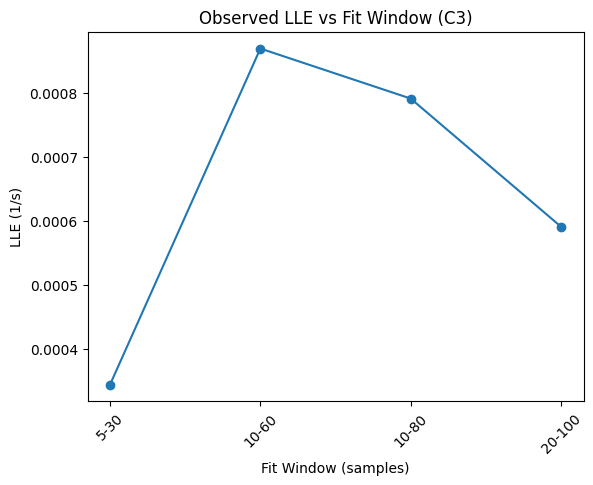


Saved to: /home/a/projects/Complete-Neural-Signal-Analysis/rosenstein_window_robustness/window_sweep_C3_20260219_230723.npz
Done.


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
channel = "C3"
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
fs = 1000

m = 10
tau = 8
min_tsep = 8
kmax = 200
n_ref = 6000
n_surrogates = 199

# Early-time fit windows to test (in samples)
windows = [
    (5, 30),
    (10, 60),
    (10, 80),
    (20, 100)
]

# Output directory
out_dir = os.path.join(base_dir, "rosenstein_window_robustness")
os.makedirs(out_dir, exist_ok=True)

# -------------------------------------------------------
# Load signal
# -------------------------------------------------------
EEG = np.load(os.path.join(base_dir, "eeg_data_with_channels.npy"), allow_pickle=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index = int(start_time * sampling_rate)
end_index   = int(end_time   * sampling_rate)

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

idx = channel_names.index(channel)
x = EEG[start_index:end_index, idx]
x = (x - np.mean(x)) / np.std(x)

print(f"Loaded {channel}: N={len(x)}")

# -------------------------------------------------------
# Delay embedding
# -------------------------------------------------------
def embed(x, m, tau):
    N = len(x)
    M = N - (m-1)*tau
    return np.column_stack([x[i:i+M] for i in range(0, m*tau, tau)])

# -------------------------------------------------------
# Rosenstein LLE
# -------------------------------------------------------
def rosenstein_lle(x, m, tau, min_tsep, kmax, fit_window):
    X = embed(x, m, tau)
    N = len(X)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    dists, inds = nbrs.kneighbors(X)

    nn = inds[:,1]
    valid = np.abs(np.arange(N) - nn) > min_tsep

    d = []
    for k in range(kmax):
        valid_k = valid[:N-k]
        dist_k = np.linalg.norm(X[:N-k][valid_k] - X[nn[:N-k]][valid_k], axis=1)
        d.append(np.mean(dist_k))

    d = np.array(d)
    logd = np.log(d + 1e-12)

    k1, k2 = fit_window
    coef = np.polyfit(np.arange(k1,k2), logd[k1:k2], 1)

    return coef[0] * fs

# -------------------------------------------------------
# IAAFT surrogate generator
# -------------------------------------------------------
def iaaft(x, n_iter=200):
    sorted_x = np.sort(x)
    fft_orig = np.fft.rfft(x)
    mag = np.abs(fft_orig)

    y = np.random.permutation(x)

    for _ in range(n_iter):
        fft_y = np.fft.rfft(y)
        fft_y = mag * np.exp(1j*np.angle(fft_y))
        y = np.fft.irfft(fft_y)
        y = sorted_x[np.argsort(np.argsort(y))]

    return y

# -------------------------------------------------------
# Sweep windows
# -------------------------------------------------------
results = []

for win in windows:
    print("\n--------------------------------")
    print("Window:", win)

    obs = rosenstein_lle(x, m, tau, min_tsep, kmax, win)

    surr_vals = []
    for i in range(n_surrogates):
        s = iaaft(x)
        val = rosenstein_lle(s, m, tau, min_tsep, kmax, win)
        surr_vals.append(val)

        if (i+1) % 25 == 0:
            print(f"  {i+1}/{n_surrogates}")

    surr_vals = np.array(surr_vals)
    p = np.mean(surr_vals >= obs)

    print("Observed:", obs)
    print("Surrogate mean±std:", np.mean(surr_vals), "±", np.std(surr_vals))
    print("p-value:", p)

    results.append((win[0], win[1], obs, np.mean(surr_vals), np.std(surr_vals), p))

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
print("\n==============================")
print("WINDOW ROBUSTNESS SUMMARY")
print("==============================")

for r in results:
    print(f"k={r[0]}-{r[1]} | obs={r[2]:.4f} | surr={r[3]:.4f}±{r[4]:.4f} | p={r[5]:.4f}")

# -------------------------------------------------------
# Plot LLE vs window
# -------------------------------------------------------
obs_vals = [r[2] for r in results]
labels = [f"{r[0]}-{r[1]}" for r in results]

plt.figure()
plt.plot(labels, obs_vals, marker='o')
plt.title(f"Observed LLE vs Fit Window ({channel})")
plt.ylabel("LLE (1/s)")
plt.xlabel("Fit Window (samples)")
plt.xticks(rotation=45)
plt.show()

# -------------------------------------------------------
# Save results
# -------------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = os.path.join(out_dir, f"window_sweep_{channel}_{timestamp}.npz")

np.savez(save_path, results=results)

print("\nSaved to:", save_path)
print("Done.")

### Kantz LLE + IAAFT surrogate comparison

In [1]:
"""
Kantz LLE + IAAFT surrogate comparison (fixed neighbor bounds)
--------------------------------------------------------------
Fix: ensure BOTH reference indices i AND neighbor indices j satisfy
(i + kmax_eff < M) and (j + kmax_eff < M), so X[neighs + k] never OOB.

Requirements: numpy, matplotlib, scikit-learn
"""

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ============================================================
# USER CONFIG
# ============================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNEL = "C3"
fs = 1000.0
start_time = 814.571
end_time   = 921.515

# Embedding / LLE params
m = 10
tau = 8
min_tsep = tau          # Theiler window in samples (try tau, 2*tau, 50, etc.)
kmax = 200              # max forward steps (samples)
n_ref = 6000            # number of reference points
K_use = 20              # neighbors per reference (Kantz averages over neighbors)
K_search = 400          # candidates requested before filtering (increase if many are rejected)

# Fit window on divergence curve y[k], k=1..kmax
fit_k0 = 10
fit_k1 = 60

# Surrogates
n_surrogates = 199
iaaft_iters = 200
seed = 0

# Output
out_dir = os.path.join(base_dir, "kantz_surrogate_lle")
os.makedirs(out_dir, exist_ok=True)

# ============================================================
# Helpers
# ============================================================

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-12)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)

    x_sorted = np.sort(x)
    X = np.fft.rfft(x)
    mag = np.abs(X)

    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        phase = np.angle(Y)
        Y_new = mag * np.exp(1j * phase)
        y = np.fft.irfft(Y_new, n=N)

        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def kantz_lle(x, m, tau, min_tsep, kmax, n_ref, K_use=20, K_search=400, rng=None):
    """
    Returns:
      ks (1..kmax_eff), y_mean, slope_per_sample, info dict
    """
    if rng is None:
        rng = np.random.default_rng()

    X = delay_embed_1d(x, m=m, tau=tau)
    if X is None:
        raise ValueError("Embedding failed: series too short for m,tau")

    M = len(X)

    # Effective kmax must allow i+k and j+k to remain in [0, M-1]
    kmax_eff = min(kmax, M - 2)  # conservative
    if kmax_eff < 5:
        raise ValueError(f"kmax too large for embedded length: M={M}, kmax_eff={kmax_eff}")

    # BOTH i and j must satisfy index + kmax_eff <= M-1
    last_ok = M - 1 - kmax_eff
    if last_ok <= 0:
        raise ValueError(f"Not enough points for kmax_eff={kmax_eff} with M={M}")

    valid = np.arange(0, last_ok + 1)  # inclusive
    n_ref_eff = min(n_ref, len(valid))
    ref_idx = rng.choice(valid, size=n_ref_eff, replace=False)

    # neighbor search in embedded space
    K_search_eff = min(K_search, M)
    nn = NearestNeighbors(n_neighbors=K_search_eff, algorithm="auto").fit(X)
    dists, inds = nn.kneighbors(X[ref_idx], return_distance=True)

    neighbor_sets = []
    for row, i in enumerate(ref_idx):
        cand = inds[row]

        # drop self
        cand = cand[cand != i]

        # Theiler exclusion
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]

        # CRITICAL FIX: neighbors must also be valid for forward evolution up to kmax_eff
        cand = cand[cand <= last_ok]

        if len(cand) < K_use:
            continue

        neighbor_sets.append((i, cand[:K_use]))

    if len(neighbor_sets) < max(100, 0.1 * n_ref_eff):
        raise RuntimeError(
            f"Too few usable refs after filtering: {len(neighbor_sets)} "
            f"(requested {n_ref_eff}). Try increasing K_search or lowering K_use/min_tsep/kmax."
        )

    eps = 1e-12
    ks = np.arange(1, kmax_eff + 1)
    y_acc = np.zeros_like(ks, dtype=float)
    counts = np.zeros_like(ks, dtype=int)

    for (i, neighs) in neighbor_sets:
        # vectorize over k: compute mean log dist at each k
        # (k, m) minus (k, K_use, m)
        Xi = X[i + ks]                    # (kmax_eff, m)
        Xj = X[neighs[:, None] + ks]      # (K_use, kmax_eff, m)
        dif = Xj - Xi[None, :, :]         # (K_use, kmax_eff, m)
        dist = np.linalg.norm(dif, axis=2)  # (K_use, kmax_eff)
        y_acc += np.mean(np.log(dist + eps), axis=0)
        counts += 1

    y_mean = y_acc / np.maximum(counts, 1)

    # fit slope in chosen window
    k0 = max(1, fit_k0)
    k1 = min(kmax_eff, fit_k1)
    if k1 <= k0 + 2:
        raise ValueError("Fit window too small or exceeds kmax_eff")

    mask = (ks >= k0) & (ks <= k1) & np.isfinite(y_mean)
    if mask.sum() < 5:
        raise RuntimeError("Not enough points in fit window for regression")

    coef = np.polyfit(ks[mask], y_mean[mask], 1)
    slope_per_sample = float(coef[0])

    info = dict(
        M=int(M),
        last_ok=int(last_ok),
        kmax_eff=int(kmax_eff),
        n_ref_requested=int(n_ref_eff),
        n_ref_used=int(len(neighbor_sets)),
        K_use=int(K_use),
        K_search=int(K_search_eff),
        fit_k0=int(k0),
        fit_k1=int(k1),
        min_tsep=int(min_tsep),
        m=int(m),
        tau=int(tau),
    )
    return ks, y_mean, slope_per_sample, info

def save_text(path, text):
    with open(path, "w") as f:
        f.write(text)

# ============================================================
# Main
# ============================================================
rng = np.random.default_rng(seed)

EEG = np.load(eeg_path, allow_pickle=True)
ch_i = channel_names.index(CHANNEL)

i0 = int(round(start_time * fs))
i1 = int(round(end_time * fs))
x = EEG[i0:i1, ch_i].astype(float)
print(f"Loaded {CHANNEL}: N={len(x)} samples from [{start_time},{end_time}] sec")

x = zscore(x)

print("Kantz params:",
      f"m={m}, tau={tau}, min_tsep={min_tsep}, kmax={kmax}, n_ref={n_ref}, K_use={K_use}")

# Observed
ks, y_obs, slope_obs_per_sample, info_obs = kantz_lle(
    x, m=m, tau=tau, min_tsep=min_tsep, kmax=kmax,
    n_ref=n_ref, K_use=K_use, K_search=K_search, rng=rng
)
lle_obs_per_sec = slope_obs_per_sample * fs

print("\n=== Observed Kantz LLE ===")
print(f"fit window k=[{info_obs['fit_k0']},{info_obs['fit_k1']}] samples")
print(f"slope (per sample) = {slope_obs_per_sample:.6e}")
print(f"LLE (per second)   = {lle_obs_per_sec:.6f} 1/s")
print("refs used:", info_obs["n_ref_used"], "/", info_obs["n_ref_requested"])
print("embedded length M:", info_obs["M"], "| last_ok:", info_obs["last_ok"], "| kmax_eff:", info_obs["kmax_eff"])

# Surrogates
print("\nGenerating IAAFT surrogates + Kantz LLE...")
lle_surr = np.zeros(n_surrogates, dtype=float)

for s in range(n_surrogates):
    xs = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
    _, _, slope_s_per_sample, _ = kantz_lle(
        xs, m=m, tau=tau, min_tsep=min_tsep, kmax=kmax,
        n_ref=n_ref, K_use=K_use, K_search=K_search, rng=rng
    )
    lle_surr[s] = slope_s_per_sample * fs
    if (s + 1) % 25 == 0:
        print(f"  {s+1}/{n_surrogates}")

mu = float(np.mean(lle_surr))
sd = float(np.std(lle_surr, ddof=1) if n_surrogates > 1 else 0.0)

# one-sided: is observed unusually large?
p_one = float((np.sum(lle_surr >= lle_obs_per_sec) + 1) / (n_surrogates + 1))

print("\n=== Surrogate test: Kantz LLE ===")
print(f"Observed LLE: {lle_obs_per_sec:.6f} 1/s")
print(f"Surrogate mean±std: {mu:.6f} ± {sd:.6f} 1/s")
print(f"One-sided p-value P(LLE_surr >= LLE_obs): {p_one:.6g}")

# ============================================================
# Save outputs
# ============================================================
ts = time.strftime("%Y%m%d_%H%M%S")
tag = f"{CHANNEL}_m{m}_tau{tau}_tsep{min_tsep}_K{K_use}_nRef{n_ref}_nS{n_surrogates}_it{iaaft_iters}_{ts}"

npz_path = os.path.join(out_dir, f"kantz_surrogate_lle_{tag}.npz")
txt_path = os.path.join(out_dir, f"kantz_surrogate_lle_{tag}.txt")

np.savez(
    npz_path,
    channel=CHANNEL, fs=fs, start_time=start_time, end_time=end_time,
    m=m, tau=tau, min_tsep=min_tsep, kmax=kmax, n_ref=n_ref, K_use=K_use, K_search=K_search,
    fit_k0=fit_k0, fit_k1=fit_k1,
    ks=ks, y_obs=y_obs, lle_obs_per_sec=lle_obs_per_sec,
    lle_surr=lle_surr, surrogate_mean=mu, surrogate_std=sd, p_one=p_one,
    info_obs=info_obs
)

summary_txt = f"""Kantz LLE + IAAFT surrogate test
================================
channel: {CHANNEL}
segment: [{start_time},{end_time}] sec
fs: {fs}

Embedding: m={m}, tau={tau}
Theiler (min_tsep): {min_tsep} samples
Kantz: K_use={K_use}, K_search={K_search}
kmax: {kmax} (effective {info_obs['kmax_eff']})
embedded length M: {info_obs['M']} (last_ok={info_obs['last_ok']})
refs used: {info_obs['n_ref_used']} / {info_obs['n_ref_requested']}

Fit window:
  k=[{info_obs['fit_k0']},{info_obs['fit_k1']}] samples
  t=[{info_obs['fit_k0']/fs:.6f},{info_obs['fit_k1']/fs:.6f}] sec

Observed:
  LLE_per_sec={lle_obs_per_sec:.6f} 1/s

Surrogates (IAAFT):
  n_surrogates={n_surrogates}
  iters={iaaft_iters}
  mean±std={mu:.6f} ± {sd:.6f} 1/s
  one-sided p=P(LLE_surr >= LLE_obs)={p_one:.6g}

NPZ: {npz_path}
"""
save_text(txt_path, summary_txt)

# ============================================================
# Plots
# ============================================================
plt.figure()
plt.plot(ks, y_obs, marker="o", markersize=3, linewidth=1, label="mean log distance")
k0, k1 = info_obs["fit_k0"], info_obs["fit_k1"]
mask = (ks >= k0) & (ks <= k1) & np.isfinite(y_obs)
coef = np.polyfit(ks[mask], y_obs[mask], 1)
fit_line = np.polyval(coef, ks)
plt.plot(ks, fit_line, linewidth=2, label=f"fit slope={lle_obs_per_sec:.4f} 1/s")
plt.axvspan(k0, k1, alpha=0.2, label="fit window")
plt.title(f"Kantz divergence + fit ({CHANNEL})")
plt.xlabel("k (samples)")
plt.ylabel("mean log distance")
plt.legend()
div_plot = os.path.join(out_dir, f"kantz_divergence_fit_{tag}.png")
plt.savefig(div_plot, dpi=160, bbox_inches="tight")
plt.close()

plt.figure()
plt.hist(lle_surr, bins=30)
plt.axvline(lle_obs_per_sec, linewidth=2, label=f"obs={lle_obs_per_sec:.4f}")
plt.title(f"Kantz LLE surrogates ({CHANNEL}) | p={p_one:.4g}")
plt.xlabel("LLE (1/s)")
plt.ylabel("count")
plt.legend()
hist_plot = os.path.join(out_dir, f"kantz_lle_surrogates_hist_{tag}.png")
plt.savefig(hist_plot, dpi=160, bbox_inches="tight")
plt.close()

print("\nSaved:")
print("NPZ:", npz_path)
print("TXT:", txt_path)
print("\nSaved plots:")
print(" ", div_plot)
print(" ", hist_plot)
print("\nDone.")

Loaded C3: N=106944 samples from [814.571,921.515] sec
Kantz params: m=10, tau=8, min_tsep=8, kmax=200, n_ref=6000, K_use=20

=== Observed Kantz LLE ===
fit window k=[10,60] samples
slope (per sample) = 3.966339e-03
LLE (per second)   = 3.966339 1/s
refs used: 6000 / 6000
embedded length M: 106872 | last_ok: 106671 | kmax_eff: 200

Generating IAAFT surrogates + Kantz LLE...
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199

=== Surrogate test: Kantz LLE ===
Observed LLE: 3.966339 1/s
Surrogate mean±std: 2.291679 ± 0.122846 1/s
One-sided p-value P(LLE_surr >= LLE_obs): 0.005

Saved:
NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/kantz_surrogate_lle/kantz_surrogate_lle_C3_m10_tau8_tsep8_K20_nRef6000_nS199_it200_20260221_124026.npz
TXT: /home/a/projects/Complete-Neural-Signal-Analysis/kantz_surrogate_lle/kantz_surrogate_lle_C3_m10_tau8_tsep8_K20_nRef6000_nS199_it200_20260221_124026.txt

Saved plots:
  /home/a/projects/Complete-Neural-Signal-Analysis/kantz_surrogate

###  Kantz LLE robustness sweep + IAAFT surrogate test

In [2]:
# - Sweeps fit windows AND min_tsep AND K_use
# - Uses SAME locked fit windows for observed + all surrogates
# - Saves: NPZ + TXT summary + hist plot per setting + one combined summary file
#
# Requirements: numpy, matplotlib, scikit-learn
# (No nolds needed.)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ============================================================
# CONFIG
# ============================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir  = os.path.join(base_dir, "kantz_sweep_locked_windows")
os.makedirs(out_dir, exist_ok=True)

channel = "C3"
fs = 1000
segment = (814.571, 921.515)  # seconds (for labeling only)

# Data source (raw EEG, not embedded)
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# Embedding params (use your chosen)
m = 10
tau = 8

# Surrogates
n_surr = 199
iaaft_iters = 200
seed = 0

# Neighbors
n_ref = 6000
K_search = 60          # search this many nearest neighbors, then keep K_use after Theiler filter
K_uses = [10, 20, 40]  # sweep
min_tseps = [tau, 2*tau, 50]  # sweep

# Fit windows in sample-lags k (lock these)
fit_windows = [(5, 30), (10, 60), (10, 80), (20, 100), (40, 140)]

# Numerical floor
eps = 1e-12

# ============================================================
# HELPERS
# ============================================================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    """
    IAAFT surrogate: preserves amplitude distribution + approximately preserves power spectrum.
    """
    if rng is None:
        rng = np.random.default_rng()

    x = np.asarray(x, dtype=float)
    N = len(x)

    # target amplitude distribution
    x_sorted = np.sort(x)

    # target spectrum magnitude
    X = np.fft.rfft(x)
    target_mag = np.abs(X)

    # initialize with random permutation
    y = rng.permutation(x)

    for _ in range(n_iter):
        # enforce spectrum
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)

        # enforce amplitude distribution
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2

    return y

def pick_reference_indices(M, kmax, n_ref, rng):
    """
    Choose reference points i such that i+kmax is valid.
    """
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(n_ref, last_ok + 1)
    refs = rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False)
    return refs, last_ok

def kantz_divergence_curve(X, refs, min_tsep, kmax, K_use, K_search, rng=None):
    """
    Kantz: For each ref i, find K_use nearest neighbors j (excluding |i-j|<=min_tsep),
    then compute mean log distance over k=1..kmax between X[i+k] and X[j+k].
    Returns: ks (1..kmax), y(k)=<log dist>, info dict
    """
    M, dim = X.shape
    kmax = int(kmax)

    # NN search in embedded space
    nn = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    # build neighbor sets after Theiler exclusion
    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]  # drop self
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        if len(cand) < K_use:
            continue
        neighbor_sets.append((i, cand[:K_use]))

    if len(neighbor_sets) == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {
            "M": M, "refs_used": 0, "refs_requested": len(refs), "kmax_eff": kmax,
            "neighbor_fail": True
        }

    y = np.zeros(kmax + 1, dtype=float)
    count = 0

    # ensure we never index out of bounds for i+k and j+k
    # refs are already <= M-1-kmax, but neighbor j might be too close to end.
    # So we will skip any pair if j+kmax is out of bounds.
    for (i, neighs) in neighbor_sets:
        neighs = neighs[neighs + kmax < M]
        if len(neighs) < K_use:
            continue
        neighs = neighs[:K_use]

        for k in range(1, kmax + 1):
            dif = X[i + k] - X[neighs + k]              # (K_use, dim)
            dist_k = np.linalg.norm(dif, axis=1)
            y[k] += np.mean(np.log(dist_k + eps))
        count += 1

    if count == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {
            "M": M, "refs_used": 0, "refs_requested": len(refs), "kmax_eff": kmax,
            "neighbor_fail": True
        }

    y[1:] /= count
    ks = np.arange(1, kmax + 1)

    info = {
        "M": M,
        "refs_used": count,
        "refs_requested": len(refs),
        "kmax_eff": kmax,
        "neighbor_fail": False
    }
    return ks, y, info

def fit_slope_locked(ks, y, fit_lo, fit_hi):
    """
    Fit y = a*k + b on k in [fit_lo, fit_hi] (inclusive).
    Returns slope per sample.
    """
    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y[ks])
    kfit = ks[mask]
    yfit = y[kfit]
    if len(kfit) < 5:
        return np.nan, {"nfit": len(kfit)}
    coef = np.polyfit(kfit, yfit, 1)
    return float(coef[0]), {"nfit": len(kfit), "coef": coef}

def timestamp():
    return time.strftime("%Y%m%d_%H%M%S")

# ============================================================
# LOAD DATA
# ============================================================
EEG = np.load(eeg_path, allow_pickle=True)
ch_idx = eeg_channel_names.index(channel)

start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
x = EEG[start_idx:end_idx, ch_idx].astype(float)
x = standardize_1d(x)

print(f"Loaded {channel}: N={len(x)} | segment={segment} s | fs={fs}")
print(f"Kantz params: m={m}, tau={tau}, n_ref={n_ref}, K_search={K_search}, n_surr={n_surr}, iaaft_iters={iaaft_iters}")
print("Fit windows:", fit_windows)
print("min_tseps:", min_tseps)
print("K_uses:", K_uses)

# Embed once for observed
Xobs = delay_embed_1d(x, m=m, tau=tau)
if Xobs is None:
    raise ValueError("Embedding failed (series too short).")

# Choose kmax big enough to cover biggest fit window
kmax = max(hi for (_, hi) in fit_windows) + 5

rng = np.random.default_rng(seed)
refs, last_ok = pick_reference_indices(M=len(Xobs), kmax=kmax, n_ref=n_ref, rng=rng)
if len(refs) == 0:
    raise ValueError("No valid reference indices (kmax too large for M).")

# ============================================================
# MAIN SWEEP
# ============================================================
summary_rows = []
run_id = f"{channel}_m{m}_tau{tau}_{timestamp()}"
summary_path = os.path.join(out_dir, f"summary_{run_id}.txt")

with open(summary_path, "w") as fsum:
    fsum.write("KANTZ LLE ROBUSTNESS SWEEP + IAAFT SURROGATES\n")
    fsum.write(f"channel={channel}\n")
    fsum.write(f"segment={segment} s | fs={fs}\n")
    fsum.write(f"m={m}, tau={tau}, kmax={kmax}, n_ref={n_ref}, K_search={K_search}\n")
    fsum.write(f"n_surr={n_surr}, iaaft_iters={iaaft_iters}, seed={seed}\n")
    fsum.write(f"fit_windows={fit_windows}\n")
    fsum.write(f"min_tseps={min_tseps}\n")
    fsum.write(f"K_uses={K_uses}\n\n")

for min_tsep in min_tseps:
    for K_use in K_uses:
        for (fit_lo, fit_hi) in fit_windows:

            tag = f"{channel}_m{m}_tau{tau}_tsep{min_tsep}_K{K_use}_k{fit_lo}-{fit_hi}_{timestamp()}"
            print("\n" + "-"*40)
            print(f"Setting: min_tsep={min_tsep} | K_use={K_use} | window k=[{fit_lo},{fit_hi}]")
            print("Computing observed Kantz...")

            ks, y_obs, info_obs = kantz_divergence_curve(
                Xobs, refs=refs, min_tsep=min_tsep, kmax=kmax,
                K_use=K_use, K_search=K_search, rng=rng
            )
            slope_obs_per_sample, fitinfo = fit_slope_locked(ks, y_obs, fit_lo, fit_hi)
            lle_obs_per_sec = slope_obs_per_sample * fs

            print(f"Observed slope/sample={slope_obs_per_sample:.6e} => LLE={lle_obs_per_sec:.6f} 1/s")
            print(f"refs used: {info_obs['refs_used']} / {len(refs)} | M={info_obs['M']}")

            # Surrogates
            print("Generating IAAFT surrogates + Kantz LLE...")
            lle_surr = []
            slopes_surr = []

            for s in range(n_surr):
                xs = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs, m=m, tau=tau)

                ks_s, y_s, info_s = kantz_divergence_curve(
                    Xs, refs=refs, min_tsep=min_tsep, kmax=kmax,
                    K_use=K_use, K_search=K_search, rng=rng
                )
                slope_s, _ = fit_slope_locked(ks_s, y_s, fit_lo, fit_hi)
                lle_s = slope_s * fs

                slopes_surr.append(slope_s)
                lle_surr.append(lle_s)

                if (s + 1) % 25 == 0:
                    print(f"  {s+1}/{n_surr}")

            lle_surr = np.array(lle_surr, dtype=float)
            slopes_surr = np.array(slopes_surr, dtype=float)

            # One-sided p-value: P(LLE_surr >= LLE_obs)
            # Add +1 smoothing to avoid p=0
            p_one = (np.sum(lle_surr >= lle_obs_per_sec) + 1) / (len(lle_surr) + 1)

            mu = float(np.mean(lle_surr))
            sd = float(np.std(lle_surr))

            print(f"Surrogate mean±std: {mu:.6f} ± {sd:.6f} 1/s | p_one={p_one:.6g}")

            # Save NPZ
            npz_path = os.path.join(out_dir, f"kantz_{tag}.npz")
            np.savez(
                npz_path,
                channel=channel,
                fs=fs,
                segment=np.array(segment),
                m=m,
                tau=tau,
                min_tsep=min_tsep,
                K_use=K_use,
                K_search=K_search,
                kmax=kmax,
                fit_window=np.array([fit_lo, fit_hi]),
                refs=refs,
                ks=ks,
                y_obs=y_obs,
                slope_obs_per_sample=slope_obs_per_sample,
                lle_obs_per_sec=lle_obs_per_sec,
                lle_surr=lle_surr,
                slopes_surr=slopes_surr,
                info_obs=info_obs,
                p_one=p_one,
                mu_surr=mu,
                sd_surr=sd,
            )

            # Save TXT
            txt_path = os.path.join(out_dir, f"kantz_{tag}.txt")
            with open(txt_path, "w") as f:
                f.write("KANTZ LLE + IAAFT SURROGATE TEST (LOCKED WINDOW)\n")
                f.write(f"channel={channel}\n")
                f.write(f"segment={segment} s | fs={fs}\n")
                f.write(f"m={m}, tau={tau}\n")
                f.write(f"min_tsep={min_tsep}, K_use={K_use}, K_search={K_search}\n")
                f.write(f"kmax={kmax}\n")
                f.write(f"fit_window k=[{fit_lo},{fit_hi}] -> t=[{fit_lo/fs:.3f},{fit_hi/fs:.3f}] s\n\n")
                f.write(f"Observed slope/sample={slope_obs_per_sample:.9e}\n")
                f.write(f"Observed LLE={lle_obs_per_sec:.9f} 1/s\n")
                f.write(f"refs used={info_obs['refs_used']} / {len(refs)} | M={info_obs['M']}\n\n")
                f.write(f"Surrogate mean={mu:.9f} 1/s\n")
                f.write(f"Surrogate std ={sd:.9f} 1/s\n")
                f.write(f"One-sided p-value P(LLE_surr >= LLE_obs)={p_one:.9g}\n")

            # Plots
            # 1) Divergence curve + fit window
            plt.figure(figsize=(8, 5))
            plt.plot(ks, y_obs[1:], label="observed")
            plt.axvspan(fit_lo, fit_hi, alpha=0.2, label="fit window")
            plt.title(f"Kantz divergence | {channel} | tsep={min_tsep} K={K_use} | LLE={lle_obs_per_sec:.3f} 1/s")
            plt.xlabel("k (samples)")
            plt.ylabel("<log distance>")
            plt.legend()
            div_plot = os.path.join(out_dir, f"kantz_divergence_{tag}.png")
            plt.tight_layout()
            plt.savefig(div_plot, dpi=160)
            plt.close()

            # 2) Histogram of surrogate LLE
            plt.figure(figsize=(7, 5))
            plt.hist(lle_surr, bins=30)
            plt.axvline(lle_obs_per_sec, linewidth=2, label="observed")
            plt.title(f"IAAFT surrogates | Kantz LLE | p={p_one:.4f}")
            plt.xlabel("LLE (1/s)")
            plt.ylabel("count")
            plt.legend()
            hist_plot = os.path.join(out_dir, f"kantz_lle_hist_{tag}.png")
            plt.tight_layout()
            plt.savefig(hist_plot, dpi=160)
            plt.close()

            # Append to summary
            row = (min_tsep, K_use, fit_lo, fit_hi, lle_obs_per_sec, mu, sd, p_one, info_obs["refs_used"])
            summary_rows.append(row)
            with open(summary_path, "a") as fsum:
                fsum.write(
                    f"tsep={min_tsep:3d} K={K_use:2d} win={fit_lo:3d}-{fit_hi:3d} | "
                    f"obs={lle_obs_per_sec:9.4f} | surr={mu:9.4f}±{sd:7.4f} | p={p_one:.6g} | refs={info_obs['refs_used']}\n"
                )

print("\nSaved sweep folder:", out_dir)
print("Summary file:", summary_path)

# Also save a compact CSV-like text table for easy plotting later
table_path = os.path.join(out_dir, f"table_{run_id}.csv")
with open(table_path, "w") as f:
    f.write("min_tsep,K_use,fit_lo,fit_hi,obs_lle,surr_mean,surr_std,p_one,refs_used\n")
    for r in summary_rows:
        f.write(",".join(map(str, r)) + "\n")
print("Table:", table_path)

Loaded C3: N=106944 | segment=(814.571, 921.515) s | fs=1000
Kantz params: m=10, tau=8, n_ref=6000, K_search=60, n_surr=199, iaaft_iters=200
Fit windows: [(5, 30), (10, 60), (10, 80), (20, 100), (40, 140)]
min_tseps: [8, 16, 50]
K_uses: [10, 20, 40]

----------------------------------------
Setting: min_tsep=8 | K_use=10 | window k=[5,30]
Computing observed Kantz...
Observed slope/sample=6.961845e-03 => LLE=6.961845 1/s
refs used: 5925 / 6000 | M=106872
Generating IAAFT surrogates + Kantz LLE...
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199


KeyboardInterrupt: 

### Kantz LLE: sweep min_tsep + fit window (+ optional K_use) with IAAFT surrogate test

In [3]:
# Saves all outputs to /home/a/projects/Complete-Neural-Signal-Analysis/kantz_sweep_locked_window

import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir  = os.path.join(base_dir, "kantz_sweep_locked_window")
os.makedirs(out_dir, exist_ok=True)

channel = "C3"
fs = 1000
segment = (814.571, 921.515)  # seconds (labeling)

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# embedding (use what worked)
m   = 10
tau = 8

# Kantz params
n_ref    = 6000
K_search = 60
K_uses   = [20]        # set to [10,20,40] to sweep neighbors
kmax     = 200

# sweeps
min_tseps   = [tau, 2*tau, 50]
fit_windows = [(5,30), (10,60), (10,80), (20,100)]

# surrogates
n_surr = 199
iaaft_iters = 200
seed = 0
eps = 1e-12

# -----------------------------
# helpers
# -----------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_reference_indices(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(n_ref, last_ok + 1)
    refs = rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False)
    return refs, last_ok

def kantz_curve(X, refs, min_tsep, kmax, K_use, K_search):
    M = len(X)
    nn = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        if len(cand) < K_use:
            continue
        neighbor_sets.append((i, cand[:K_use]))

    if len(neighbor_sets) == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y = np.zeros(kmax + 1, dtype=float)
    count = 0
    for i, neighs in neighbor_sets:
        neighs = neighs[neighs + kmax < M]
        if len(neighs) < K_use:
            continue
        neighs = neighs[:K_use]
        for k in range(1, kmax + 1):
            dif = X[i + k] - X[neighs + k]
            dist_k = np.linalg.norm(dif, axis=1)
            y[k] += np.mean(np.log(dist_k + eps))
        count += 1

    if count == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y[1:] /= count
    return np.arange(1, kmax + 1), y, {"refs_used": count, "M": M}

def fit_slope(ks, y, fit_lo, fit_hi):
    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y[ks])
    kfit = ks[mask]
    yfit = y[kfit]
    if len(kfit) < 5:
        return np.nan
    return float(np.polyfit(kfit, yfit, 1)[0])

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

# -----------------------------
# Load data
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
ch_idx = eeg_channel_names.index(channel)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

x = EEG[start_idx:end_idx, ch_idx].astype(float)
x = standardize_1d(x)
print(f"Loaded {channel}: N={len(x)} samples from {segment} sec")

Xobs = delay_embed_1d(x, m=m, tau=tau)
if Xobs is None:
    raise ValueError("Embedding failed.")

rng = np.random.default_rng(seed)
refs, last_ok = pick_reference_indices(M=len(Xobs), kmax=kmax, n_ref=n_ref, rng=rng)
if len(refs) == 0:
    raise ValueError("No valid refs (kmax too large).")

# -----------------------------
# Sweep
# -----------------------------
summary_lines = []
summary_lines.append(f"channel={channel} seg={segment} fs={fs} m={m} tau={tau} kmax={kmax} n_ref={n_ref} K_search={K_search} nS={n_surr} it={iaaft_iters}\n")

for K_use in K_uses:
    for min_tsep in min_tseps:
        for (fit_lo, fit_hi) in fit_windows:
            tag = f"{channel}_m{m}_tau{tau}_tsep{min_tsep}_K{K_use}_k{fit_lo}-{fit_hi}_{ts()}"
            print("\n" + "-"*40)
            print(f"Setting: K={K_use} min_tsep={min_tsep} fit=[{fit_lo},{fit_hi}]")

            ks, y_obs, info_obs = kantz_curve(Xobs, refs, min_tsep, kmax, K_use, K_search)
            slope_obs = fit_slope(ks, y_obs, fit_lo, fit_hi)
            lle_obs = slope_obs * fs
            print(f"Observed LLE: {lle_obs:.6f} 1/s | refs_used={info_obs['refs_used']}")

            lle_s = []
            for s in range(n_surr):
                xs = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs, m=m, tau=tau)
                ks_s, y_s, _ = kantz_curve(Xs, refs, min_tsep, kmax, K_use, K_search)
                slope_s = fit_slope(ks_s, y_s, fit_lo, fit_hi)
                lle_s.append(slope_s * fs)
                if (s+1) % 25 == 0:
                    print(f"  {s+1}/{n_surr}")

            lle_s = np.array(lle_s, dtype=float)
            mu = float(np.mean(lle_s))
            sd = float(np.std(lle_s))
            p_one = (np.sum(lle_s >= lle_obs) + 1) / (len(lle_s) + 1)

            line = f"K={K_use:2d} tsep={min_tsep:3d} win={fit_lo:3d}-{fit_hi:3d} | obs={lle_obs:8.4f} | surr={mu:8.4f}±{sd:7.4f} | p={p_one:.6g}"
            print(line)
            summary_lines.append(line)

            # save npz
            npz_path = os.path.join(out_dir, f"kantz_sweep_{tag}.npz")
            np.savez(
                npz_path,
                channel=channel, fs=fs, segment=np.array(segment),
                m=m, tau=tau, min_tsep=min_tsep, K_use=K_use, K_search=K_search,
                kmax=kmax, fit_window=np.array([fit_lo, fit_hi]),
                refs=refs, ks=ks, y_obs=y_obs,
                lle_obs=lle_obs, lle_surr=lle_s,
                mu_surr=mu, sd_surr=sd, p_one=p_one,
                refs_used=info_obs["refs_used"]
            )

            # plots
            # divergence curve
            plt.figure(figsize=(8,5))
            plt.plot(ks, y_obs[1:], label="observed")
            plt.axvspan(fit_lo, fit_hi, alpha=0.2, label="fit window")
            plt.title(f"Kantz divergence | {channel} | K={K_use} tsep={min_tsep} | LLE={lle_obs:.3f} 1/s")
            plt.xlabel("k (samples)")
            plt.ylabel("<log distance>")
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"div_{tag}.png"), dpi=160)
            plt.close()

            # surrogate histogram
            plt.figure(figsize=(7,5))
            plt.hist(lle_s, bins=30)
            plt.axvline(lle_obs, linewidth=2, label="observed")
            plt.title(f"IAAFT surrogates | Kantz LLE | p={p_one:.4f}")
            plt.xlabel("LLE (1/s)")
            plt.ylabel("count")
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"hist_{tag}.png"), dpi=160)
            plt.close()

# save one summary file
summary_path = os.path.join(out_dir, f"summary_{channel}_m{m}_tau{tau}_{ts()}.txt")
with open(summary_path, "w") as f:
    f.write("\n".join(summary_lines) + "\n")

print("\nSaved to:", out_dir)
print("Summary:", summary_path)

Loaded C3: N=106944 samples from (814.571, 921.515) sec

----------------------------------------
Setting: K=20 min_tsep=8 fit=[5,30]
Observed LLE: 6.307608 1/s | refs_used=5883
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
K=20 tsep=  8 win=  5- 30 | obs=  6.3076 | surr=  5.6280± 0.1559 | p=0.005

----------------------------------------
Setting: K=20 min_tsep=8 fit=[10,60]
Observed LLE: 3.992110 1/s | refs_used=5883
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
K=20 tsep=  8 win= 10- 60 | obs=  3.9921 | surr=  2.2773± 0.1206 | p=0.005

----------------------------------------
Setting: K=20 min_tsep=8 fit=[10,80]
Observed LLE: 4.136535 1/s | refs_used=5883
  25/199
  50/199
  75/199
  100/199
  125/199
  150/199
  175/199
K=20 tsep=  8 win= 10- 80 | obs=  4.1365 | surr=  2.9827± 0.0665 | p=0.005

----------------------------------------
Setting: K=20 min_tsep=8 fit=[20,100]
Observed LLE: 3.514122 1/s | refs_used=5883
  25/199
  50/199
  75/199

### Robustness grid for LLE vs (tau, m) with IAAFT surrogate comparison

In [4]:
"""
- Runs BOTH Rosenstein and Kantz LLE
- Uses a LOCKED fit window in *seconds* (converted to samples)
- Uses min_tsep = 2*tau
- Generates IAAFT surrogates ONCE per tau and reuses them across m (saves time)
- Saves NPZ per (method, tau, m) + one summary CSV

Outputs folder:
  /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_<timestamp>/
"""

import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ============================================================
# CONFIG
# ============================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

CHANNEL = "C3"
fs = 1000
segment_sec = (814.571, 921.515)

# Robustness grid
taus = [6, 8, 10, 12]
ms   = [8, 10, 12]

# LOCKED fit window (seconds) -> converted to samples
fit_window_sec = (0.010, 0.060)

# Rosenstein
n_ref_ros = 6000
k_query_ros = 40          # search this many NN candidates to satisfy Theiler
kmax_ros = 200

# Kantz
n_ref_kan = 6000
K_search = 60
K_use = 20
kmax_kan = 200

# Surrogates (small first; increase later if needed)
n_surr = 39
iaaft_iters = 200
seed = 0

# Numerical
eps = 1e-12

# ============================================================
# OUTPUT DIR
# ============================================================
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"robustness_grid_LLE_{ts()}")
os.makedirs(out_dir, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def embed_1d(x, m, tau):
    """
    Returns embedded matrix X of shape (M, m), in time order.
    X[t] = [x[t], x[t+tau], ..., x[t+(m-1)tau]]
    """
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    """
    IAAFT surrogate: matches amplitude distribution + power spectrum.
    """
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))

    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def fit_slope_locked(k, y, k0, k1):
    """
    y is defined for k=0..kmax-1 (or similar). Fit slope on [k0,k1].
    """
    k = np.asarray(k, dtype=int)
    y = np.asarray(y, dtype=float)
    mask = (k >= k0) & (k <= k1) & np.isfinite(y)
    kfit = k[mask]
    yfit = y[mask]
    if len(kfit) < 5:
        return np.nan, np.nan
    coef = np.polyfit(kfit, yfit, 1)
    return float(coef[0]), float(coef[1])

# ------------------------------------------------------------
# Rosenstein LLE (robust NN with Theiler by searching k_query)
# ------------------------------------------------------------
def rosenstein_curve_from_X(X, min_tsep, kmax=200, n_ref=6000, k_query=40, rng=None):
    """
    Returns:
      ks (0..kmax-1),
      log_div[k] = mean(log(distance(k))) over refs,
      counts[k]  = number of valid pairs contributing at k
    """
    if rng is None:
        rng = np.random.default_rng()

    N = len(X)
    if N <= (kmax + 2):
        return None, None, None

    # pick refs that can advance kmax
    last_ok = N - 1 - kmax
    if last_ok <= 10:
        return None, None, None

    refs = rng.choice(np.arange(0, last_ok + 1), size=min(n_ref, last_ok + 1), replace=False)
    refs = np.sort(refs)

    # NN search (k_query+1 to include self)
    kq = min(k_query + 1, N)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    # for each ref, choose first neighbor satisfying Theiler
    nn_idx = np.full(len(refs), -1, dtype=int)
    for r_i, i in enumerate(refs):
        cand = idxs[r_i, 1:]  # exclude self
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        if len(cand) == 0:
            continue
        # also must allow kmax forward for both
        cand = cand[(cand + kmax) < N]
        if len(cand) == 0:
            continue
        nn_idx[r_i] = cand[0]

    good = nn_idx >= 0
    refs_g = refs[good]
    nn_g   = nn_idx[good]
    if len(refs_g) < 50:
        return None, None, None

    log_div = np.full(kmax, np.nan, dtype=float)
    counts  = np.zeros(kmax, dtype=int)

    for k in range(kmax):
        a = refs_g + k
        b = nn_g   + k
        mask = (a < N) & (b < N)
        if not np.any(mask):
            continue
        dif = X[a[mask]] - X[b[mask]]
        dist = np.linalg.norm(dif, axis=1)
        log_div[k] = np.mean(np.log(dist + eps))
        counts[k] = int(np.sum(mask))

    ks = np.arange(kmax, dtype=int)
    return ks, log_div, counts

# ------------------------------------------------------------
# Kantz LLE
# ------------------------------------------------------------
def pick_refs_for_kantz(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(n_ref, last_ok + 1)
    refs = rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False)
    refs = np.sort(refs)
    return refs, last_ok

def kantz_curve(X, refs, min_tsep, kmax, K_use, K_search):
    """
    Computes mean log distance growth curve y[k] for k=0..kmax.
    """
    M = len(X)
    if M <= (kmax + 2):
        return None, None, {"refs_used": 0, "M": M}

    k_nn = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=k_nn, algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]  # exclude self
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        if len(cand) < K_use:
            continue
        # require forward validity
        cand = cand[(cand + kmax) < M]
        if len(cand) < K_use:
            continue
        neighbor_sets.append((i, cand[:K_use]))

    if len(neighbor_sets) == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y = np.zeros(kmax + 1, dtype=float)
    count = 0
    for i, neighs in neighbor_sets:
        # ensure i+kmax < M
        if i + kmax >= M:
            continue
        for k in range(1, kmax + 1):
            dif = X[i + k] - X[neighs + k]
            dist_k = np.linalg.norm(dif, axis=1)
            y[k] += np.mean(np.log(dist_k + eps))
        count += 1

    if count == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y[1:] /= count
    ks = np.arange(1, kmax + 1, dtype=int)
    return ks, y, {"refs_used": count, "M": M}

# ============================================================
# LOAD DATA
# ============================================================
EEG = np.load(eeg_path, allow_pickle=True)
ch_idx = channel_names.index(CHANNEL)

start_idx = int(segment_sec[0] * fs)
end_idx   = int(segment_sec[1] * fs)

x = EEG[start_idx:end_idx, ch_idx].astype(float)
x = standardize_1d(x)

print(f"Loaded {CHANNEL}: N={len(x)} | segment={segment_sec} s | fs={fs}")
print("Output folder:", out_dir)

# locked fit window in samples
fit_k0 = int(round(fit_window_sec[0] * fs))
fit_k1 = int(round(fit_window_sec[1] * fs))
if fit_k1 <= fit_k0 + 5:
    raise ValueError("Fit window too short in samples.")
print(f"LOCKED fit window: k=[{fit_k0},{fit_k1}] (~[{fit_k0/fs:.3f},{fit_k1/fs:.3f}] s)")

rng_master = np.random.default_rng(seed)

# ============================================================
# MAIN GRID
# ============================================================
summary_rows = []
summary_header = [
    "channel","t0","t1","fs",
    "tau","m","min_tsep",
    "method",
    "fit_k0","fit_k1",
    "lle_obs_1_per_s",
    "surr_mean","surr_std","p_one",
    "notes"
]

# Pre-generate surrogates ONCE per tau (huge speedup)
surrogates_by_tau = {}

for tau in taus:
    rng_tau = np.random.default_rng(seed + 1000 + tau)
    Ys = []
    print(f"\nGenerating IAAFT surrogates for tau={tau} (n={n_surr}, it={iaaft_iters}) ...")
    for s in range(n_surr):
        Ys.append(iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng_tau))
        if (s+1) % 10 == 0:
            print(f"  {s+1}/{n_surr}")
    surrogates_by_tau[tau] = Ys

# Run grid
for tau in taus:
    min_tsep = 2 * tau  # as agreed
    Ys = surrogates_by_tau[tau]

    for m in ms:
        tag_base = f"{CHANNEL}_tau{tau}_m{m}_tsep{min_tsep}_{ts()}"
        notes = ""

        # --------------------------
        # Rosenstein
        # --------------------------
        Xobs = embed_1d(x, m=m, tau=tau)
        if Xobs is None:
            notes = "embed_fail"
            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "rosenstein",
                                 fit_k0, fit_k1, np.nan, np.nan, np.nan, np.nan, notes])
            continue

        ks, ld_obs, ct_obs = rosenstein_curve_from_X(
            Xobs, min_tsep=min_tsep, kmax=kmax_ros, n_ref=n_ref_ros, k_query=k_query_ros, rng=rng_master
        )
        if ks is None:
            notes = "rosenstein_curve_fail"
            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "rosenstein",
                                 fit_k0, fit_k1, np.nan, np.nan, np.nan, np.nan, notes])
        else:
            slope, intercept = fit_slope_locked(ks, ld_obs, fit_k0, fit_k1)
            lle_obs = slope * fs

            # surrogates
            lle_s = np.full(n_surr, np.nan, dtype=float)
            for si, y in enumerate(Ys):
                Xs = embed_1d(y, m=m, tau=tau)
                if Xs is None:
                    continue
                ksS, ldS, _ = rosenstein_curve_from_X(
                    Xs, min_tsep=min_tsep, kmax=kmax_ros, n_ref=n_ref_ros, k_query=k_query_ros, rng=rng_master
                )
                if ksS is None:
                    continue
                slopeS, _ = fit_slope_locked(ksS, ldS, fit_k0, fit_k1)
                lle_s[si] = slopeS * fs

            lle_s = lle_s[np.isfinite(lle_s)]
            if len(lle_s) < max(10, n_surr // 2):
                notes = f"few_surrogates({len(lle_s)})"
            mu = float(np.mean(lle_s)) if len(lle_s) else np.nan
            sd = float(np.std(lle_s, ddof=1)) if len(lle_s) > 1 else np.nan
            p_one = float((np.sum(lle_s >= lle_obs) + 1) / (len(lle_s) + 1)) if len(lle_s) else np.nan

            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "rosenstein",
                                 fit_k0, fit_k1, float(lle_obs), mu, sd, p_one, notes])

            # save NPZ + quick plot
            npz_path = os.path.join(out_dir, f"rosenstein_{tag_base}.npz")
            np.savez(
                npz_path,
                channel=CHANNEL, fs=fs, segment=np.array(segment_sec),
                tau=tau, m=m, min_tsep=min_tsep,
                fit_k0=fit_k0, fit_k1=fit_k1,
                ks=ks, log_div=ld_obs, counts=ct_obs,
                lle_obs=lle_obs, lle_surr=lle_s,
                surr_mean=mu, surr_std=sd, p_one=p_one,
                n_surrogates_used=len(lle_s)
            )

            # divergence plot
            plt.figure(figsize=(8,5))
            plt.plot(ks/fs, ld_obs, linewidth=1.5, label="observed")
            kfit = np.arange(fit_k0, fit_k1+1)
            yfit = slope * kfit + intercept
            plt.plot(kfit/fs, yfit, linewidth=2.0, label=f"fit LLE={lle_obs:.3g} 1/s")
            plt.axvspan(fit_k0/fs, fit_k1/fs, alpha=0.15, label="locked fit window")
            plt.title(f"Rosenstein | {CHANNEL} | tau={tau} m={m} tsep={min_tsep} | p={p_one:.3g}")
            plt.xlabel("time (s)")
            plt.ylabel("mean log distance")
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"rosenstein_div_{tag_base}.png"), dpi=160)
            plt.close()

            # histogram plot
            if len(lle_s) > 0:
                plt.figure(figsize=(7,4))
                plt.hist(lle_s, bins=18)
                plt.axvline(lle_obs, linewidth=2, label=f"obs {lle_obs:.3g}")
                plt.title(f"Rosenstein surrogates | tau={tau} m={m} | p={p_one:.3g}")
                plt.xlabel("LLE (1/s)")
                plt.ylabel("count")
                plt.legend()
                plt.tight_layout()
                plt.savefig(os.path.join(out_dir, f"rosenstein_hist_{tag_base}.png"), dpi=160)
                plt.close()

        # --------------------------
        # Kantz
        # --------------------------
        notes = ""
        Xobs = embed_1d(x, m=m, tau=tau)
        if Xobs is None:
            notes = "embed_fail"
            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "kantz",
                                 fit_k0, fit_k1, np.nan, np.nan, np.nan, np.nan, notes])
            continue

        rng_local = np.random.default_rng(seed + 2000 + 10*tau + m)
        refs, last_ok = pick_refs_for_kantz(M=len(Xobs), kmax=kmax_kan, n_ref=n_ref_kan, rng=rng_local)
        if len(refs) == 0:
            notes = "no_refs"
            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "kantz",
                                 fit_k0, fit_k1, np.nan, np.nan, np.nan, np.nan, notes])
            continue

        ksK, y_obs, info = kantz_curve(Xobs, refs=refs, min_tsep=min_tsep,
                                       kmax=kmax_kan, K_use=K_use, K_search=K_search)
        if ksK is None:
            notes = "kantz_curve_fail"
            summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                                 tau, m, min_tsep, "kantz",
                                 fit_k0, fit_k1, np.nan, np.nan, np.nan, np.nan, notes])
            continue

        # Kantz y is defined in y_obs[1..kmax], ksK is 1..kmax
        slopeK, interceptK = fit_slope_locked(ksK, y_obs[ksK], fit_k0, fit_k1)
        lle_obs = slopeK * fs

        # surrogates
        lle_s = np.full(n_surr, np.nan, dtype=float)
        for si, y in enumerate(Ys):
            Xs = embed_1d(y, m=m, tau=tau)
            if Xs is None:
                continue
            ksS, yS, infoS = kantz_curve(Xs, refs=refs, min_tsep=min_tsep,
                                         kmax=kmax_kan, K_use=K_use, K_search=K_search)
            if ksS is None:
                continue
            slopeS, _ = fit_slope_locked(ksS, yS[ksS], fit_k0, fit_k1)
            lle_s[si] = slopeS * fs

        lle_s = lle_s[np.isfinite(lle_s)]
        if len(lle_s) < max(10, n_surr // 2):
            notes = f"few_surrogates({len(lle_s)})"

        mu = float(np.mean(lle_s)) if len(lle_s) else np.nan
        sd = float(np.std(lle_s, ddof=1)) if len(lle_s) > 1 else np.nan
        p_one = float((np.sum(lle_s >= lle_obs) + 1) / (len(lle_s) + 1)) if len(lle_s) else np.nan

        summary_rows.append([CHANNEL, segment_sec[0], segment_sec[1], fs,
                             tau, m, min_tsep, "kantz",
                             fit_k0, fit_k1, float(lle_obs), mu, sd, p_one, notes])

        # save NPZ + plots
        npz_path = os.path.join(out_dir, f"kantz_{tag_base}.npz")
        np.savez(
            npz_path,
            channel=CHANNEL, fs=fs, segment=np.array(segment_sec),
            tau=tau, m=m, min_tsep=min_tsep,
            K_use=K_use, K_search=K_search,
            fit_k0=fit_k0, fit_k1=fit_k1,
            refs=refs, ks=ksK, y_obs=y_obs,
            lle_obs=lle_obs, lle_surr=lle_s,
            surr_mean=mu, surr_std=sd, p_one=p_one,
            refs_used=info.get("refs_used", 0),
            n_surrogates_used=len(lle_s)
        )

        # divergence plot
        plt.figure(figsize=(8,5))
        plt.plot(ksK/fs, y_obs[ksK], linewidth=1.5, label="observed <log dist>")
        kfit = np.arange(fit_k0, fit_k1+1)
        yfit = slopeK * kfit + interceptK
        plt.plot(kfit/fs, yfit, linewidth=2.0, label=f"fit LLE={lle_obs:.3g} 1/s")
        plt.axvspan(fit_k0/fs, fit_k1/fs, alpha=0.15, label="locked fit window")
        plt.title(f"Kantz | {CHANNEL} | tau={tau} m={m} tsep={min_tsep} | p={p_one:.3g}")
        plt.xlabel("time (s)")
        plt.ylabel("mean log distance")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"kantz_div_{tag_base}.png"), dpi=160)
        plt.close()

        # histogram plot
        if len(lle_s) > 0:
            plt.figure(figsize=(7,4))
            plt.hist(lle_s, bins=18)
            plt.axvline(lle_obs, linewidth=2, label=f"obs {lle_obs:.3g}")
            plt.title(f"Kantz surrogates | tau={tau} m={m} | p={p_one:.3g}")
            plt.xlabel("LLE (1/s)")
            plt.ylabel("count")
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"kantz_hist_{tag_base}.png"), dpi=160)
            plt.close()

# ============================================================
# SAVE SUMMARY CSV + QUICK AGG PLOTS
# ============================================================
csv_path = os.path.join(out_dir, "summary.csv")
with open(csv_path, "w") as f:
    f.write(",".join(summary_header) + "\n")
    for r in summary_rows:
        f.write(",".join(str(x) for x in r) + "\n")

print("\nSaved summary:", csv_path)

# Quick visualization: LLE_obs and p-values across grid
# (one plot per method, showing points by (tau,m))
def plot_grid(method, value_key="lle_obs_1_per_s", fname="grid.png"):
    rows = [r for r in summary_rows if r[7] == method]
    # columns by header index
    idx_tau = summary_header.index("tau")
    idx_m   = summary_header.index("m")
    idx_val = summary_header.index(value_key)
    idx_p   = summary_header.index("p_one")

    taus_u = sorted(set(int(r[idx_tau]) for r in rows))
    ms_u   = sorted(set(int(r[idx_m]) for r in rows))

    Z = np.full((len(ms_u), len(taus_u)), np.nan, dtype=float)
    P = np.full_like(Z, np.nan)

    for r in rows:
        ti = taus_u.index(int(r[idx_tau]))
        mi = ms_u.index(int(r[idx_m]))
        Z[mi, ti] = float(r[idx_val]) if str(r[idx_val]) != "nan" else np.nan
        P[mi, ti] = float(r[idx_p]) if str(r[idx_p]) != "nan" else np.nan

    # plot values
    plt.figure(figsize=(8,5))
    for mi, m in enumerate(ms_u):
        plt.plot(taus_u, Z[mi], marker="o", label=f"m={m}")
    plt.title(f"{method}: observed LLE vs tau (min_tsep=2*tau, fit={fit_window_sec}s)")
    plt.xlabel("tau (samples)")
    plt.ylabel("LLE (1/s)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.close()

    # plot p-values
    plt.figure(figsize=(8,5))
    for mi, m in enumerate(ms_u):
        plt.plot(taus_u, P[mi], marker="o", label=f"m={m}")
    plt.axhline(0.05, linestyle="--", linewidth=1)
    plt.title(f"{method}: surrogate p_one vs tau")
    plt.xlabel("tau (samples)")
    plt.ylabel("p_one = P(LLE_surr >= LLE_obs)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname.replace(".png", "_p.png")), dpi=170)
    plt.close()

plot_grid("rosenstein", fname="rosenstein_grid.png")a
plot_grid("kantz", fname="kantz_grid.png")

print("Saved grid plots:")
print(" ", os.path.join(out_dir, "rosenstein_grid.png"))
print(" ", os.path.join(out_dir, "rosenstein_grid_p.png"))
print(" ", os.path.join(out_dir, "kantz_grid.png"))
print(" ", os.path.join(out_dir, "kantz_grid_p.png"))

print("\nDONE. Folder:", out_dir)

Loaded C3: N=106944 | segment=(814.571, 921.515) s | fs=1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_20260222_075147
LOCKED fit window: k=[10,60] (~[0.010,0.060] s)

Generating IAAFT surrogates for tau=6 (n=39, it=200) ...
  10/39
  20/39
  30/39

Generating IAAFT surrogates for tau=8 (n=39, it=200) ...
  10/39
  20/39
  30/39

Generating IAAFT surrogates for tau=10 (n=39, it=200) ...
  10/39
  20/39
  30/39

Generating IAAFT surrogates for tau=12 (n=39, it=200) ...
  10/39
  20/39
  30/39

Saved summary: /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_20260222_075147/summary.csv
Saved grid plots:
  /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_20260222_075147/rosenstein_grid.png
  /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_20260222_075147/rosenstein_grid_p.png
  /home/a/projects/Complete-Neural-Signal-Analysis/robustness_grid_LLE_20260222_075147/kantz_grid.png
  /home/a/pr

### TIME-ROBUSTNESS TEST

In [1]:
# ================================
# MUST BE FIRST: limit BLAS threads
# ================================
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from concurrent.futures import ThreadPoolExecutor, as_completed

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel = "C3"
fs = 1000
segment = (814.571, 921.515)

m = 10
tau = 8
min_tsep = 16
kmax = 200
fit_lo, fit_hi = 10, 60

# refs (reduce if needed)
ros_n_ref   = 3000
kantz_n_ref = 3000

# Kantz
K_use = 20
K_search = 60

# Surrogates
n_surr = 19
iaaft_iters = 100
seed = 0
eps = 1e-12

# Windowing
win_len_sec = 20.0
overlap = 0.5

# Thread workers (Jupyter-safe)
workers = 8

run_id = time.strftime("%Y%m%d_%H%M%S")
out_dir = os.path.join(base_dir, f"time_robustness_LLE_{channel}_{run_id}")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# -----------------------------
# Helpers
# -----------------------------
def standardize_1d(x):
    x = np.asarray(x, float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M,m)

def pick_refs(M, kmax, n_ref, rng):
    last_ok = M - 1 - kmax
    if last_ok <= 10:
        return np.array([], dtype=int), last_ok
    n_ref_eff = min(n_ref, last_ok + 1)
    refs = rng.choice(np.arange(0, last_ok + 1), size=n_ref_eff, replace=False)
    refs.sort()
    return refs, last_ok

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def fit_slope_locked(ks, y, fit_lo, fit_hi):
    mask = (ks >= fit_lo) & (ks <= fit_hi) & np.isfinite(y)
    kfit = ks[mask].astype(float)
    yfit = y[mask].astype(float)
    if len(kfit) < 5:
        return np.nan, np.nan
    a, b = np.polyfit(kfit, yfit, 1)
    return float(a), float(b)

# -----------------------------
# Rosenstein
# -----------------------------
def rosenstein_curve_from_X(X, min_tsep, kmax, refs):
    M = len(X)
    nn = NearestNeighbors(n_neighbors=min(50, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    pairs = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        cand = cand[cand + kmax < M]
        if len(cand) == 0:
            continue
        pairs.append((int(i), int(cand[0])))

    if len(pairs) < 50:
        return None

    ks = np.arange(0, kmax + 1, dtype=int)
    log_div = np.full_like(ks, np.nan, dtype=float)

    for k in ks:
        ds = []
        for i, j in pairs:
            ds.append(np.linalg.norm(X[i + k] - X[j + k]))
        ds = np.asarray(ds, float)
        log_div[k] = np.mean(np.log(ds + eps))

    return ks, log_div, {"pairs_used": len(pairs), "M": M}

# -----------------------------
# Kantz
# -----------------------------
def kantz_curve(X, refs, min_tsep, kmax, K_use, K_search):
    M = len(X)
    nn = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(X)
    dists, idxs = nn.kneighbors(X[refs])

    neighbor_sets = []
    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        if min_tsep > 0:
            cand = cand[np.abs(cand - i) > min_tsep]
        cand = cand[cand + kmax < M]
        if len(cand) < K_use:
            continue
        neighbor_sets.append((int(i), cand[:K_use]))

    if len(neighbor_sets) == 0:
        return np.arange(1, kmax + 1), np.full(kmax + 1, np.nan), {"refs_used": 0, "M": M}

    y = np.zeros(kmax + 1, dtype=float)
    count = 0
    for i, neighs in neighbor_sets:
        for k in range(1, kmax + 1):
            dif = X[i + k] - X[neighs + k]
            dist_k = np.linalg.norm(dif, axis=1)
            y[k] += np.mean(np.log(dist_k + eps))
        count += 1

    y[1:] /= max(count, 1)
    return np.arange(1, kmax + 1), y, {"refs_used": count, "M": M}

# -----------------------------
# One surrogate evaluation (thread-safe)
# -----------------------------
def surrogate_metrics(xw, refs_ros, refs_kantz, win_seed):
    rng = np.random.default_rng(win_seed)
    xs = iaaft_surrogate(xw, n_iter=iaaft_iters, rng=rng)
    xs = standardize_1d(xs)
    Xs = embed_1d(xs, m, tau)
    if Xs is None:
        return (np.nan, np.nan)

    # Rosenstein
    ros = rosenstein_curve_from_X(Xs, min_tsep, kmax, refs_ros)
    ros_lle = np.nan
    if ros is not None:
        ks, ld, _ = ros
        a, _ = fit_slope_locked(ks, ld, fit_lo, fit_hi)
        ros_lle = a * fs

    # Kantz
    ks_k, y_k, _ = kantz_curve(Xs, refs_kantz, min_tsep, kmax, K_use, K_search)
    # y_k is length kmax+1 indexed by k; fit expects ks 0..kmax
    a_k, _ = fit_slope_locked(np.arange(0, kmax + 1), y_k, fit_lo, fit_hi)
    kantz_lle = a_k * fs

    return (ros_lle, kantz_lle)

def summarize_surr(surr, obs):
    surr = np.asarray(surr, float)
    surr = surr[np.isfinite(surr)]
    if len(surr) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(surr))
    sd = float(np.std(surr, ddof=1)) if len(surr) > 1 else 0.0
    p = (np.sum(surr >= obs) + 1) / (len(surr) + 1)
    return float(p), mu, sd

# -----------------------------
# Main
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
ch_idx = eeg_channel_names.index(channel)

start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
x = standardize_1d(EEG[start_idx:end_idx, ch_idx].astype(float))

N = len(x)
win_len = int(round(win_len_sec * fs))
step = int(round(win_len * (1 - overlap)))
starts = np.arange(0, N - win_len + 1, step, dtype=int)

print(f"Loaded {channel}: N={N} | segment={segment} s | fs={fs}")
print("Output folder:", out_dir)
print(f"LOCKED params: m={m} tau={tau} min_tsep={min_tsep} fit=[{fit_lo},{fit_hi}] kmax={kmax}")
print(f"Windowing: win={win_len_sec:.1f}s overlap={overlap:.2f} => step={step/fs:.1f}s | windows={len(starts)}")
print(f"Surrogates/window: n_surr={n_surr} it={iaaft_iters} | workers={workers}")
print("NOTE: Jupyter-safe threading (no multiprocessing pickling).")

rows = []

for w_idx, s0 in enumerate(starts):
    s1 = s0 + win_len
    xw = x[s0:s1].copy()

    print("\n" + "="*60)
    print(f"Window {w_idx+1}/{len(starts)}  samples [{s0},{s1})  time [{s0/fs:.2f},{s1/fs:.2f}] s")

    Xw = embed_1d(xw, m, tau)
    if Xw is None:
        print("Embedding failed, skipping window.")
        continue

    rngw = np.random.default_rng(seed + 10000*w_idx)
    refs_ros, _ = pick_refs(len(Xw), kmax, ros_n_ref, rngw)
    refs_kantz, _ = pick_refs(len(Xw), kmax, kantz_n_ref, rngw)
    if len(refs_ros) == 0 or len(refs_kantz) == 0:
        print("No refs, skipping window.")
        continue

    # Observed
    ros_obs = np.nan
    ros_curve = rosenstein_curve_from_X(Xw, min_tsep, kmax, refs_ros)
    if ros_curve is not None:
        ks, ld, info = ros_curve
        a, _ = fit_slope_locked(ks, ld, fit_lo, fit_hi)
        ros_obs = a * fs

    ks_k, y_k, info_k = kantz_curve(Xw, refs_kantz, min_tsep, kmax, K_use, K_search)
    a_k, _ = fit_slope_locked(np.arange(0, kmax + 1), y_k, fit_lo, fit_hi)
    kantz_obs = a_k * fs

    print(f"Observed: Rosenstein={ros_obs:.6g} 1/s | Kantz={kantz_obs:.6g} 1/s")

    # Surrogates (threads)
    t_start = time.time()
    ros_s = np.full(n_surr, np.nan, float)
    kantz_s = np.full(n_surr, np.nan, float)

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = {}
        for j in range(n_surr):
            win_seed = seed + 999*w_idx + j
            fut = ex.submit(surrogate_metrics, xw, refs_ros, refs_kantz, win_seed)
            futures[fut] = j

        done = 0
        for fut in as_completed(futures):
            j = futures[fut]
            r, k = fut.result()
            ros_s[j] = r
            kantz_s[j] = k
            done += 1
            if done % 5 == 0 or done == n_surr:
                print(f"  surrogates {done}/{n_surr}")

    dt = time.time() - t_start

    ros_p, ros_mu, ros_sd = summarize_surr(ros_s, ros_obs)
    kantz_p, kantz_mu, kantz_sd = summarize_surr(kantz_s, kantz_obs)

    print(f"Done window surrogates in {dt/60:.2f} min")
    print(f"Rosenstein: surr mean±std = {ros_mu:.6g}±{ros_sd:.6g} | p={ros_p:.4g}")
    print(f"Kantz     : surr mean±std = {kantz_mu:.6g}±{kantz_sd:.6g} | p={kantz_p:.4g}")

    row = dict(
        win=w_idx, t0_samp=int(s0), t1_samp=int(s1),
        t0_sec=float(s0/fs), t1_sec=float(s1/fs),
        ros_obs=float(ros_obs), ros_mu=float(ros_mu), ros_sd=float(ros_sd), ros_p=float(ros_p),
        kantz_obs=float(kantz_obs), kantz_mu=float(kantz_mu), kantz_sd=float(kantz_sd), kantz_p=float(kantz_p),
        n_surr=int(n_surr), iaaft_iters=int(iaaft_iters),
        refs_ros=int(len(refs_ros)), refs_kantz=int(len(refs_kantz))
    )
    rows.append(row)

    # Save partial each window
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, "summary_partial.csv"), index=False)

    np.savez(
        os.path.join(out_dir, f"window_{w_idx:03d}.npz"),
        channel=channel, segment=np.array(segment), fs=fs,
        m=m, tau=tau, min_tsep=min_tsep, kmax=kmax, fit_window=np.array([fit_lo, fit_hi]),
        s0=s0, s1=s1,
        ros_obs=ros_obs, ros_surr=ros_s, ros_p=ros_p,
        kantz_obs=kantz_obs, kantz_surr=kantz_s, kantz_p=kantz_p
    )

# Final save
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "summary.csv")
df.to_csv(csv_path, index=False)
print("\nSaved summary:", csv_path)
print("Done:", out_dir)

Loaded C3: N=106944 | segment=(814.571, 921.515) s | fs=1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/time_robustness_LLE_C3_20260223_142634
LOCKED params: m=10 tau=8 min_tsep=16 fit=[10,60] kmax=200
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Surrogates/window: n_surr=19 it=100 | workers=8
NOTE: Jupyter-safe threading (no multiprocessing pickling).

Window 1/9  samples [0,20000)  time [0.00,20.00] s
Observed: Rosenstein=4.46057 1/s | Kantz=2.99967 1/s
  surrogates 5/19
  surrogates 10/19
  surrogates 15/19
  surrogates 19/19
Done window surrogates in 3.40 min
Rosenstein: surr mean±std = 4.85249±0.337639 | p=0.85
Kantz     : surr mean±std = 3.18304±0.243511 | p=0.85

Window 2/9  samples [10000,30000)  time [10.00,30.00] s
Observed: Rosenstein=4.34898 1/s | Kantz=3.44457 1/s
  surrogates 5/19
  surrogates 10/19
  surrogates 15/19
  surrogates 19/19
Done window surrogates in 3.44 min
Rosenstein: surr mean±std = 3.05623±0.27774 | p=0.05
Kantz     : s

### Cross-channel NONLINEAR coupling via (simple) CCM-style cross mapping

In [1]:
# - Builds delay embeddings for ALL channels (shared m,tau)
# - For each "source" channel j, uses its manifold to predict every "target" channel i
# - Outputs:
#     1) rho[i,j] = corr( x_i(t), xhat_i_from_manifold_of_j(t) )
#     2) directed matrix: D[i,j] = rho[i,j] - rho[j,i]
# - Interpretation (Sugihara CCM intuition):
#     If i -> j (i drives j), then manifold(j) can reconstruct i => rho[i,j] tends to be high.
#
# Saves everything under:
#   /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_<timestamp>/

import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# CONFIG (edit these)
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # seconds
m = 10
tau = 8
THEILER = 16                  # use your locked min_tsep (tau or 2*tau also ok)

# CCM parameters
n_ref = 6000                  # number of reference points (subsampled times t) used per source channel
K_use = m + 1                 # common CCM choice: E+1 neighbors
K_search = 6 * K_use          # fetch extra neighbors then filter Theiler
seed = 0

# Optional: restrict to a subset of channels (leave as None for all)
# e.g. subset = ["C3","C4","Cz","T7","T8"]
subset = None

# Plots
MAKE_PLOTS = True
DPI = 170

# -----------------------------
# Helpers
# -----------------------------
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    # returns shape (M, m) where M = N-(m-1)*tau
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def pearsonr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    a = a - a.mean()
    b = b - b.mean()
    den = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / den)

def pick_refs(M, kmax_dummy, n_ref, rng):
    # For CCM we don't need kmax, but we must be valid indices in [0, M)
    # Avoid extreme ends a bit to reduce edge effects (optional)
    lo = 0
    hi = M - 1
    n_eff = min(n_ref, hi - lo + 1)
    refs = rng.choice(np.arange(lo, hi + 1), size=n_eff, replace=False)
    refs.sort()
    return refs

def build_neighbor_table_for_source(Xsrc, refs, theiler, K_use, K_search):
    """
    For each ref index r in refs:
      - find candidate neighbors in source embedding space
      - apply Theiler exclusion |j-r|>theiler
      - keep first K_use
      - compute weights w ~ exp(-(d - d0)/d0) (stable)
    Returns:
      ref_keep (idxs into refs array),
      neigh_idx  (n_keep, K_use),
      weights    (n_keep, K_use)
    """
    M = len(Xsrc)
    n_neighbors = min(M, K_search + 1)  # +1 so we can drop self
    nn = NearestNeighbors(n_neighbors=n_neighbors, algorithm="auto").fit(Xsrc)
    dists, idxs = nn.kneighbors(Xsrc[refs], return_distance=True)

    ref_keep = []
    neigh_idx = []
    weights = []

    for rr, r in enumerate(refs):
        cand = idxs[rr, 1:]      # drop self
        dcand = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - r) > theiler
            cand = cand[mask]
            dcand = dcand[mask]

        if len(cand) < K_use:
            continue

        cand = cand[:K_use]
        dcand = dcand[:K_use]

        # weights: standard CCM uses exponential with scale d1
        d1 = dcand[0] + 1e-12
        w = np.exp(-(dcand - d1) / d1)
        w = w / (np.sum(w) + 1e-12)

        ref_keep.append(rr)
        neigh_idx.append(cand)
        weights.append(w)

    if len(ref_keep) == 0:
        return np.array([], dtype=int), np.empty((0, K_use), int), np.empty((0, K_use), float)

    return (np.array(ref_keep, dtype=int),
            np.vstack(neigh_idx).astype(int),
            np.vstack(weights).astype(float))

def ccm_predict_from_source(base_target, refs, ref_keep, neigh_idx, weights):
    """
    base_target: array length M (aligned to embedding rows)
    refs: chosen ref indices into [0,M)
    ref_keep: indices into refs list (which refs survived neighbor filtering)
    neigh_idx, weights: (n_keep, K_use)
    Returns (y_true, y_pred)
    """
    kept_refs = refs[ref_keep]                # actual time indices r
    y_true = base_target[kept_refs]           # (n_keep,)
    # weighted avg of neighbor times on target series
    y_pred = np.sum(weights * base_target[neigh_idx], axis=1)
    return y_true, y_pred

# -----------------------------
# Load data
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)

start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

if subset is None:
    use_channels = channel_names
else:
    use_channels = [c for c in subset if c in channel_names]
    if len(use_channels) == 0:
        raise ValueError("subset had no valid channel names.")

ch_to_i = {c:i for i,c in enumerate(channel_names)}
use_idx = [ch_to_i[c] for c in use_channels]

Xseg = EEG[start_idx:end_idx, :][:, use_idx].astype(float)  # shape (N, C)
N, C = Xseg.shape
print(f"Loaded segment: N={N} samples | channels={C} | seg={segment} s | fs={fs}")

# standardize each channel
Xz = np.zeros_like(Xseg, dtype=float)
for j in range(C):
    Xz[:, j] = standardize_1d(Xseg[:, j])

# embeddings for all channels
Emb = []
Base = []
for j in range(C):
    Ej = delay_embed_1d(Xz[:, j], m=m, tau=tau)
    if Ej is None:
        raise ValueError(f"Embedding failed for channel {use_channels[j]}")
    Emb.append(Ej)
    Base.append(Xz[:len(Ej), j])  # length M

# ensure common M
Ms = [e.shape[0] for e in Emb]
M = min(Ms)
if not all(mm == M for mm in Ms):
    # truncate all to common M (should be equal if same N,m,tau)
    Emb = [e[:M] for e in Emb]
    Base = [b[:M] for b in Base]

print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")

# output folder
out_dir = os.path.join(base_dir, f"ccm_network_{ts()}")
os.makedirs(out_dir, exist_ok=True)
print("Output folder:", out_dir)

# choose refs once (shared across all sources for comparability)
rng = np.random.default_rng(seed)
refs = pick_refs(M, kmax_dummy=0, n_ref=n_ref, rng=rng)
print(f"Refs: {len(refs)} (requested {n_ref}) | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# -----------------------------
# CCM matrix
# -----------------------------
rho = np.full((C, C), np.nan, dtype=float)
n_kept = np.zeros((C,), dtype=int)

for j_src in range(C):
    # build neighbor table once per source channel
    ref_keep, neigh_idx, wts = build_neighbor_table_for_source(
        Emb[j_src], refs=refs, theiler=THEILER, K_use=K_use, K_search=K_search
    )
    n_kept[j_src] = len(ref_keep)
    if len(ref_keep) == 0:
        print(f"[WARN] source {use_channels[j_src]}: no valid refs after Theiler/neighbor filtering.")
        continue

    # predict each target channel using neighbors from source manifold
    for i_tgt in range(C):
        y_true, y_pred = ccm_predict_from_source(Base[i_tgt], refs, ref_keep, neigh_idx, wts)
        rho[i_tgt, j_src] = pearsonr(y_true, y_pred)

    if (j_src + 1) % 4 == 0 or j_src == C - 1:
        print(f"Built CCM from sources: {j_src+1}/{C}")

# directed asymmetry
D = rho - rho.T

# -----------------------------
# Save outputs
# -----------------------------
# CSV
csv_path = os.path.join(out_dir, "ccm_rho.csv")
with open(csv_path, "w") as f:
    f.write("target,source,rho\n")
    for i in range(C):
        for j in range(C):
            f.write(f"{use_channels[i]},{use_channels[j]},{rho[i,j]}\n")

csvD_path = os.path.join(out_dir, "ccm_directed_diff.csv")
with open(csvD_path, "w") as f:
    f.write("i,j,D_ij\n")
    for i in range(C):
        for j in range(C):
            f.write(f"{use_channels[i]},{use_channels[j]},{D[i,j]}\n")

npz_path = os.path.join(out_dir, "ccm_network_outputs.npz")
np.savez(
    npz_path,
    channels=np.array(use_channels, dtype=object),
    fs=fs, segment=np.array(segment),
    m=m, tau=tau, theiler=THEILER,
    n_ref=len(refs), refs=refs, K_use=K_use, K_search=K_search,
    rho=rho, D=D, n_kept_by_source=n_kept
)

# small text summary
txt_path = os.path.join(out_dir, "summary.txt")
with open(txt_path, "w") as f:
    f.write("CCM-style Cross Mapping Summary\n")
    f.write("================================\n")
    f.write(f"segment={segment} s | fs={fs}\n")
    f.write(f"m={m}, tau={tau}, THEILER={THEILER}\n")
    f.write(f"n_ref={len(refs)}, K_use={K_use}, K_search={K_search}\n\n")
    f.write("Valid refs kept per SOURCE channel (after Theiler filtering):\n")
    for j in range(C):
        f.write(f"{use_channels[j]}: {n_kept[j]}\n")
    f.write("\nNotes:\n")
    f.write("- rho[target,source] = corr( target(t), target_hat(t) using neighbors on source manifold )\n")
    f.write("- If i drives j, then manifold(j) can reconstruct i, so rho[i,j] tends to be high.\n")

print("\nSaved:")
print("  NPZ :", npz_path)
print("  rho :", csv_path)
print("  D   :", csvD_path)
print("  txt :", txt_path)

# -----------------------------
# Plots
# -----------------------------
if MAKE_PLOTS:
    # rho heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(rho, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="CCM skill ρ (target from source manifold)")
    plt.xticks(range(C), use_channels, rotation=90)
    plt.yticks(range(C), use_channels)
    plt.title("CCM-style cross mapping skill (ρ): target (rows) predicted from source manifold (cols)")
    plt.tight_layout()
    fig1 = os.path.join(out_dir, "ccm_rho_heatmap.png")
    plt.savefig(fig1, dpi=DPI)
    plt.close()

    # directed difference heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(D, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Directed asymmetry D = ρ(i←j) - ρ(j←i)")
    plt.xticks(range(C), use_channels, rotation=90)
    plt.yticks(range(C), use_channels)
    plt.title("Directed asymmetry (D): positive means stronger reconstruction i from j than j from i")
    plt.tight_layout()
    fig2 = os.path.join(out_dir, "ccm_directed_diff_heatmap.png")
    plt.savefig(fig2, dpi=DPI)
    plt.close()

    # top edges list + plot
    # (exclude diagonal)
    edges = []
    for i in range(C):
        for j in range(C):
            if i == j or not np.isfinite(rho[i,j]):
                continue
            edges.append((rho[i,j], use_channels[i], use_channels[j]))
    edges.sort(reverse=True, key=lambda x: x[0])

    topk = min(30, len(edges))
    top_path = os.path.join(out_dir, "top_edges.txt")
    with open(top_path, "w") as f:
        f.write("Top CCM edges (highest rho):\n")
        f.write("rho\ttarget\tsource\n")
        for k in range(topk):
            r, ti, sj = edges[k]
            f.write(f"{r:.6f}\t{ti}\t{sj}\n")

    # bar plot of top edges
    labels = [f"{edges[k][1]}<-{edges[k][2]}" for k in range(topk)]
    vals = [edges[k][0] for k in range(topk)]
    plt.figure(figsize=(12, 6))
    plt.bar(range(topk), vals)
    plt.xticks(range(topk), labels, rotation=90)
    plt.ylabel("ρ")
    plt.title("Top CCM-style reconstruction edges")
    plt.tight_layout()
    fig3 = os.path.join(out_dir, "top_edges_bar.png")
    plt.savefig(fig3, dpi=DPI)
    plt.close()

    print("\nSaved plots:")
    print(" ", fig1)
    print(" ", fig2)
    print(" ", top_path)
    print(" ", fig3)

print("\nDONE.")

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Embedding: m=10, tau=8 => M=106872 rows per channel
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
Refs: 6000 (requested 6000) | THEILER=16 | K_use=11 | K_search=66
Built CCM from sources: 4/32
Built CCM from sources: 8/32
Built CCM from sources: 12/32
Built CCM from sources: 16/32
Built CCM from sources: 20/32
Built CCM from sources: 24/32
Built CCM from sources: 28/32
Built CCM from sources: 32/32

Saved:
  NPZ : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_network_outputs.npz
  rho : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
  D   : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_directed_diff.csv
  txt : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/summary.txt

Saved plots:
  /home/a/projects/Complete-Neural-S

In [ ]:
Convergence (rho vs library size) + IAAFT surrogate edge tests

In [1]:
# Option A (FIXED): CCM validation using ccm_rho.csv (handles your file shape (1024,2))
# - Your ccm_rho.csv is in "long" format (1024 rows = 32*32, 2 cols)
# - This code detects/handles both "wide" (32x32) and "long" formats
# - Selects top edges (excluding self) and validates with IAAFT surrogates
# - Jupyter-safe (no multiprocessing), writes everything to a new folder

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Data
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]
fs = 1000
segment = (814.571, 921.515)  # seconds for labeling
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

# Embedding / CCM params (use your locked choices)
m = 10
tau = 8
THEILER = 16
K_use = 11
K_search = 66
n_ref = 6000

# Validation params
top_k_edges = 30          # how many top edges to validate
n_surr = 39               # IAAFT surrogates per edge (39 => p resolution 1/40)
iaaft_iters = 200
seed = 0

# -----------------------------
# Helpers
# -----------------------------
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 1:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_reference_indices(M, theiler, n_ref, rng):
    lo = theiler + 1
    hi = M - theiler - 2
    if hi <= lo + 10:
        return np.array([], dtype=int)
    n_eff = min(n_ref, hi - lo + 1)
    return rng.choice(np.arange(lo, hi + 1), size=n_eff, replace=False)

def ccm_rho_target_from_source(Xt, Xs, refs, theiler, K_use, K_search):
    """
    Predict target scalar Xt[:,0] at refs using weights from nearest neighbors in SOURCE manifold Xs.
    Returns rho(pred, true) and number of valid refs used.
    """
    M = len(Xt)
    nnb = NearestNeighbors(n_neighbors=min(K_search + 1, M), algorithm="auto").fit(Xs)
    dists, idxs = nnb.kneighbors(Xs[refs])

    y_true = Xt[refs, 0]
    y_pred = np.full_like(y_true, np.nan, dtype=float)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]    # drop self
        cdst = dists[rr, 1:]
        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            cdst = cdst[mask]
        if len(cand) < K_use:
            continue

        j = cand[:K_use]
        dj = cdst[:K_use]
        d1 = max(dj[0], 1e-12)
        w = np.exp(-dj / d1)
        w = w / (np.sum(w) + 1e-12)
        y_pred[rr] = np.dot(w, Xt[j, 0])

    ok = np.isfinite(y_pred)
    if ok.sum() < 50:
        return np.nan, int(ok.sum())

    yt = y_true[ok] - np.mean(y_true[ok])
    yp = y_pred[ok] - np.mean(y_pred[ok])
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

def load_ccm_edges_from_csv(rho_csv_path, top_k=30):
    """
    Supports:
    1) WIDE format: 32x32 with index=targets and columns=sources
    2) LONG format: 1024 rows with columns like:
       - (target, source, rho)  OR
       - (target, source) with values in one column
       - or two columns where one is rho and the other is a composite string
    We'll robustly coerce to columns: target, source, rho.
    """
    df = pd.read_csv(rho_csv_path)

    # Case A: wide matrix saved with index_col=0 (first col is target names)
    # Detect if first column is unnamed and remaining columns look like channel names.
    if df.shape[0] == len(channel_names) and df.shape[1] == len(channel_names) + 1:
        # first col is row labels
        df_w = pd.read_csv(rho_csv_path, index_col=0)
        # ensure numeric
        mat = df_w.apply(pd.to_numeric, errors="coerce")
        # build long
        long = (
            mat.stack(dropna=False)
               .reset_index()
               .rename(columns={"level_0":"target", "level_1":"source", 0:"rho"})
        )
        long["rho"] = pd.to_numeric(long["rho"], errors="coerce")
        long = long.dropna(subset=["rho"])
        long = long[long["target"] != long["source"]]
        long = long.sort_values("rho", ascending=False).head(top_k).copy()
        return long

    # Otherwise, treat as long-ish
    df2 = df.copy()

    # Try common schemas
    cols = [c.lower() for c in df2.columns]

    # If it already has target/source/rho columns
    if ("target" in cols) and ("source" in cols):
        tcol = df2.columns[cols.index("target")]
        scol = df2.columns[cols.index("source")]
        if "rho" in cols:
            rcol = df2.columns[cols.index("rho")]
        else:
            # pick numeric column as rho
            num_candidates = [c for c in df2.columns if pd.api.types.is_numeric_dtype(df2[c])]
            if len(num_candidates) == 0:
                # try coercion for each col
                for c in df2.columns:
                    df2[c+"_num"] = pd.to_numeric(df2[c], errors="coerce")
                num_candidates = [c for c in df2.columns if c.endswith("_num")]
            rcol = num_candidates[0]
        out = df2[[tcol, scol, rcol]].rename(columns={tcol:"target", scol:"source", rcol:"rho"}).copy()
        out["rho"] = pd.to_numeric(out["rho"], errors="coerce")
        out = out.dropna(subset=["rho"])
        out = out[out["target"] != out["source"]]
        out = out.sort_values("rho", ascending=False).head(top_k).copy()
        return out

    # If it has exactly 2 columns (your case: (1024,2)), we need to infer:
    # - one column should be rho (numeric or numeric-coercible)
    # - the other column should encode (target, source) somehow
    if df2.shape[1] == 2:
        c0, c1 = df2.columns[0], df2.columns[1]
        x0 = pd.to_numeric(df2[c0], errors="coerce")
        x1 = pd.to_numeric(df2[c1], errors="coerce")

        # rho column is the one with more numeric entries
        if x0.notna().sum() >= x1.notna().sum():
            rcol, ecol = c0, c1
            rho = x0
            enc = df2[ecol].astype(str)
        else:
            rcol, ecol = c1, c0
            rho = x1
            enc = df2[ecol].astype(str)

        # Parse enc as "target,source" or "target|source" or "target<-source" etc.
        targets = []
        sources = []
        for s in enc:
            s = s.strip()
            if "<-" in s:
                t, src = s.split("<-", 1)
            elif "->" in s:
                src, t = s.split("->", 1)
            elif "|" in s:
                t, src = s.split("|", 1)
            elif "," in s:
                t, src = s.split(",", 1)
            elif "\t" in s:
                t, src = s.split("\t", 1)
            else:
                # fallback: space-separated two tokens
                parts = s.split()
                if len(parts) >= 2:
                    t, src = parts[0], parts[1]
                else:
                    t, src = None, None
            targets.append(t.strip() if t is not None else None)
            sources.append(src.strip() if src is not None else None)

        out = pd.DataFrame({"target": targets, "source": sources, "rho": rho})
        out["rho"] = pd.to_numeric(out["rho"], errors="coerce")
        out = out.dropna(subset=["target","source","rho"])
        out = out[out["target"] != out["source"]]
        out = out.sort_values("rho", ascending=False).head(top_k).copy()
        return out

    # Last resort: try treat as wide with index col 0
    df_w = pd.read_csv(rho_csv_path, index_col=0)
    mat = df_w.apply(pd.to_numeric, errors="coerce")
    long = (
        mat.stack(dropna=False)
           .reset_index()
           .rename(columns={"level_0":"target", "level_1":"source", 0:"rho"})
    )
    long["rho"] = pd.to_numeric(long["rho"], errors="coerce")
    long = long.dropna(subset=["rho"])
    long = long[long["target"] != long["source"]]
    long = long.sort_values("rho", ascending=False).head(top_k).copy()
    return long

# -----------------------------
# Locate newest CCM folder + load edges
# -----------------------------
ccm_candidates = sorted(glob.glob(os.path.join(base_dir, "ccm_network_*")), reverse=True)
if not ccm_candidates:
    raise FileNotFoundError("No ccm_network_* folder found in base_dir.")
ccm_dir = ccm_candidates[0]

rho_csv = os.path.join(ccm_dir, "ccm_rho.csv")
if not os.path.exists(rho_csv):
    raise FileNotFoundError(f"Missing rho CSV: {rho_csv}")

edges_df = load_ccm_edges_from_csv(rho_csv, top_k=top_k_edges)

print("Using CCM folder:", ccm_dir)
print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df.head(12))

# -----------------------------
# Output folder
# -----------------------------
out_dir = os.path.join(base_dir, f"ccm_validation_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

# -----------------------------
# Load EEG segment and build embeddings for all channels
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)

X_all = {}
for ch in channel_names:
    ci = channel_names.index(ch)
    x = EEG[start_idx:end_idx, ci].astype(float)
    x = standardize_1d(x)
    X = delay_embed_1d(x, m=m, tau=tau)
    if X is None:
        raise ValueError(f"Embedding failed for {ch}")
    X_all[ch] = X

M = len(next(iter(X_all.values())))
print(f"\nLoaded segment: N={end_idx-start_idx} samples | channels={len(channel_names)} | seg={segment} s | fs={fs}")
print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")
print(f"Validation output folder: {out_dir}")

rng = np.random.default_rng(seed)
refs = pick_reference_indices(M=M, theiler=THEILER, n_ref=n_ref, rng=rng)
if len(refs) == 0:
    raise ValueError("No valid refs; reduce THEILER or n_ref.")
print(f"Refs: {len(refs)} | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# -----------------------------
# Validate each edge with surrogates
# -----------------------------
results = []
for ei, row in edges_df.iterrows():
    rho_net = float(row["rho"])
    tgt = str(row["target"])
    src = str(row["source"])

    if (tgt not in X_all) or (src not in X_all):
        print(f"Skipping edge (unknown channel name): {tgt} <- {src}")
        continue

    Xt = X_all[tgt]
    Xs = X_all[src]

    # Observed rho
    rho_obs, n_used = ccm_rho_target_from_source(Xt, Xs, refs, THEILER, K_use, K_search)

    # Surrogates: surrogate the SOURCE time series, rebuild source manifold, recompute rho
    ci = channel_names.index(src)
    x_src = EEG[start_idx:end_idx, ci].astype(float)
    x_src = standardize_1d(x_src)

    rho_s = np.empty(n_surr, dtype=float)
    for s in range(n_surr):
        xs = iaaft_surrogate(x_src, n_iter=iaaft_iters, rng=rng)
        Xs_surr = delay_embed_1d(xs, m=m, tau=tau)
        r, _ = ccm_rho_target_from_source(Xt, Xs_surr, refs, THEILER, K_use, K_search)
        rho_s[s] = r
        if (s + 1) % 10 == 0:
            print(f"Edge {ei+1}/{len(edges_df)} {tgt}<-{src}: surrogates {s+1}/{n_surr}")

    valid = np.isfinite(rho_s)
    rho_s_v = rho_s[valid]
    p_one = (np.sum(rho_s_v >= rho_obs) + 1) / (len(rho_s_v) + 1)  # P(surr >= obs)

    mu = float(np.mean(rho_s_v)) if len(rho_s_v) else np.nan
    sd = float(np.std(rho_s_v, ddof=1)) if len(rho_s_v) > 1 else np.nan

    results.append({
        "target": tgt,
        "source": src,
        "rho_network": rho_net,
        "rho_obs": float(rho_obs),
        "rho_surr_mean": mu,
        "rho_surr_std": sd,
        "p_one": float(p_one),
        "n_refs_used": int(n_used),
        "n_surr_valid": int(len(rho_s_v))
    })

    # Per-edge histogram
    plt.figure(figsize=(7,4))
    plt.hist(rho_s_v, bins=20)
    plt.axvline(rho_obs, linewidth=2, label=f"obs={rho_obs:.3f}")
    plt.title(f"CCM validation (IAAFT) | {tgt} <- {src} | p={p_one:.3g}")
    plt.xlabel("rho")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"hist_{tgt}_from_{src}.png"), dpi=160)
    plt.close()

# -----------------------------
# Save summary + plots
# -----------------------------
res_df = pd.DataFrame(results)
res_df = res_df.sort_values(["p_one", "rho_obs"], ascending=[True, False]).reset_index(drop=True)
res_csv = os.path.join(out_dir, "ccm_validation_results.csv")
res_df.to_csv(res_csv, index=False)

# Plot: observed vs surrogate mean
plt.figure(figsize=(8,5))
plt.scatter(res_df["rho_surr_mean"], res_df["rho_obs"])
mn = float(np.nanmin(np.r_[res_df["rho_surr_mean"].values, res_df["rho_obs"].values]))
mx = float(np.nanmax(np.r_[res_df["rho_surr_mean"].values, res_df["rho_obs"].values]))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("surrogate mean rho")
plt.ylabel("observed rho")
plt.title("CCM validation: observed vs surrogate mean")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "obs_vs_surrmean.png"), dpi=160)
plt.close()

# Plot: -log10(p) ranked
plt.figure(figsize=(10,4))
pvals = np.clip(res_df["p_one"].values.astype(float), 1e-12, 1.0)
plt.plot(-np.log10(pvals), marker="o", linewidth=1)
plt.title("CCM edge validation significance (-log10 p)")
plt.xlabel("edge rank (sorted by p then rho_obs)")
plt.ylabel("-log10(p_one)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pvals_ranked.png"), dpi=160)
plt.close()

# Save a simple text summary
txt_path = os.path.join(out_dir, "summary.txt")
with open(txt_path, "w") as f:
    f.write(f"CCM validation Option A\n")
    f.write(f"Base: {base_dir}\n")
    f.write(f"CCM folder: {ccm_dir}\n")
    f.write(f"Segment: {segment} s | fs={fs} | N={end_idx-start_idx}\n")
    f.write(f"Embedding: m={m}, tau={tau} | THEILER={THEILER} | refs={len(refs)}\n")
    f.write(f"K_use={K_use} | K_search={K_search}\n")
    f.write(f"Surrogates: n_surr={n_surr} | iters={iaaft_iters}\n")
    f.write(f"Top edges validated: {len(res_df)}\n\n")
    f.write(res_df.head(30).to_string(index=False))
    f.write("\n")

print("\nSaved validation results to:")
print("  Folder:", out_dir)
print("  CSV   :", res_csv)
print("  TXT   :", txt_path)
print("\nTop validated edges (smallest p):")
print(res_df.head(15))

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
Loaded rho CSV, selected edges: (30, 3)
    target source       rho
534     C4    CP6  0.994868
720    CP6     C4  0.991451
368    FC6     C4  0.990764
523     C4    FC6  0.989639
374    FC6    CP6  0.988646
715    CP6    FC6  0.986609
369    FC6     T8  0.984008
555     T8    FC6  0.983572
669    CP1     O1  0.983039
662    CP1    CP6  0.981072
656    CP1     C4  0.980769
299    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Embedding: m=10, tau=8 => M=106872 rows per channel
Validation output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_validation_optionA_20260224_185911
Refs: 6000 | THEILER=16 | K_use=11 | K_search=66
Edge 535/30 C4<-CP6: surrogates 10/39
Edge 535/30 C4<-CP6: surrogates 20/39
Edge 535/30 C4<-CP6: surrogates 30/39
Edge 721/30 CP6<-C4: surrogates 10/39
Edge 721/30 CP6<-C4: surrogates 20/39
Edge 721/30

### Library-length convergence test

In [1]:
# ============================================================
# - For each top edge (target <- source), compute CCM rho vs library size L
# - Compare observed curve vs IAAFT-surrogate source curves (null)
# - Saves per-edge plots + a tidy CSV for later analysis
# ============================================================

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

# -----------------------------
# USER CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# If you know the folder, set it explicitly:
ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")

# Or leave as None to auto-pick the newest ccm_network_* folder:
# ccm_folder = None

rho_csv_name = "ccm_rho.csv"  # produced by your CCM network run

# Data
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
fs = 1000
segment = (814.571, 921.515)  # seconds

eeg_channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

# Embedding (use your locked choice)
m = 10
tau = 8

# CCM / neighbor params (match network build)
THEILER = 16
K_use   = 11
K_search = 66

# Refs used to score rho (match your network run)
n_refs = 6000
seed = 0

# Which edges to validate
top_k_edges = 12   # keep small; convergence is more expensive per edge

# Library sizes (in embedded samples) — tune as needed
# M is ~106872 here. These are reasonable spacings.
L_list = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]

# Surrogates (IAAFT on SOURCE only)
n_surr = 39        # bump to 199 for finer p-resolution (slower)
iaaft_iters = 200

# Plot settings
PLOT_PER_EDGE = True

# -----------------------------
# HELPERS
# -----------------------------
def ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 2:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])

def iaaft_surrogate(x, n_iter=200, rng=None):
    """
    IAAFT surrogate: preserves amplitude distribution + power spectrum (approximately).
    """
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))

    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def auto_pick_latest_ccm_folder(base_dir):
    cand = sorted(glob.glob(os.path.join(base_dir, "ccm_network_*")))
    if not cand:
        raise FileNotFoundError("No ccm_network_* folder found under base_dir.")
    return cand[-1]

def load_top_edges_from_rho_csv(rho_csv_path, top_k=20):
    """
    Your rho CSV is in long form: columns include target, source, rho.
    We sort descending by rho and return top_k edges (excluding target==source).
    """
    df = pd.read_csv(rho_csv_path)
    # normalize column names
    cols = {c.lower(): c for c in df.columns}
    if "target" not in cols or "source" not in cols:
        raise ValueError(f"rho CSV must contain target/source columns. Got: {df.columns.tolist()}")
    # rho column may be named 'rho' already
    rho_col = cols.get("rho", None)
    if rho_col is None:
        # try common alternatives
        for c in df.columns:
            if "rho" in c.lower():
                rho_col = c
                break
    if rho_col is None:
        raise ValueError(f"Couldn't find rho column in {df.columns.tolist()}")

    df = df.rename(columns={cols["target"]:"target", cols["source"]:"source", rho_col:"rho"})
    df = df[df["target"] != df["source"]].copy()
    df["rho"] = pd.to_numeric(df["rho"], errors="coerce")
    df = df.dropna(subset=["rho"]).sort_values("rho", ascending=False).head(top_k)
    df = df.reset_index(drop=True)
    return df

def pick_refs(M, kmax, n_refs, rng):
    """
    Refs indices where we can safely evaluate (need neighbors + Theiler + weights).
    CCM here does not use kmax; keep signature consistent.
    We'll just sample refs from [0, M-1].
    """
    n_refs_eff = min(n_refs, M)
    refs = rng.choice(np.arange(M), size=n_refs_eff, replace=False)
    refs.sort()
    return refs

def ccm_rho_from_source_manifold(Xs, y_target, refs, lib_idx, theiler, K_use, K_search):
    """
    Compute CCM cross-map skill rho(target <- source):
      - Xs: source delay-embedding manifold, shape (M, m)
      - y_target: target scalar series aligned with Xs length M, shape (M,)
      - refs: indices at which we predict y_target
      - lib_idx: indices used as the "library" where neighbors are drawn from
      - theiler: exclude |j - i| <= theiler
      - K_use: number of neighbors used for simplex
      - K_search: neighbors to query before filtering; must be >= K_use
    """
    M = len(Xs)
    if len(lib_idx) < max(K_use+1, 10):
        return np.nan

    lib_idx = np.asarray(lib_idx, dtype=int)
    lib_mask = np.zeros(M, dtype=bool)
    lib_mask[lib_idx] = True

    # Fit NN on library points only
    nn = NearestNeighbors(n_neighbors=min(K_search, len(lib_idx)), algorithm="auto")
    nn.fit(Xs[lib_idx])

    y_hat = np.full(len(refs), np.nan, dtype=float)
    y_true = y_target[refs].astype(float)

    for rr, i in enumerate(refs):
        # Query neighbors in library manifold-space
        dists, nbrs = nn.kneighbors(Xs[i].reshape(1, -1), return_distance=True)
        dists = dists.ravel()
        nbrs = nbrs.ravel()
        cand = lib_idx[nbrs]

        # Apply Theiler exclusion w.r.t. reference i
        if theiler > 0:
            keep = np.abs(cand - i) > theiler
            cand = cand[keep]
            dists = dists[keep]

        if len(cand) < K_use:
            continue

        cand = cand[:K_use]
        dists = dists[:K_use]

        # Simplex weights (Sugihara-style)
        d0 = max(dists[0], 1e-12)
        w = np.exp(-dists / d0)
        w = w / (np.sum(w) + 1e-12)

        y_hat[rr] = np.sum(w * y_target[cand])

    good = np.isfinite(y_hat) & np.isfinite(y_true)
    if np.sum(good) < 50:
        return np.nan

    # Pearson correlation
    a = y_true[good]
    b = y_hat[good]
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b) / denom)

# -----------------------------
# Locate CCM folder + load edges
# -----------------------------
if ccm_folder is None:
    ccm_folder = auto_pick_latest_ccm_folder(base_dir)

rho_csv_path = os.path.join(ccm_folder, rho_csv_name)
if not os.path.exists(rho_csv_path):
    raise FileNotFoundError(f"Missing rho CSV: {rho_csv_path}")

edges_df = load_top_edges_from_rho_csv(rho_csv_path, top_k=top_k_edges)

print("Using CCM folder:", ccm_folder)
print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df.head(12))

# -----------------------------
# Load EEG segment (all channels)
# -----------------------------
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

Xseg = EEG[start_idx:end_idx, :].astype(float)  # (N, 32)
N = Xseg.shape[0]
print(f"\nLoaded segment: N={N} samples | channels={Xseg.shape[1]} | seg={segment} s | fs={fs}")

# Standardize each channel (important)
Xseg_z = np.zeros_like(Xseg)
for ci in range(Xseg.shape[1]):
    Xseg_z[:, ci] = standardize_1d(Xseg[:, ci])

# Prepare embeddings for all channels once (speed)
M = N - (m - 1) * tau
if M <= 10:
    raise ValueError("Embedding too short. Check N, m, tau.")
print(f"Embedding: m={m}, tau={tau} => M={M} rows per channel")

embeddings = {}
for name, ci in zip(eeg_channel_names, range(len(eeg_channel_names))):
    x = Xseg_z[:, ci]
    Xemb = delay_embed_1d(x, m=m, tau=tau)
    if Xemb is None or len(Xemb) != M:
        raise RuntimeError(f"Embedding failed for channel {name}")
    embeddings[name] = Xemb

# The target observable aligned to embedding is just the first M samples of the (standardized) target time series
targets = {name: Xseg_z[:M, ci] for name, ci in zip(eeg_channel_names, range(len(eeg_channel_names)))}

# Refs
rng = np.random.default_rng(seed)
refs = pick_refs(M=M, kmax=0, n_refs=n_refs, rng=rng)
print(f"Refs: {len(refs)} | THEILER={THEILER} | K_use={K_use} | K_search={K_search}")

# Output folder
out_dir = os.path.join(base_dir, f"ccm_convergence_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)
print("Output folder:", out_dir)

# Clip L_list to <= M
L_list = [L for L in L_list if L < M]
if L_list[-1] < M:
    L_list = L_list + [M]  # include full library
L_list = sorted(list(dict.fromkeys(L_list)))  # unique sorted
print("Library sizes L:", L_list)

# -----------------------------
# Run convergence validation
# -----------------------------
rows = []

for ei, row in edges_df.iterrows():
    target = row["target"]
    source = row["source"]
    rho_network = float(row["rho"])

    Xs_obs = embeddings[source]
    y_tgt  = targets[target]

    # For fair L comparison, pre-generate ONE nested library ordering (random permutation)
    perm = rng.permutation(np.arange(M))

    rho_obs_curve = []
    rho_s_mu = []
    rho_s_sd = []
    p_one_curve = []

    print("\n" + "="*60)
    print(f"Edge {ei+1}/{len(edges_df)}: {target} <- {source} | rho_network={rho_network:.6f}")

    for L in L_list:
        lib_idx = perm[:L]

        # Observed rho(L)
        rho_obs = ccm_rho_from_source_manifold(
            Xs_obs, y_tgt, refs=refs, lib_idx=lib_idx,
            theiler=THEILER, K_use=K_use, K_search=K_search
        )

        # Surrogates: IAAFT on SOURCE (destroy coupling while preserving spectrum+amplitude)
        rho_s = np.zeros(n_surr, dtype=float)
        for s in range(n_surr):
            xs = iaaft_surrogate(Xseg_z[:, eeg_channel_names.index(source)], n_iter=iaaft_iters, rng=rng)
            xs = standardize_1d(xs)
            Xs = delay_embed_1d(xs, m=m, tau=tau)
            rho_s[s] = ccm_rho_from_source_manifold(
                Xs, y_tgt, refs=refs, lib_idx=lib_idx,
                theiler=THEILER, K_use=K_use, K_search=K_search
            )

        mu = float(np.nanmean(rho_s))
        sd = float(np.nanstd(rho_s))
        # one-sided p: surrogate >= observed
        p_one = (np.sum(rho_s >= rho_obs) + 1) / (np.sum(np.isfinite(rho_s)) + 1)

        rho_obs_curve.append(float(rho_obs))
        rho_s_mu.append(mu)
        rho_s_sd.append(sd)
        p_one_curve.append(float(p_one))

        rows.append({
            "target": target,
            "source": source,
            "rho_network": rho_network,
            "L": int(L),
            "rho_obs": float(rho_obs),
            "rho_surr_mean": mu,
            "rho_surr_std": sd,
            "p_one": float(p_one),
            "n_surr": int(n_surr),
            "iaaft_iters": int(iaaft_iters),
            "m": int(m),
            "tau": int(tau),
            "THEILER": int(THEILER),
            "K_use": int(K_use),
            "K_search": int(K_search),
            "n_refs": int(len(refs)),
            "segment_t0": float(segment[0]),
            "segment_t1": float(segment[1]),
            "fs": int(fs),
        })

        print(f"  L={L:6d} | rho_obs={rho_obs: .6f} | surr={mu: .6f}±{sd:.6f} | p={p_one:.4g}")

    # Plot rho vs L
    if PLOT_PER_EDGE:
        Ls = np.array(L_list, dtype=int)
        obs = np.array(rho_obs_curve, dtype=float)
        mu  = np.array(rho_s_mu, dtype=float)
        sd  = np.array(rho_s_sd, dtype=float)

        plt.figure(figsize=(8,5))
        plt.plot(Ls, obs, marker="o", label="Observed CCM rho(L)")
        plt.plot(Ls, mu, marker="o", label="IAAFT mean rho(L)")
        plt.fill_between(Ls, mu - 2*sd, mu + 2*sd, alpha=0.2, label="IAAFT ±2σ")

        plt.axhline(rho_network, linestyle="--", linewidth=1, label="Network rho (full run)")
        plt.title(f"CCM convergence: {target} <- {source}")
        plt.xlabel("Library size L (samples in embedded space)")
        plt.ylabel("CCM skill ρ")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"ccm_convergence_{target}_from_{source}.png"), dpi=160)
        plt.close()

        # Plot p vs L
        plt.figure(figsize=(8,4))
        plt.plot(Ls, p_one_curve, marker="o")
        plt.axhline(0.05, linestyle="--", linewidth=1)
        plt.title(f"p-value vs L (one-sided): {target} <- {source}")
        plt.xlabel("Library size L")
        plt.ylabel("p_one = P(ρ_surr ≥ ρ_obs)")
        plt.ylim(-0.02, 1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"ccm_p_vs_L_{target}_from_{source}.png"), dpi=160)
        plt.close()

# Save table
res_df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_convergence_results.csv")
res_df.to_csv(csv_path, index=False)

# Quick summary per edge at max L
summary = (res_df.sort_values(["target","source","L"])
                 .groupby(["target","source"], as_index=False)
                 .tail(1)
                 .sort_values("p_one", ascending=True))

summary_path = os.path.join(out_dir, "summary_at_maxL.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved:")
print("  Results CSV:", csv_path)
print("  Summary max-L:", summary_path)
print("  Plots folder:", out_dir)
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
Loaded rho CSV, selected edges: (12, 3)
   target source       rho
0      C4    CP6  0.994868
1     CP6     C4  0.991451
2     FC6     C4  0.990764
3      C4    FC6  0.989639
4     FC6    CP6  0.988646
5     CP6    FC6  0.986609
6     FC6     T8  0.984008
7      T8    FC6  0.983572
8     CP1     O1  0.983039
9     CP1    CP6  0.981072
10    CP1     C4  0.980769
11    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Embedding: m=10, tau=8 => M=106872 rows per channel
Refs: 6000 | THEILER=16 | K_use=11 | K_search=66
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_convergence_optionA_20260225_110136
Library sizes L: [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 106872]

Edge 1/12: C4 <- CP6 | rho_network=0.994868
  L=   500 | rho_obs= 0.987780 | surr= 0.670148±0.133879 | p=0.025
  L=  1000 | rho_obs= 0.990919 | sur

### Sliding-window CCM on TOP edges

In [1]:
# Sliding-window CCM on TOP NON-SELF edges (Option A)
# Fixes:
#  - exclude self edges when selecting top edges
#  - surrogates generated from RAW window series (length win_samp), then embedded
#  - target aligned to embedded length to avoid length mismatch

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = 12
exclude_self_edges = True

# refs per window
n_ref = 2000
seed = 0

# surrogates
n_surr = 19        # set 0 to disable
iaaft_iters = 100

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("Loaded rho CSV, selected edges:", edges_df.shape)
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {}
for ch in used_channels:
    xseg_by_ch[ch] = standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float))

# windows
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw window series per channel (length win_samp)
    xw_by_ch = {}
    for ch in used_channels:
        xw_by_ch[ch] = xseg_by_ch[ch][a:b]

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)  # length win_samp
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                # Align target to embedded length (same length as Xs)
                ys_target = xw_by_ch[target][:len(Xs)]

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs[refs < len(Xs)],  # refs are from Mwin; safe-clip if needed
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 5 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid = 0.5*(times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55*len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55*len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge","target","source"])[["rho_obs","p_one"]].agg(["mean","std","min","max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("Saved plots + pivots + summary to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_heatmap.png")
print("  - summary_by_edge.csv")
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260226_114052
Loaded rho CSV, selected edges: (12, 3)
   target source       rho
0      C4    CP6  0.994868
1     CP6     C4  0.991451
2     FC6     C4  0.990764
3      C4    FC6  0.989639
4     FC6    CP6  0.988646
5     CP6    FC6  0.986609
6     FC6     T8  0.984008
7      T8    FC6  0.983572
8     CP1     O1  0.983039
9     CP1    CP6  0.981072
10    CP1     C4  0.980769
11    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window

Window 1/9  samples [0,20000)  time [0.00,20.00] s
  Edge 1/12 C4<-CP6: surrogates 5/19
  Edge 1/12 C4<-CP6

### Sliding-window CCM on TOP NON-SELF edges 

In [1]:
# Loads EEG segment from disk (no notebook memory assumptions).
# Improvements:
#  - excludes self edges
#  - surrogates from RAW window series, then embedded
#  - target aligned to embedded length (prevents mismatch)
#  - higher surrogate count for better p-value resolution
#  - optional directionality summary when reverse edge exists

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================
# CONFIG (EDIT THESE)
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = 12
exclude_self_edges = True

# refs per window (on embedded points)
n_ref = 2000
seed = 0

# surrogates
n_surr = 99          # <-- key change: 19 -> 99 (min p=0.01)
iaaft_iters = 100

# =========================
# OUTPUT
# =========================
def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment (DISK)
# =========================
EEG = np.load(eeg_path, allow_pickle=True)  # expects shape (Nsamp_total, 32)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {ch: standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float)) for ch in used_channels}

# windows
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw window series per channel (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safe if lengths ever differ
                if len(refs_s) < 20:
                    continue

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid = 0.5*(times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55*len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
plt.figure(figsize=(max(10, 0.55*len(p_pivot.columns)), 6))
plt.imshow(p_pivot.values, aspect="auto")
plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
plt.title("Sliding-window CCM surrogate p-values (one-sided)")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge","target","source"])[["rho_obs","p_one"]].agg(["mean","std","min","max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

# Optional: directionality summary if reverse edge exists
rev = {f"{r['target']}<-{r['source']}": f"{r['source']}<-{r['target']}" for _, r in edges_df.iterrows()}
pairs = []
for e in pivot.columns:
    er = rev.get(e, None)
    if er is not None and er in pivot.columns and (er, e) not in pairs:
        pairs.append((e, er))

if len(pairs) > 0:
    drows = []
    for e, er in pairs:
        d = pivot[e].values - pivot[er].values
        drows.append({"pair": f"{e} minus {er}", "diff_mean": float(np.nanmean(d)), "diff_std": float(np.nanstd(d, ddof=1))})
    pd.DataFrame(drows).to_csv(os.path.join(out_dir, "directionality_pairs_summary.csv"), index=False)
    print("Saved directionality_pairs_summary.csv")

print("Saved plots + pivots + summary to:", out_dir)
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment (s): (814.571, 921.515) | fs: 1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260226_224255

Selected edges:
   target source       rho
0      C4    CP6  0.994868
1     CP6     C4  0.991451
2     FC6     C4  0.990764
3      C4    FC6  0.989639
4     FC6    CP6  0.988646
5     CP6    FC6  0.986609
6     FC6     T8  0.984008
7      T8    FC6  0.983572
8     CP1     O1  0.983039
9     CP1    CP6  0.981072
10    CP1     C4  0.980769
11    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window
Su

In [ ]:
### Sliding-window CCM on TOP NON-SELF edges

In [1]:
# End-to-end runnable: loads EEG segment from disk and builds data_by_ch from arrays.
# Fixes:
#  - exclude self edges when selecting top edges
#  - surrogates generated from RAW window series, then embedded
#  - target aligned to embedded length to avoid length mismatch
#  - NO notebook-memory dependencies / NO TODO placeholders

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # seconds (start, end)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = 12
exclude_self_edges = True

# refs per window
n_ref = 2000
seed = 0

# surrogates
n_surr = 19          # set 0 to disable
iaaft_iters = 100

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_optionA_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]   # exclude self neighbor
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target", "source", "rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment (disk -> arrays) and build data_by_ch
# =========================
EEG = np.load(eeg_path, allow_pickle=True)   # expected shape (Nsamples, 32)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]        # (Nseg, 32)
Nseg = seg_data.shape[0]

print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c: i for i, c in enumerate(channel_names)}

# This is the explicit "data_by_ch from arrays" mapping (RAW segment channel arrays)
data_by_ch = {ch: seg_data[:, ch_to_idx[ch]].astype(float) for ch in used_channels}

# Standardize full segment per used channel (recommended for CCM)
xseg_by_ch = {ch: standardize_1d(data_by_ch[ch]) for ch in used_channels}

# =========================
# Window setup
# =========================
win_samp  = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
drop = (m - 1) * tau

if win_samp <= drop + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]

print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={drop} samples inside each window")
if n_surr > 0:
    print(f"Surrogates: n_surr={n_surr} (min p={(1/(n_surr+1)):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # Raw standardized window series per channel (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # Embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar target (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safety clip (should usually be same)

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
t_mid = 0.5 * (times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# Heatmap rho_obs
plt.figure(figsize=(max(10, 0.55 * len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55 * len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# Summary stats per edge
summ = df.groupby(["edge", "target", "source"])[["rho_obs", "p_one"]].agg(["mean", "std", "min", "max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("\nSaved plots + pivots + summary to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_heatmap.png")
    print("  - p_one_pivot.csv")
print("  - rho_obs_pivot.csv")
print("  - summary_by_edge.csv")
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment (s): (814.571, 921.515) | fs: 1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260227_121355

Selected edges:
   target source       rho
0      C4    CP6  0.994868
1     CP6     C4  0.991451
2     FC6     C4  0.990764
3      C4    FC6  0.989639
4     FC6    CP6  0.988646
5     CP6    FC6  0.986609
6     FC6     T8  0.984008
7      T8    FC6  0.983572
8     CP1     O1  0.983039
9     CP1    CP6  0.981072
10    CP1     C4  0.980769
11    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window
Su

### Sliding-window CCM on TOP NON-SELF edges

In [2]:
# - excludes self edges when selecting top edges
# - surrogates generated from RAW window series (length win_samp), then embedded
# - target aligned to embedded length to avoid length mismatch

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)  # (start_s, end_s)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER = 16
K_use = 11
K_search = 66

# windows
win_sec = 20.0
overlap = 0.50
step_sec = win_sec * (1.0 - overlap)

# choose top edges
top_k_edges = 12
exclude_self_edges = True

# refs per window
n_ref = 2000
seed = 0

# surrogates
n_surr = 19        # set 0 to disable
iaaft_iters = 100

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]

    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

# =========================
# Load and select edges
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target", "source", "rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()

if exclude_self_edges:
    rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

edges_df = rho_long.sort_values("rho", ascending=False).head(top_k_edges).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected edges:")
print(edges_df)

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment + build data_by_ch from arrays (NO notebook memory)
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)

if start_idx < 0 or end_idx > EEG.shape[0] or end_idx <= start_idx:
    raise ValueError(f"Bad segment indices: start_idx={start_idx}, end_idx={end_idx}, EEG_len={EEG.shape[0]}")

seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c: i for i, c in enumerate(channel_names)}

# This is the dict you asked for: built directly from the loaded segment arrays
data_by_ch = {}
for ch in used_channels:
    data_by_ch[ch] = standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float))

# =========================
# Windowing
# =========================
win_samp = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m - 1) * tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
if n_surr > 0:
    print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f})")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs

    print("\n" + "=" * 60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # raw window series per channel (length win_samp)
    xw_by_ch = {ch: data_by_ch[ch][a:b] for ch in used_channels}

    # embed per channel; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar (length Mwin)

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target = r["target"]
        source = r["source"]
        rho_net = float(r["rho"])

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one = np.nan
        n_s_valid = 0

        # Surrogates: generate from RAW source window (len win_samp), embed, align target to embed length
        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)  # len win_samp
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]  # safe clip

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)

                if (s_i + 1) % 10 == 0:
                    print(f"  Edge {e_i+1}/{len(edges_df)} {target}<-{source}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                p_one = float((np.sum(rhos >= rho_obs) + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_start_s": t0,
            "t_end_s": t1,
            "target": target,
            "source": source,
            "edge": f"{target}<-{source}",
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid
        })

# =========================
# Save + plots
# =========================
df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "ccm_time_results.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))

times_mid = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
t_mid = 0.5 * (times_mid["t_start_s"].values + times_mid["t_end_s"].values)

# rho_obs heatmap
plt.figure(figsize=(max(10, 0.55 * len(pivot.columns)), 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# p-value heatmap
if n_surr > 0:
    p_pivot = df.pivot_table(index="window_idx", columns="edge", values="p_one")
    p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))

    plt.figure(figsize=(max(10, 0.55 * len(p_pivot.columns)), 6))
    plt.imshow(p_pivot.values, aspect="auto")
    plt.colorbar(label="p_one (P(rho_surr >= rho_obs))")
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(len(p_pivot.columns)), p_pivot.columns, rotation=90)
    plt.title("Sliding-window CCM surrogate p-values (one-sided)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "p_one_heatmap.png"), dpi=170)
    plt.close()

# edge time series
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(t_mid, pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# summary stats per edge
summ = df.groupby(["edge", "target", "source"])[["rho_obs", "p_one"]].agg(["mean", "std", "min", "max"])
summ_path = os.path.join(out_dir, "summary_by_edge.csv")
summ.to_csv(summ_path)

print("Saved outputs to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results.csv")
print("  - rho_obs_pivot.csv")
print("  - rho_obs_heatmap.png")
print("  - rho_obs_timeseries.png")
if n_surr > 0:
    print("  - p_one_pivot.csv")
    print("  - p_one_heatmap.png")
print("  - summary_by_edge.csv")
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment (s): (814.571, 921.515) | fs: 1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_144950

Selected edges:
   target source       rho
0      C4    CP6  0.994868
1     CP6     C4  0.991451
2     FC6     C4  0.990764
3      C4    FC6  0.989639
4     FC6    CP6  0.988646
5     CP6    FC6  0.986609
6     FC6     T8  0.984008
7      T8    FC6  0.983572
8     CP1     O1  0.983039
9     CP1    CP6  0.981072
10    CP1     C4  0.980769
11    FC1    FC6  0.979842

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window
Surrogates

### Post-process sliding-window CCM results

In [3]:
#  - FDR-correct p-values within each window (BH)
#  - mark significant edges per window
#  - edge stability summary (fraction of windows significant)
#  - node in/out/net strength over time (directed: source -> target)
#  - directionality summary for pairs where both directions exist
#
# Uses ONLY saved outputs (no notebook state). Update INPUT_DIR to your run folder.

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# <-- change this to the folder you want to analyze
INPUT_DIR = os.path.join(base_dir, "ccm_time_20260227_144950")

segment = (814.571, 921.515)   # just for labeling
fs = 1000                      # just for labeling

alpha = 0.05                   # significance threshold on q (FDR) or p if no surrogates
stable_frac = 0.70             # "stable" if significant in >= 70% of windows

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(base_dir, f"ccm_postprocess_{ts()}")
os.makedirs(OUT_DIR, exist_ok=True)

print("Input folder :", INPUT_DIR)
print("Output folder:", OUT_DIR)
print("Segment (s)  :", segment, "| fs:", fs)

# =========================
# Load saved outputs
# =========================
time_csv = os.path.join(INPUT_DIR, "ccm_time_results.csv")
edges_csv = os.path.join(INPUT_DIR, "top_edges_used.csv")

if not os.path.exists(time_csv):
    raise FileNotFoundError(f"Missing: {time_csv}")

df = pd.read_csv(time_csv)

need_cols = {"window_idx","t_start_s","t_end_s","target","source","edge","rho_obs","p_one"}
missing = need_cols - set(df.columns)
if missing:
    raise ValueError(f"ccm_time_results.csv missing columns: {missing}")

# Ensure numeric
df["rho_obs"] = pd.to_numeric(df["rho_obs"], errors="coerce")
df["p_one"]   = pd.to_numeric(df["p_one"], errors="coerce")

# Use edges order if available
edge_order = None
if os.path.exists(edges_csv):
    ed = pd.read_csv(edges_csv)
    if {"target","source","rho"}.issubset(ed.columns):
        ed["edge"] = ed["target"].astype(str) + "<-" + ed["source"].astype(str)
        edge_order = ed["edge"].tolist()

# Mid times (within segment)
t_mid = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean()
t_mid_s = (t_mid["t_start_s"].values + t_mid["t_end_s"].values) / 2.0

# =========================
# Helpers
# =========================
def bh_fdr(pvals):
    """
    Benjamini–Hochberg FDR correction.
    Input: 1D array-like pvals (NaNs allowed)
    Output: qvals array (NaNs preserved)
    """
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    pv = p[ok]
    m = pv.size
    if m == 0:
        return q

    order = np.argsort(pv)
    pv_sorted = pv[order]
    ranks = np.arange(1, m + 1, dtype=float)

    q_sorted = pv_sorted * m / ranks
    # enforce monotonicity from the end
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(pv_sorted)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def sign_test_two_sided(diffs):
    """
    Two-sided sign test for median != 0 (ignores zeros).
    Returns p-value.
    """
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return np.nan
    k = int(np.sum(d > 0))  # number of positives
    # exact two-sided binomial test under p=0.5
    from math import comb
    probs = [comb(n, i) * (0.5 ** n) for i in range(n + 1)]
    p_le = sum(probs[:k+1])
    p_ge = sum(probs[k:])
    return float(2 * min(p_le, p_ge))

# =========================
# Build pivots
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one")

# enforce edge ordering if known
if edge_order is not None:
    cols = [c for c in edge_order if c in rho_piv.columns]
    # append any extras (shouldn't happen)
    cols += [c for c in rho_piv.columns if c not in cols]
    rho_piv = rho_piv[cols]
    p_piv   = p_piv[cols]

# =========================
# FDR correction per window (across edges)
# =========================
q_piv = p_piv.copy()
for w in q_piv.index:
    q_piv.loc[w, :] = bh_fdr(q_piv.loc[w, :].values)

# Mark significant: prefer q if surrogates exist, else fall back to rho only
has_p = np.isfinite(p_piv.values).any()
if has_p:
    sig_piv = (q_piv < alpha)
else:
    sig_piv = pd.DataFrame(False, index=rho_piv.index, columns=rho_piv.columns)

# Write q and sig back into long df
tmp = (
    q_piv.stack()
    .rename("q_one")
    .reset_index()
    .rename(columns={"level_0":"window_idx","level_1":"edge"})
)
df = df.merge(tmp, on=["window_idx","edge"], how="left")

df["sig"] = False
if has_p:
    df["sig"] = df["q_one"] < alpha

# Save updated tables
df_out = os.path.join(OUT_DIR, "ccm_time_results_with_q.csv")
df.to_csv(df_out, index=False)

rho_piv.to_csv(os.path.join(OUT_DIR, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(OUT_DIR, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(OUT_DIR, "q_one_pivot.csv"))
sig_piv.astype(int).to_csv(os.path.join(OUT_DIR, "sig_pivot.csv"))

print("Saved:", df_out)

# =========================
# Edge stability summary
# =========================
edge_summary = []
for edge in rho_piv.columns:
    rr = rho_piv[edge].values
    pp = p_piv[edge].values if has_p else np.full_like(rr, np.nan, dtype=float)
    qq = q_piv[edge].values if has_p else np.full_like(rr, np.nan, dtype=float)
    ss = sig_piv[edge].values if has_p else np.zeros_like(rr, dtype=bool)

    edge_summary.append({
        "edge": edge,
        "target": edge.split("<-")[0],
        "source": edge.split("<-")[1],
        "rho_mean": float(np.nanmean(rr)),
        "rho_std":  float(np.nanstd(rr, ddof=1)) if np.isfinite(rr).sum() > 1 else 0.0,
        "rho_min":  float(np.nanmin(rr)),
        "rho_max":  float(np.nanmax(rr)),
        "p_min":    float(np.nanmin(pp)) if np.isfinite(pp).any() else np.nan,
        "q_min":    float(np.nanmin(qq)) if np.isfinite(qq).any() else np.nan,
        "sig_frac": float(np.mean(ss)) if has_p else np.nan,
        "sig_count": int(np.sum(ss)) if has_p else 0,
        "n_windows": int(len(rr)),
    })

edge_summary = pd.DataFrame(edge_summary).sort_values(
    ["sig_frac","rho_mean"], ascending=[False, False]
).reset_index(drop=True)

edge_summary_path = os.path.join(OUT_DIR, "edge_summary.csv")
edge_summary.to_csv(edge_summary_path, index=False)
print("Saved:", edge_summary_path)

# =========================
# Node in/out/net strength over time (using significant edges only if p exists)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))
win_ids = sorted(df["window_idx"].unique().tolist())

node_rows = []
for w in win_ids:
    sub = df[df["window_idx"] == w].copy()
    if has_p:
        sub = sub[sub["sig"] & np.isfinite(sub["rho_obs"])]
    else:
        sub = sub[np.isfinite(sub["rho_obs"])]

    # Directed edges: source -> target
    out_strength = {n: 0.0 for n in nodes}
    in_strength  = {n: 0.0 for n in nodes}

    for _, r in sub.iterrows():
        s = r["source"]
        t = r["target"]
        wgt = float(r["rho_obs"])
        out_strength[s] += wgt
        in_strength[t]  += wgt

    for n in nodes:
        node_rows.append({
            "window_idx": w,
            "t_mid_s": float(t_mid.loc[w, ["t_start_s","t_end_s"]].mean()),
            "node": n,
            "out_strength": out_strength[n],
            "in_strength": in_strength[n],
            "net_out_minus_in": out_strength[n] - in_strength[n],
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(OUT_DIR, "node_strength_by_window.csv"), index=False)

# Plot net flow (top 8 by |net| averaged over time)
net_mean = node_df.groupby("node")["net_out_minus_in"].mean().sort_values(key=lambda s: np.abs(s), ascending=False)
top_nodes = net_mean.head(8).index.tolist()

plt.figure(figsize=(10, 5))
for n in top_nodes:
    ss = node_df[node_df["node"] == n].sort_values("window_idx")
    plt.plot(ss["t_mid_s"].values, ss["net_out_minus_in"].values, marker="o", linewidth=1, label=n)
plt.axhline(0, linewidth=1)
plt.title("Node net flow over time (out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_out_minus_in (sum rho)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Directionality for bidirectional pairs in your selected edges
# =========================
# If both A<-B and B<-A exist, compute D = rho(A<-B) - rho(B<-A) per window.
pairs = []
edges_set = set(rho_piv.columns)
for e in rho_piv.columns:
    a, b = e.split("<-")  # a <- b  (b -> a)
    rev = f"{b}<-{a}"
    if rev in edges_set:
        # store unordered pair once
        key = tuple(sorted([a, b]))
        if key not in [p["pair_key"] for p in pairs]:
            pairs.append({"pair_key": key, "edge_ab": f"{a}<-{b}", "edge_ba": rev})

pair_rows = []
for p in pairs:
    e1 = p["edge_ab"]
    e2 = p["edge_ba"]
    # Align by window index
    dvals = (rho_piv[e1] - rho_piv[e2]).values
    p_sign = sign_test_two_sided(dvals)
    pair_rows.append({
        "pair": f"{p['pair_key'][0]}<->{p['pair_key'][1]}",
        "edge_1": e1,
        "edge_2": e2,
        "D_mean": float(np.nanmean(dvals)),
        "D_std":  float(np.nanstd(dvals, ddof=1)) if np.isfinite(dvals).sum() > 1 else 0.0,
        "D_min":  float(np.nanmin(dvals)),
        "D_max":  float(np.nanmax(dvals)),
        "sign_test_p_two_sided": p_sign,
        "wins_edge1_gt_edge2": int(np.sum(dvals > 0)),
        "wins_edge2_gt_edge1": int(np.sum(dvals < 0)),
        "n_windows": int(np.isfinite(dvals).sum())
    })

pair_df = pd.DataFrame(pair_rows).sort_values("sign_test_p_two_sided", ascending=True)
pair_df.to_csv(os.path.join(OUT_DIR, "directionality_pairs.csv"), index=False)

# =========================
# Plots: rho heatmap + q heatmap
# =========================
# rho heatmap
plt.figure(figsize=(max(10, 0.60*len(rho_piv.columns)), 6))
plt.imshow(rho_piv.values, aspect="auto")
plt.colorbar(label="rho_obs")
plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
plt.xticks(np.arange(len(rho_piv.columns)), rho_piv.columns, rotation=90)
plt.title("Sliding-window CCM (rho_obs) | rows=windows, cols=edges")
plt.ylabel("window mid time (s within segment)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rho_obs_heatmap.png"), dpi=170)
plt.close()

# q heatmap (if available)
if has_p:
    plt.figure(figsize=(max(10, 0.60*len(q_piv.columns)), 6))
    plt.imshow(q_piv.values, aspect="auto", vmin=0, vmax=max(alpha, np.nanmax(q_piv.values)))
    plt.colorbar(label="q_one (BH-FDR within window)")
    plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
    plt.xticks(np.arange(len(q_piv.columns)), q_piv.columns, rotation=90)
    plt.title("Sliding-window CCM q-values (BH-FDR across edges within each window)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "q_one_heatmap.png"), dpi=170)
    plt.close()

# Edge time series (rho) + markers for sig windows (if available)
plt.figure(figsize=(10, 6))
for edge in rho_piv.columns:
    y = rho_piv[edge].values
    plt.plot(t_mid_s, y, marker="o", linewidth=1, label=edge)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rho_obs_timeseries.png"), dpi=170)
plt.close()

if has_p:
    # significance mask plot (1 = sig)
    plt.figure(figsize=(max(10, 0.60*len(sig_piv.columns)), 6))
    plt.imshow(sig_piv.values.astype(int), aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label=f"sig (q<{alpha})")
    plt.yticks(np.arange(len(t_mid_s)), [f"{x:.1f}" for x in t_mid_s])
    plt.xticks(np.arange(len(sig_piv.columns)), sig_piv.columns, rotation=90)
    plt.title("Significance mask per window (BH-FDR within window)")
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sig_mask.png"), dpi=170)
    plt.close()

# =========================
# Stable edges list
# =========================
stable = edge_summary.copy()
if has_p:
    stable = stable[stable["sig_frac"] >= stable_frac].copy()

stable_path = os.path.join(OUT_DIR, "stable_edges.csv")
stable.to_csv(stable_path, index=False)

# =========================
# Write a compact summary txt
# =========================
with open(os.path.join(OUT_DIR, "summary.txt"), "w") as f:
    f.write("Post-process summary\n")
    f.write("====================\n")
    f.write(f"Input folder: {INPUT_DIR}\n")
    f.write(f"Segment(s): {segment} | fs={fs}\n")
    f.write(f"alpha={alpha} | stable_frac={stable_frac}\n")
    f.write(f"Edges: {rho_piv.shape[1]} | Windows: {rho_piv.shape[0]}\n\n")
    f.write("Top edges by stability/rho:\n")
    f.write(edge_summary.head(12).to_string(index=False))
    f.write("\n\nBidirectional pair directionality (if any):\n")
    if len(pair_df) == 0:
        f.write("  (none found in selected edges)\n")
    else:
        f.write(pair_df.to_string(index=False))
    f.write("\n\nStable edges saved to stable_edges.csv\n")

print("\nSaved outputs to:", OUT_DIR)
print("  - ccm_time_results_with_q.csv")
print("  - edge_summary.csv")
print("  - directionality_pairs.csv")
print("  - node_strength_by_window.csv")
print("  - rho_obs_heatmap.png / rho_obs_timeseries.png")
if has_p:
    print("  - q_one_heatmap.png / sig_mask.png")
print("  - summary.txt")
print("DONE.")

Input folder : /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_144950
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_postprocess_20260227_152007
Segment (s)  : (814.571, 921.515) | fs: 1000
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_postprocess_20260227_152007/ccm_time_results_with_q.csv
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_postprocess_20260227_152007/edge_summary.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_postprocess_20260227_152007
  - ccm_time_results_with_q.csv
  - edge_summary.csv
  - directionality_pairs.csv
  - node_strength_by_window.csv
  - rho_obs_heatmap.png / rho_obs_timeseries.png
  - q_one_heatmap.png / sig_mask.png
  - summary.txt
DONE.


### Sliding-window CCM + BH-FDR + directionality + node net flow

In [4]:
# (No notebook-memory dependencies: loads rho CSV + EEG .npy from disk each run)

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ccm_folder   = os.path.join(base_dir, "ccm_network_20260224_153237")
rho_csv_path = os.path.join(ccm_folder, "ccm_rho.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER  = 16
K_use    = 11
K_search = 66

# windows
win_sec  = 20.0
overlap  = 0.50
step_sec = win_sec * (1.0 - overlap)

# edge selection
top_k_edges_for_pool = 24   # build a pool, then pick bidirectional pairs
top_pairs            = 4    # 4 pairs => 8 directed edges tested/window (helps BH-FDR)

# refs per window
n_ref = 2000
seed  = 0

# surrogates (increase so p isn't stuck at 0.05)
n_surr     = 199      # min p = 1/(199+1)=0.005
iaaft_iters = 100

alpha_q = 0.05        # BH-FDR threshold within each window

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]
    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

def bh_fdr(pvals):
    """Benjamini–Hochberg adjusted q-values for a 1D array. NaNs preserved."""
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q
    pv = p[ok]
    m = len(pv)
    order = np.argsort(pv)
    ranks = np.arange(1, m + 1, dtype=float)
    q_sorted = pv[order] * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    q_ok = np.empty_like(pv, dtype=float)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

# =========================
# Load and select edges (bidirectional pairs)
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()
rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

pool = rho_long.sort_values("rho", ascending=False).head(top_k_edges_for_pool).copy()
pool["pair"] = pool.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
pair_counts = pool.groupby("pair").size().reset_index(name="n")

# keep only pairs where BOTH directions exist in the pool
bi_pairs = pair_counts[pair_counts["n"] >= 2]["pair"].tolist()
if len(bi_pairs) == 0:
    raise ValueError("No bidirectional pairs found in the top edge pool. Increase top_k_edges_for_pool.")

# score each pair by max rho in the pool
pair_score = (
    pool[pool["pair"].isin(bi_pairs)]
    .groupby("pair")["rho"].max()
    .sort_values(ascending=False)
)
chosen_pairs = list(pair_score.head(top_pairs).index)

edges_df = pool[pool["pair"].isin(chosen_pairs)].copy()
# ensure we include both directions per chosen pair if present in the full rho_long
full = rho_long.copy()
full["pair"] = full.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
edges_df = full[full["pair"].isin(chosen_pairs)].copy()

# keep exactly the two directions per pair
edges_df = (
    edges_df.sort_values("rho", ascending=False)
    .groupby(["pair","target","source"], as_index=False)
    .head(1)
)

# sanity: ensure both directions exist
def has_both(df_pair):
    chans = set(df_pair["target"].tolist()), set(df_pair["source"].tolist())
    return len(df_pair) >= 2

bad = []
for pkey, g in edges_df.groupby("pair"):
    if len(g) < 2:
        bad.append(pkey)
if bad:
    raise ValueError(f"Some chosen pairs do not have both directions in rho CSV: {bad}")

edges_df = edges_df.sort_values(["pair","rho"], ascending=[True, False]).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected bidirectional pairs:", chosen_pairs)
print("Selected directed edges:", edges_df.shape)
print(edges_df[["target","source","rho"]])

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {ch: standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float)) for ch in used_channels}

# windows
win_samp  = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts  = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f}) | BH-FDR alpha={alpha_q}")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs
    tmid = 0.5*(t0+t1)

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # raw window series (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target  = r["target"]
        source  = r["source"]
        rho_net = float(r["rho"])
        edge    = f"{target}<-{source}"

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one    = np.nan
        n_s_valid = 0

        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            exceed = 0
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)
                    if rrho >= rho_obs:
                        exceed += 1

                if (s_i + 1) % 25 == 0:
                    print(f"  {edge}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                # +1 smoothing
                p_one = float((exceed + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "t_start_s": t0,
            "t_end_s": t1,
            "pair": tuple(sorted([target, source])),
            "target": target,
            "source": source,
            "edge": edge,
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid,
            "effect": (rho_obs - rho_s_mu) if (np.isfinite(rho_obs) and np.isfinite(rho_s_mu)) else np.nan
        })

df = pd.DataFrame(rows)

# =========================
# BH-FDR within each window
# =========================
df["q_one"] = df.groupby("window_idx")["p_one"].transform(bh_fdr)
df["sig"]   = (df["q_one"] < alpha_q).astype(int)

# save main table
csv_path = os.path.join(out_dir, "ccm_time_results_with_q.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

# =========================
# Pivots + plots
# =========================
rho_pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_pivot   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_pivot   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_pivot = df.pivot_table(index="window_idx", columns="edge", values="sig")

rho_pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_pivot.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_pivot.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

t_mid = df.groupby("window_idx")["t_mid_s"].mean().values

def save_heatmap(mat, title, cbar_label, fname, vmin=None, vmax=None):
    plt.figure(figsize=(max(10, 0.65*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.close()

save_heatmap(rho_pivot, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png")
save_heatmap(p_pivot,   "Sliding-window CCM surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(q_pivot,   "Sliding-window CCM q-values (BH-FDR within window)", "q_one", "q_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(sig_pivot, "Significance mask per window (BH-FDR within window)", "sig (q<alpha)", "sig_mask.png", vmin=0, vmax=1)

# Edge time series (rho_obs)
plt.figure(figsize=(10, 6))
for col in rho_pivot.columns:
    plt.plot(t_mid, rho_pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Pairwise directionality (requires both directions per pair)
# D(pair) = rho(a<-b) - rho(b<-a)
# Positive => stronger reconstruction of a from b than b from a (b->a)
# =========================
pairs = sorted(set(df["pair"].tolist()))
dir_rows = []

for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i]
    for (u, v) in pairs:
        e_uv = f"{u}<-{v}"
        e_vu = f"{v}<-{u}"
        r_uv = subw[subw["edge"] == e_uv]["rho_obs"]
        r_vu = subw[subw["edge"] == e_vu]["rho_obs"]
        if len(r_uv) == 0 or len(r_vu) == 0:
            continue
        D = float(r_uv.values[0] - r_vu.values[0])
        dir_rows.append({
            "window_idx": w_i,
            "t_mid_s": float(subw["t_mid_s"].iloc[0]),
            "u": u, "v": v,
            "D_u_from_v_minus_v_from_u": D
        })

dir_df = pd.DataFrame(dir_rows)
dir_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)

# =========================
# Node strengths + net flow
# Two versions:
#  - using only significant edges (q<alpha)
#  - using all edges weighted by "effect" (rho_obs - mean_surr)
# =========================
nodes = sorted(set(df["target"]).union(set(df["source"])))

node_rows = []
for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i].copy()
    tmid = float(subw["t_mid_s"].iloc[0])

    # significant-only weights: use rho_obs on sig edges
    sub_sig = subw[subw["sig"] == 1].copy()
    out_sig = {n: 0.0 for n in nodes}
    in_sig  = {n: 0.0 for n in nodes}
    for _, r in sub_sig.iterrows():
        src = r["source"]; tgt = r["target"]
        w   = float(r["rho_obs"]) if np.isfinite(r["rho_obs"]) else 0.0
        out_sig[src] += w
        in_sig[tgt]  += w

    # effect-weighted (all edges): use effect (rho_obs - mean_surr), floor at 0
    out_eff = {n: 0.0 for n in nodes}
    in_eff  = {n: 0.0 for n in nodes}
    for _, r in subw.iterrows():
        src = r["source"]; tgt = r["target"]
        eff = float(r["effect"]) if np.isfinite(r["effect"]) else 0.0
        eff = max(0.0, eff)
        out_eff[src] += eff
        in_eff[tgt]  += eff

    for n in nodes:
        node_rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "node": n,
            "out_sig": out_sig[n],
            "in_sig": in_sig[n],
            "net_sig": out_sig[n] - in_sig[n],
            "out_eff": out_eff[n],
            "in_eff": in_eff[n],
            "net_eff": out_eff[n] - in_eff[n],
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)

# Plot node net flow over time (effect-weighted)
plt.figure(figsize=(10, 6))
for n in nodes:
    s = node_df[node_df["node"] == n]
    plt.plot(s["t_mid_s"].values, s["net_eff"].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Edge summaries + "stable edges"
# =========================
edge_summary = (
    df.groupby("edge")[["rho_obs","p_one","q_one","effect","sig"]]
    .agg(["mean","std","min","max","sum"])
)
edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"))

stable = (
    df.groupby(["edge","target","source"])
    .agg(
        sig_windows=("sig","sum"),
        n_windows=("sig","count"),
        rho_mean=("rho_obs","mean"),
        effect_mean=("effect","mean"),
        q_min=("q_one","min"),
        p_min=("p_one","min"),
    )
    .reset_index()
)
stable["sig_frac"] = stable["sig_windows"] / stable["n_windows"]
stable = stable.sort_values(["sig_frac","effect_mean","rho_mean"], ascending=False)
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results_with_q.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - directionality_pairs.csv")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260224_153237/ccm_rho.csv
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment (s): (814.571, 921.515) | fs: 1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_182103

Selected bidirectional pairs: [('C4', 'CP6'), ('C4', 'FC6'), ('CP6', 'FC6'), ('FC6', 'T8')]
Selected directed edges: (8, 4)
  target source       rho
0     C4    CP6  0.994868
1    CP6     C4  0.991451
2    FC6     C4  0.990764
3     C4    FC6  0.989639
4    FC6    CP6  0.988646
5    CP6    FC6  0.986609
6    FC6     T8  0.984008
7     T8    FC6  0.983572

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window
Surrogates: n_surr=

In [1]:
# Postprocess sliding-window CCM outputs (BH-FDR, effect-weighted flow, directionality)
# Reads ONLY saved CSV outputs from disk (no in-memory EEG arrays).

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# For labeling only (doesn't reload EEG)
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
sig_inclusive = False  # True => q <= alpha, False => q < alpha

# If you want to point to a specific run folder, set this to that path.
# Otherwise it will auto-pick the newest ccm_time_* folder in base_dir.
run_folder = None

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

# =========================
# Helpers
# =========================
def bh_qvals(pvals):
    """Benjamini–Hochberg q-values (FDR) for a 1D array of p-values."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    q = np.full(m, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    order = np.argsort(p_ok)
    ranks = np.arange(1, len(p_ok) + 1, dtype=float)

    q_sorted = p_ok[order] * (len(p_ok) / ranks)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]  # enforce monotonicity
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(p_ok)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def pick_latest_ccm_time_folder(base_dir):
    folders = sorted(
        glob.glob(os.path.join(base_dir, "ccm_time_*")),
        key=lambda p: os.path.getmtime(p)
    )
    if not folders:
        raise FileNotFoundError(f"No ccm_time_* folders found under: {base_dir}")
    return folders[-1]

def load_results_csv(folder):
    # prefer the q-augmented file if present
    cand = [
        os.path.join(folder, "ccm_time_results_with_q.csv"),
        os.path.join(folder, "ccm_time_results.csv"),
    ]
    for p in cand:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find ccm_time_results*.csv in: {folder}")

# =========================
# Locate inputs / outputs
# =========================
if run_folder is None:
    run_folder = pick_latest_ccm_time_folder(base_dir)

results_csv = load_results_csv(run_folder)

out_dir = os.path.join(base_dir, f"ccm_post_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Run folder:", run_folder)
print("Results CSV:", results_csv)
print("Segment (s):", segment, "| fs:", fs)
print("Postprocess output folder:", out_dir)

# =========================
# Load results
# =========================
df = pd.read_csv(results_csv)

required = {"window_idx", "target", "source", "rho_obs", "p_one"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {set(df.columns)}")

# Ensure numerics
for c in ["rho_obs", "p_one"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
else:
    df["rho_surr_mean"] = 0.0  # fallback

# Build an edge label
df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# If no time columns, reconstruct approximate window mid-times if possible
if {"t_start_s", "t_end_s"}.issubset(df.columns):
    df["t_start_s"] = pd.to_numeric(df["t_start_s"], errors="coerce")
    df["t_end_s"]   = pd.to_numeric(df["t_end_s"], errors="coerce")
    times = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
    t_mid = 0.5 * (times["t_start_s"].values + times["t_end_s"].values)
    win_order = times.index.values
else:
    # If you didn't save times, use window_idx as x-axis
    win_order = np.sort(df["window_idx"].unique())
    t_mid = win_order.astype(float)

# =========================
# BH-FDR within each window
# =========================
if "q_one" not in df.columns or df["q_one"].isna().all():
    df["q_one"] = np.nan

for w in df["window_idx"].unique():
    mask = df["window_idx"] == w
    df.loc[mask, "q_one"] = bh_qvals(df.loc[mask, "p_one"].values)

if sig_inclusive:
    df["sig"] = (df["q_one"] <= alpha)
else:
    df["sig"] = (df["q_one"] < alpha)

# =========================
# Effect-weighted edge strength
# =========================
# eff = max(0, rho_obs - mean_surr)  (works even if nothing is significant)
df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
df["eff_sig"] = df["eff"] * df["sig"].astype(float)

# Save augmented table
aug_csv = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(aug_csv, index=False)
print("Saved:", aug_csv)

# =========================
# Pivot tables + heatmaps
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs", aggfunc="mean")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one",   aggfunc="mean")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one",   aggfunc="mean")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig",     aggfunc="mean")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

def heatmap(mat, title, cbar_label, fname, xticks, yticks):
    plt.figure(figsize=(max(10, 0.55 * mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.xticks(np.arange(mat.shape[1]), xticks, rotation=90)
    plt.yticks(np.arange(mat.shape[0]), yticks)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.close()

xt = list(rho_piv.columns)
yt = [f"{x:.1f}" for x in t_mid] if ("t_start_s" in df.columns) else list(rho_piv.index.astype(str))

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png", xt, yt)
heatmap(p_piv,   "Sliding-window surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", xt, yt)
heatmap(q_piv,   f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one", "q_one_heatmap.png", xt, yt)
heatmap(sig_piv, f"Significance mask per window (BH-FDR, alpha={alpha})", "sig", "sig_mask.png", xt, yt)

# =========================
# Edge time series (rho_obs)
# =========================
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Node flow over time (effect-weighted)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))

node_rows = []
for w in win_order:
    wdf = df[df["window_idx"] == w].copy()

    # raw effect flow (no significance gating)
    out_sum = wdf.groupby("source")["eff"].sum().to_dict()
    in_sum  = wdf.groupby("target")["eff"].sum().to_dict()

    # sig-gated effect flow
    wdf_sig = wdf[wdf["sig"]].copy()
    out_sig = wdf_sig.groupby("source")["eff"].sum().to_dict()
    in_sig  = wdf_sig.groupby("target")["eff"].sum().to_dict()

    for n in nodes:
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff": out_sum.get(n, 0.0),
            "in_eff":  in_sum.get(n, 0.0),
            "net_eff_out_minus_in": out_sum.get(n, 0.0) - in_sum.get(n, 0.0),
            "out_eff_sig": out_sig.get(n, 0.0),
            "in_eff_sig":  in_sig.get(n, 0.0),
            "net_eff_sig_out_minus_in": out_sig.get(n, 0.0) - in_sig.get(n, 0.0),
        })

node_df = pd.DataFrame(node_rows)
node_csv = os.path.join(out_dir, "node_strength_by_window.csv")
node_df.to_csv(node_csv, index=False)
print("Saved:", node_csv)

# Plot net flow (effect-weighted), keep only nodes that show any nonzero net (raw eff)
net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in", aggfunc="mean")
nonzero_nodes = [c for c in net_piv.columns if np.nanmax(np.abs(net_piv[c].values)) > 1e-12]

plt.figure(figsize=(10, 6))
for n in nonzero_nodes:
    plt.plot(t_mid, net_piv[n].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Bidirectional pair directionality over time (delta-eff)
# =========================
# Find pairs where both A<-B and B<-A exist
edges_set = set(df["edge"].unique())
pairs = []
for a in nodes:
    for b in nodes:
        if a >= b:
            continue
        if (f"{a}<-{b}" in edges_set) and (f"{b}<-{a}" in edges_set):
            pairs.append((a, b))

pair_rows = []
for (a, b) in pairs:
    for w in win_order:
        wdf = df[df["window_idx"] == w]
        rab = wdf[(wdf["target"] == a) & (wdf["source"] == b)]
        rba = wdf[(wdf["target"] == b) & (wdf["source"] == a)]
        if len(rab) == 0 or len(rba) == 0:
            continue

        # use mean in case duplicates exist
        eff_ab = float(rab["eff"].mean())
        eff_ba = float(rba["eff"].mean())
        rho_ab = float(rab["rho_obs"].mean())
        rho_ba = float(rba["rho_obs"].mean())
        q_ab   = float(rab["q_one"].mean())
        q_ba   = float(rba["q_one"].mean())

        pair_rows.append({
            "window_idx": w,
            "pair": f"{a}<->{b}",
            "A": a, "B": b,
            "eff_A_from_B": eff_ab,  # a <- b
            "eff_B_from_A": eff_ba,  # b <- a
            "delta_eff_AminusB": eff_ab - eff_ba,
            "rho_A_from_B": rho_ab,
            "rho_B_from_A": rho_ba,
            "delta_rho_AminusB": rho_ab - rho_ba,
            "q_A_from_B": q_ab,
            "q_B_from_A": q_ba,
        })

pair_df = pd.DataFrame(pair_rows)
pair_csv = os.path.join(out_dir, "directionality_pairs.csv")
pair_df.to_csv(pair_csv, index=False)
print("Saved:", pair_csv)

# Plot delta-eff per pair (positive => B drives A stronger than A drives B if you interpret A<-B)
if not pair_df.empty:
    plt.figure(figsize=(10, 6))
    for p in sorted(pair_df["pair"].unique()):
        sub = pair_df[pair_df["pair"] == p].sort_values("window_idx")
        plt.plot(t_mid, sub["delta_eff_AminusB"].values, marker="o", linewidth=1, label=p)
    plt.axhline(0.0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff = eff(A<-B) - eff(B<-A))")
    plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.ylabel("delta_eff")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summ = df.groupby(["edge", "target", "source"]).agg(
    rho_mean=("rho_obs", "mean"),
    rho_std=("rho_obs", "std"),
    p_min=("p_one", "min"),
    q_min=("q_one", "min"),
    sig_frac=("sig", "mean"),
    eff_mean=("eff", "mean"),
    eff_std=("eff", "std"),
).reset_index()

edge_summ.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)

stable = edge_summ[edge_summ["sig_frac"] >= 0.5].copy()  # tweak threshold as you like
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - ccm_time_results_postprocessed.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - directionality_pairs.csv / directionality_delta_eff_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

Run folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_182103
Results CSV: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_182103/ccm_time_results_with_q.csv
Segment (s): (814.571, 921.515) | fs: 1000
Postprocess output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260305_131553
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260305_131553/ccm_time_results_postprocessed.csv
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260305_131553/node_strength_by_window.csv
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260305_131553/directionality_pairs.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260305_131553
  - ccm_time_results_postprocessed.csv
  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv
  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png
  - rho_obs_timeseries.png
  - node_str

### Sliding-window CCM postprocessing (BH-FDR within window, directionality, node net flow)

In [5]:
# Sliding-window CCM postprocessing (robust run discovery; CSV-only)

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# If this folder contains the results CSV, it will be used.
# If not, the script will auto-find the newest valid run under base_dir.
run_dir = os.path.join(base_dir, "ccm_time_optionA_RUN")  # you can change this

# labeling only
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
stable_sig_frac = 0.80

print("Base dir:", base_dir)
print("Segment (s):", segment, "| fs:", fs)
print("Requested run folder:", run_dir)

# =========================
# Helpers
# =========================
REQ_CORE = {"window_idx","target","source","rho_obs","p_one"}  # minimal required to postprocess
REQ_FULL = REQ_CORE | {"t_start_s","t_end_s"}                 # preferred but optional

def _safe_read_head(path, nrows=50):
    try:
        return pd.read_csv(path, nrows=nrows)
    except Exception:
        return None

def _score_results_csv(path):
    head = _safe_read_head(path, nrows=50)
    if head is None:
        return None
    cols = set(head.columns)
    hit_core = len(cols & REQ_CORE)
    hit_full = len(cols & REQ_FULL)
    # Prefer core hits, then full hits, then "bigger looking" tables
    # Use file mtime for tie-break later.
    return {
        "path": path,
        "hit_core": hit_core,
        "hit_full": hit_full,
        "ncols": len(cols),
        "has_edge": ("edge" in cols),
        "cols": cols,
        "mtime": os.path.getmtime(path)
    }

def find_best_results_csv(search_dir, recursive=True):
    pattern = os.path.join(search_dir, "**", "*.csv") if recursive else os.path.join(search_dir, "*.csv")
    paths = sorted(glob.glob(pattern, recursive=recursive))

    scored = []
    for p in paths:
        base = os.path.basename(p).lower()
        # Skip obvious non-results helper files if you want (not required)
        if base in {"top_edges_used.csv", "rho_obs_pivot.csv", "p_one_pivot.csv", "q_one_pivot.csv", "sig_pivot.csv"}:
            continue
        s = _score_results_csv(p)
        if s is None:
            continue
        # must contain at least the core columns
        if s["hit_core"] >= len(REQ_CORE):
            scored.append(s)

    if not scored:
        return None, []

    # sort: core match desc, full match desc, most recent desc
    scored.sort(key=lambda d: (d["hit_core"], d["hit_full"], d["mtime"]), reverse=True)
    return scored[0], scored

def fmt_time(ts):
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(ts))

# =========================
# 1) Try requested run_dir
# =========================
best, scored = (None, [])
if os.path.isdir(run_dir):
    best, scored = find_best_results_csv(run_dir, recursive=True)

    print("\nCandidates inside requested run folder (top 10):")
    # show also partial matches for debugging
    all_csv = sorted(glob.glob(os.path.join(run_dir, "**", "*.csv"), recursive=True))
    partial = []
    for p in all_csv:
        h = _safe_read_head(p, nrows=10)
        if h is None:
            continue
        cols = set(h.columns)
        hit = len(cols & REQ_CORE)
        partial.append((hit, os.path.getmtime(p), p, cols))
    partial.sort(key=lambda x: (x[0], x[1]), reverse=True)
    for hit, mt, p, _ in partial[:10]:
        print(f"  core_match={hit:2d}  mtime={fmt_time(mt)}  {os.path.relpath(p, run_dir)}")
else:
    print("\nRequested run folder does not exist; will auto-find a valid run under base_dir.")

# =========================
# 2) If not found, auto-find newest valid run under base_dir
# =========================
if best is None:
    print("\nNo valid results CSV found in requested folder. Searching under base_dir...")

    # look in any folder that starts with ccm_time_
    run_candidates = sorted(glob.glob(os.path.join(base_dir, "ccm_time_*")))
    global_scored = []
    for rd in run_candidates:
        if not os.path.isdir(rd):
            continue
        b, sc = find_best_results_csv(rd, recursive=True)
        if b is not None:
            global_scored.append(b)

    if not global_scored:
        raise FileNotFoundError(
            "Could not find ANY sliding-window results CSV under base_dir.\n"
            f"Expected a CSV with columns at least: {sorted(list(REQ_CORE))}\n"
            "Fix: point run_dir directly to a real run folder that contains ccm_time_results*.csv, "
            "or keep outputs in a ccm_time_YYYYMMDD_HHMMSS folder."
        )

    global_scored.sort(key=lambda d: d["mtime"], reverse=True)
    best = global_scored[0]

    print("\nFound valid runs under base_dir (newest 10):")
    for d in global_scored[:10]:
        print(f"  mtime={fmt_time(d['mtime'])}  core={d['hit_core']} full={d['hit_full']}  {d['path']}")

# =========================
# Load selected results
# =========================
results_path = best["path"]
out_dir = os.path.dirname(results_path)

print("\nSelected results CSV:", results_path)
print("Output folder (same as results):", out_dir)

df = pd.read_csv(results_path)

# Build edge label if missing
if "edge" not in df.columns:
    df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# Ensure times exist; if missing, create placeholder based on window ordering
if ("t_start_s" not in df.columns) or ("t_end_s" not in df.columns):
    print("NOTE: t_start_s/t_end_s missing; creating placeholders from window order (labels only).")
    w_sorted = np.sort(df["window_idx"].unique())
    w_to_i = {w:i for i,w in enumerate(w_sorted)}
    wi = df["window_idx"].map(w_to_i).astype(int)
    df["t_start_s"] = wi.astype(float)
    df["t_end_s"] = wi.astype(float) + 1.0

# Numeric casts
df["p_one"] = pd.to_numeric(df["p_one"], errors="coerce")
df["rho_obs"] = pd.to_numeric(df["rho_obs"], errors="coerce")

# =========================
# BH-FDR
# =========================
def bh_qvalues(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(m, dtype=float)
    out[order] = q
    return out

df["q_one"] = np.nan
df["sig"] = False

for w, g in df.groupby("window_idx", sort=True):
    idx = g.index.values
    p = g["p_one"].values.astype(float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        continue
    q = np.full(len(p), np.nan, dtype=float)
    q[ok] = bh_qvalues(p[ok])
    df.loc[idx, "q_one"] = q
    df.loc[idx, "sig"] = (q <= alpha)

# =========================
# Effect size
# eff = max(0, rho_obs - rho_surr_mean)
# =========================
if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
    df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
else:
    print("WARNING: rho_surr_mean missing; eff will be NaN.")
    df["eff"] = np.nan

# Save postprocessed table
post_path = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(post_path, index=False)
print("\nSaved:", post_path)

# =========================
# Pivots
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig").astype(float)
eff_piv = df.pivot_table(index="window_idx", columns="edge", values="eff")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))
eff_piv.to_csv(os.path.join(out_dir, "eff_pivot.csv"))

times = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean().sort_index()
t_mid = 0.5*(times["t_start_s"].values + times["t_end_s"].values)

# =========================
# Plot helper
# =========================
def heatmap(mat, title, cbar_label, out_png):
    plt.figure(figsize=(max(10, 0.55*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.close()

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs",
        os.path.join(out_dir, "rho_obs_heatmap.png"))
heatmap(p_piv, "Sliding-window surrogate p-values (one-sided)", "p_one",
        os.path.join(out_dir, "p_one_heatmap.png"))
heatmap(q_piv, f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one",
        os.path.join(out_dir, "q_one_heatmap.png"))
heatmap(sig_piv, f"Significance mask per window (alpha={alpha})", "sig",
        os.path.join(out_dir, "sig_mask.png"))

# Edge time series
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.close()

# =========================
# Directionality for bidirectional pairs (effect-weighted)
# =========================
edges = set(df["edge"].unique())
pairs = []
for e in edges:
    tgt, src = e.split("<-")
    rev = f"{src}<-{tgt}"
    if rev in edges:
        pairs.append(tuple(sorted([tgt, src])))
pairs = sorted(set(pairs))

pair_rows = []
delta_cols = {}

for a, b in pairs:
    e_ab = f"{a}<-{b}"
    e_ba = f"{b}<-{a}"
    if e_ab not in eff_piv.columns or e_ba not in eff_piv.columns:
        continue
    delta = eff_piv[e_ab] - eff_piv[e_ba]
    delta_cols[f"{a}<->{b}"] = delta
    pair_rows.append({
        "pair": f"{a}<->{b}",
        "edge_pos": e_ab,
        "edge_neg": e_ba,
        "delta_eff_mean": float(delta.mean()),
        "delta_eff_std": float(delta.std(ddof=1)),
        "wins_pos": int((delta > 0).sum()),
        "wins_neg": int((delta < 0).sum())
    })

if pair_rows:
    pairs_df = pd.DataFrame(pair_rows)
    pairs_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)
    print("Saved directionality_pairs.csv")

    delta_df = pd.DataFrame(delta_cols)
    plt.figure(figsize=(10, 5))
    for col in delta_df.columns:
        plt.plot(t_mid, delta_df[col].values, marker="o", linewidth=1, label=col)
    plt.axhline(0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff)")
    plt.xlabel("window mid time (s within segment)")
    plt.ylabel("delta_eff")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.close()
else:
    print("No bidirectional pairs found; skipping directionality plots.")

# =========================
# Node net flow (effect-weighted out - in)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))
node_rows = []

for w in sorted(df["window_idx"].unique()):
    gw = df[df["window_idx"] == w]
    for n in nodes:
        out_sum = float(np.nansum(gw.loc[gw["source"] == n, "eff"].values))
        in_sum  = float(np.nansum(gw.loc[gw["target"] == n, "eff"].values))
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff_sum": out_sum,
            "in_eff_sum": in_sum,
            "net_eff_out_minus_in": out_sum - in_sum
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)
print("Saved node_strength_by_window.csv")

net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in").reindex(rho_piv.index)

plt.figure(figsize=(10, 5))
for col in net_piv.columns:
    plt.plot(t_mid, net_piv[col].values, marker="o", linewidth=1, label=col)
plt.axhline(0, linewidth=1)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summary = df.groupby(["edge","target","source"]).agg(
    rho_obs_mean=("rho_obs","mean"),
    rho_obs_std=("rho_obs","std"),
    eff_mean=("eff","mean"),
    eff_std=("eff","std"),
    p_one_min=("p_one","min"),
    q_one_min=("q_one","min"),
    sig_frac=("sig","mean"),
).reset_index().sort_values(["sig_frac","eff_mean"], ascending=[False, False])

edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)
stable = edge_summary[edge_summary["sig_frac"] >= stable_sig_frac].copy()
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("Saved edge_summary.csv and stable_edges.csv")
print(f"Stable edges (sig_frac >= {stable_sig_frac}): {len(stable)} / {len(edge_summary)}")

# =========================
# Summary text
# =========================
with open(os.path.join(out_dir, "summary.txt"), "w") as f:
    f.write(f"Segment (s): {segment} | fs={fs}\n")
    f.write(f"Results CSV: {results_path}\n")
    f.write(f"Output folder: {out_dir}\n")
    f.write(f"Edges: {df['edge'].nunique()} | Windows: {df['window_idx'].nunique()}\n")
    f.write(f"BH-FDR alpha={alpha}\n")
    f.write(f"Significant fraction overall: {df['sig'].mean():.4f}\n")
    if "n_surr_valid" in df.columns:
        f.write(f"n_surr_valid min/max: {df['n_surr_valid'].min()} / {df['n_surr_valid'].max()}\n")

print("\nDONE. Outputs written to:", out_dir)

Base dir: /home/a/projects/Complete-Neural-Signal-Analysis
Segment (s): (814.571, 921.515) | fs: 1000
Requested run folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_RUN

Candidates inside requested run folder (top 10):
  core_match= 2  mtime=2026-02-26 16:58:33  top_edges_used.csv

No valid results CSV found in requested folder. Searching under base_dir...

Found valid runs under base_dir (newest 10):
  mtime=2026-02-27 19:39:49  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_182103/ccm_time_results_with_q.csv
  mtime=2026-02-27 15:01:27  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260227_144950/ccm_time_results.csv
  mtime=2026-02-27 12:25:39  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260227_121355/ccm_time_results.csv
  mtime=2026-02-26 23:42:06  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260226_224255/ccm_time_res

### Kolmogorov-Sinai Entropy

### Kants Largest Lyapunov Exponent

### Wolf algorithm Largest Lyapunov Exponent

### Eckmann–Ruelle / Sano–Sawada style: local Jacobian + QR Largest Lyapunov Exponent

### Model-based / variational equation methods (Benettin algorithm / QR for ODEs) Largest Lyapunov Exponent

### entropy rate

### 3D Scatter Plot with Stability Label

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This document details a visualization approach for analyzing the distribution and stability of Lyapunov exponents derived from EEG data, leveraging a 3D scatter plot. Lyapunov exponents are critical in understanding the chaotic dynamics of systems, and their visualization facilitates a deeper comprehension of system stability.</p>
        <h2>Visualization Methodology</h2>
        <p>The 3D scatter plot is generated using matplotlib, a Python library for data visualization. The plot correlates three dimensions of Lyapunov exponents, with color coding representing a stability measure derived from these exponents. A custom color map ranging from yellow (stable) to red (chaotic) is utilized to visually indicate the system's stability.</p>
        <h2>Custom Colormap</h2>
        <p>A linear segmented colormap is defined to interpolate colors between specified points. In this case, the colormap transitions from yellow, through orange, to red, symbolizing a gradient from stability to chaos. This colormap is integral to conveying the stability measure effectively.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Plot Configuration</h2>
        <p>The configuration of the 3D scatter plot includes setting the background color of the plot area to black and adjusting grid, spine, tick, and label colors to enhance visual contrast and clarity. The stability measure, computed from the first Lyapunov exponent, is used to color-code the scatter points, providing an intuitive representation of system stability across the plotted exponents.</p>
        <h2>Technical Details</h2>
        <p>The stability measure is normalized to a range between -1 and 1, with positive values indicating lower stability (higher chaos). This normalization facilitates a direct visual correlation between color intensity and system stability. The addition of a color bar further aids in interpreting the stability measure quantitatively.</p>
        <h2>Conclusion</h2>
        <p>This visualization strategy not only showcases the distribution of Lyapunov exponents in a 3D space but also highlights the relationship between these exponents and the system's stability. Such visualizations are invaluable in the exploratory analysis phase, providing immediate insights into the chaotic dynamics underlying EEG data.</p>
    </div>
</div>


In [2]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define custom colormap
colors = [(1, 1, 0), (1, 0.5, 0), (1, 0, 0)]  # yellow, orange, red
cmap_name = 'yellow_orange_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors)

# Assuming lyapunov_exponents is a dictionary with your channels and their respective exponents
exponents = np.array(list(lyapunov_exponents.values()))

# Convert the first Lyapunov exponent to a stability measure between -1 and 1
# Assuming that more positive values indicate less stability (more chaotic)
stability_measure = exponents[:, 0] / max(abs(exponents[:, 0]))

# Plot
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('black')  # Set the background color of the figure

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')  # Set the background color of the plot area

# Create the scatter plot using the stability measure as the color
scatter = ax.scatter(exponents[:, 0], exponents[:, 1], exponents[:, 2], c=stability_measure, cmap=cm, s=50, edgecolor='black')

# Add color bar to indicate the scale of stability
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Stability Measure')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)
cbar.ax.yaxis.label.set_color('red')

# Set grid color to red with transparency
ax.xaxis._axinfo["grid"].update(color='red', alpha=0.5)
ax.yaxis._axinfo["grid"].update(color='red', alpha=0.5)
ax.zaxis._axinfo["grid"].update(color='red', alpha=0.5)

# Set grid face color to black
ax.xaxis._axinfo["grid"].update(grid_color='black')
ax.yaxis._axinfo["grid"].update(grid_color='black')
ax.zaxis._axinfo["grid"].update(grid_color='black')

# Set axis spine color to black
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

# Set tick color to red
ax.tick_params(axis='x', colors='red')
ax.tick_params(axis='y', colors='red')
ax.tick_params(axis='z', colors='red')

# Set label color to red
ax.xaxis.label.set_color('red')
ax.yaxis.label.set_color('red')
ax.zaxis.label.set_color('red')

# Set title color to red
ax.title.set_color('red')

# Set transparency for tick labels
plt.setp(ax.get_xticklabels(), color='red', alpha=0.5)
plt.setp(ax.get_yticklabels(), color='red', alpha=0.5)
plt.setp(ax.get_zticklabels(), color='red', alpha=0.5)

# Show plot
plt.title('3D Scatter of Lyapunov Exponents', color='red')
plt.show()

NameError: name 'lyapunov_exponents' is not defined

### Network Graph

In [ ]:
import networkx as nx

# Simulate connections (replace with actual connectivity data if available)
connections = [(channels[i], channels[i+1]) for i in range(len(channels)-1)]

# Create graph
G = nx.Graph()
G.add_edges_from(connections)

# Node colors
node_color = ['red' if stability_map[channel] == 'chaotic' else 'green' for channel in G.nodes()]

# Plot
plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color=node_color, node_size=800, font_weight='bold', edge_color='gray')
plt.title('EEG Channel Stability Network')
plt.show()

### Bar Chart of Stability Counts

In [ ]:
from collections import Counter

# Count stability types
stability_counts = Counter(stability_map.values())

# Plot
plt.figure(figsize=(6, 4))
plt.bar(stability_counts.keys(), stability_counts.values(), color=['green', 'red'])
plt.title('Count of Stable vs Chaotic Channels')
plt.xlabel('Stability')
plt.ylabel('Count')
plt.show()

##### Lyapunov Exponents v.2


In [ ]:

import os
import nolds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a list to collect Lyapunov exponent results
lyap_results = []

# Define directories
base_dir = '/home/a/projects/Complete-Neural-Signal-Analysis'
embedding_3d_dir = os.path.join(base_dir, '3dembedding_data')

# List all .npy files in the directory
file_paths = [os.path.join(embedding_3d_dir, file) for file in os.listdir(embedding_3d_dir) if file.endswith('.npy')]

# Calculate the Lyapunov exponent for each file
for file_path in file_paths:
    # Load the embedding data from the file
    data = np.load(file_path)
    
    # Ensure data is in a compatible shape (one-dimensional, for example)
    if data.ndim > 1:
        data = data[:, 0]  # Selecting the first dimension
        
    # Calculate the Lyapunov exponent with adjusted parameters
    try:
        lyap_exp = nolds.lyap_e(data, emb_dim=7, matrix_dim=3)
        # Store the results along with the file name
        lyap_results.append({'File': os.path.basename(file_path), 'Dim1': lyap_exp[0], 'Dim2': lyap_exp[1], 'Dim3': lyap_exp[2]})
    except ValueError as e:
        print(f"Error processing {os.path.basename(file_path)}: {e}")

# Convert the list of results to a DataFrame
lyap_exponents_df = pd.DataFrame(lyap_results)

# Define columns for visualization
columns = ['Dim1', 'Dim2', 'Dim3']

# Descriptive Statistics
descriptive_stats = lyap_exponents_df.describe()

# Plotting the distribution
plt.figure(figsize=(12, 6))
for column in columns:
    sns.kdeplot(lyap_exponents_df[column], label=column, shade=True)
plt.title('Distribution of Lyapunov Exponents')
plt.xlabel('Lyapunov Exponent Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Correlation matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(lyap_exponents_df[columns].corr(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Lyapunov Exponents')
plt.show()

plt.figure(figsize=(12, 6))
for column in columns:
    plt.hist(lyap_exponents_df[column], alpha=0.5, label=column, bins=15, density=True)
plt.title('Distribution of Lyapunov Exponents')
plt.xlabel('Lyapunov Exponent Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Re-display the descriptive statistics
print(descriptive_stats)